<h1><u>2. Equity Alpha Signal Model: Backtesting, LSTM Extension, and Final Model Selection</u></h1>

**Author:** Farzana Khan Moutushi  
**Project:** Machine Learning Equity Alpha Signal Framework  
**Notebook Focus:** Backtesting, signal validation, LSTM modeling, robustness diagnostics, and final model selection  

<h2><u>2.1 Backtesting Objective</u></h2>

In this notebook, I evaluated whether the machine learning alpha signals could be translated into a credible portfolio strategy. The objective was not limited to predictive accuracy; rather, I examined whether the model-generated rankings produced meaningful risk-adjusted performance after accounting for drawdown, turnover, and transaction costs.

This stage moved the project from data preparation and exploratory analysis into portfolio validation. Consequently, I assessed the signals using both machine learning metrics and quantitative finance metrics, including Information Coefficient, ICIR, Sharpe ratio, maximum drawdown, hit rate, turnover, and Calmar ratio.

<h2><u>2.2 Environment Setup and Library Imports</u></h2>

I began by importing the core libraries required for data manipulation, model evaluation, backtesting, and visualization. These libraries supported the full validation workflow, from loading prediction files to computing portfolio metrics and diagnostic charts.

In [1]:
import pandas as pd
test = pd.read_csv("test_predictions.csv")  # update path if needed
print(test.columns.tolist())

print(test.head(2))

['date', 'ticker', 'target_20d', 'pred_RandomForest', 'pred_GradientBoosting', 'pred_Ensemble']
         date ticker  target_20d  pred_RandomForest  pred_GradientBoosting  \
0  2024-04-25   AAPL    0.101498           0.011513               0.006640   
1  2024-04-25   AMZN    0.042494           0.030684               0.041859   

   pred_Ensemble  
0       0.009077  
1       0.036271  


<h2><u>2.3 Initial Alpha Signal Backtest Analysis</u></h2>

In this section, I conducted the first comprehensive evaluation of the baseline alpha signals. I loaded the model prediction file, feature-importance output, and latest alpha-ranking dataset, then evaluated model quality, per-ticker performance, long-short portfolio behavior, yearly returns, and dashboard-level visual diagnostics.

This block served as the initial bridge between machine learning prediction and portfolio interpretation. Rather than assessing the models only through statistical error metrics, I examined whether the predicted 20-day returns could be translated into a preliminary long-short strategy.

The analysis included:

1. Loading the prediction, feature-importance, and alpha-ranking files  
2. Evaluating Random Forest, Gradient Boosting, and Ensemble model performance  
3. Measuring RMSE, directional accuracy, and prediction-actual correlation  
4. Reviewing per-ticker model performance  
5. Constructing an initial long-short backtest using ensemble rankings  
6. Aggregating returns at a monthly level  
7. Calculating Sharpe ratio and maximum drawdown  
8. Creating a dashboard to summarize model quality, feature importance, alpha scores, and backtest behavior  

Although this section produced useful diagnostic insight, I treated it as an exploratory backtest because the 20-day target created overlapping return windows. Therefore, the results informed the next stage of refinement, where I later corrected the methodology using a non-overlapping 20-day rebalance framework.

Loading data...
Test predictions: 5,856 rows
Date range: 2024-04-25 to 2026-04-07
Tickers: ['AAPL', 'AMZN', 'BAC', 'BLK', 'C', 'GOOGL', 'GS', 'JPM', 'MS', 'MSFT', 'NVDA', 'XOM']
Features tracked: 22

Test columns:
['date', 'ticker', 'target_20d', 'pred_rf', 'pred_gb', 'pred_ensemble']

Alpha columns:
['ticker', 'alpha_score_rf', 'alpha_score_gb', 'alpha_score', 'rank']

OVERALL MODEL METRICS
RF           RMSE=0.0812 | Dir Acc=61.85% | Corr=0.0616
GB           RMSE=0.0831 | Dir Acc=58.86% | Corr=0.1153
ENSEMBLE     RMSE=0.0815 | Dir Acc=60.60% | Corr=0.1003

PER-TICKER PERFORMANCE USING ENSEMBLE MODEL
ticker   rmse  dir_acc    corr
  AAPL 0.0674   0.6455  0.1140
  AMZN 0.0881   0.5840  0.0756
   BAC 0.0697   0.6127  0.1086
   BLK 0.0659   0.5307 -0.1641
     C 0.0846   0.6557  0.1533
 GOOGL 0.0911   0.6639  0.0289
    GS 0.0816   0.6660  0.0739
   JPM 0.0622   0.6516  0.1930
    MS 0.0831   0.6148  0.0893
  MSFT 0.0692   0.4713  0.2549
  NVDA 0.1288   0.6086 -0.0376
   XOM 0.0620   0.56

C:\Users\User\AppData\Local\Temp\ipykernel_20944\3083490160.py:109: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_ticker = test.groupby("ticker").apply(



BACKTEST SUMMARY
Long-Short Sharpe: 2.16
Long-Short Max Drawdown: -49.68%
Long-Only Sharpe: 2.50
Long-Only Max Drawdown: -96.99%

YEARLY PERFORMANCE
 year  ls_annual  long_annual  months
 2024   1161.46%    47129.00%       9
 2025  25004.62%   112509.97%      12
 2026     10.05%       60.40%       4

Dashboard saved to: ./backtest_dashboard.png


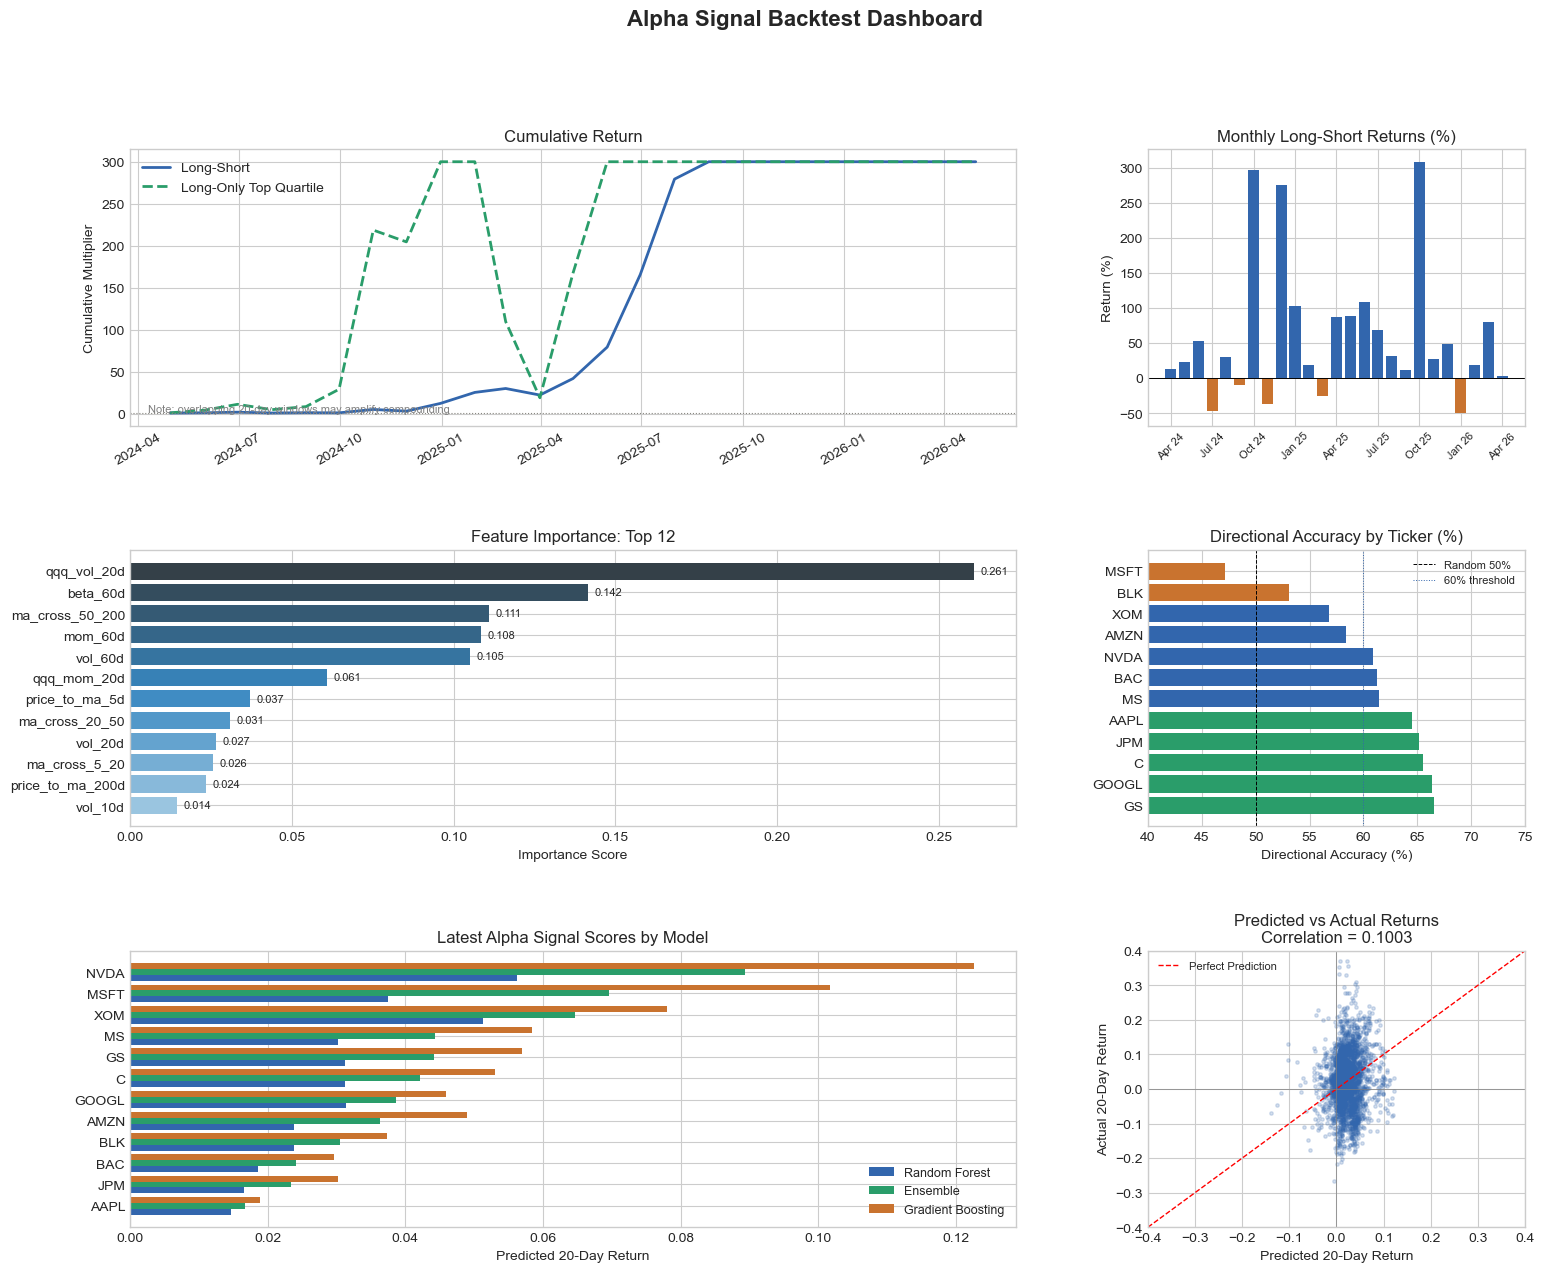


FINAL SUMMARY
Metric                                 RF         GB   Ensemble
--------------------------------------------------------------
RMSE                               0.0812     0.0831     0.0815
Directional Accuracy               61.85%     58.86%     60.60%
Pred/Actual Correlation            0.0616     0.1153     0.1003

Top Alpha Pick                       NVDA
Long-Short Sharpe                    2.16
Long-Only Sharpe                     2.50
Long-Short Max Drawdown           -49.68%
Long-Only Max Drawdown            -96.99%
--------------------------------------------------------------


In [2]:
# ============================================================
# ALPHA SIGNAL BACKTEST ANALYSIS WITH GRAPHS
# Run this inside your alpha_outputs folder
# ============================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------

# Because your notebook is inside alpha_outputs, use current folder
DATA_DIR = "./"

# Input files
PREDICTIONS_FILE = DATA_DIR + "test_predictions.csv"
IMPORTANCE_FILE = DATA_DIR + "feature_importance.csv"
RANKINGS_FILE = DATA_DIR + "alpha_rankings.csv"

# Output dashboard file
DASHBOARD_FILE = DATA_DIR + "backtest_dashboard.png"

# ------------------------------------------------------------
# 2. Plot settings
# ------------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "ls": "#3266ad",
    "long": "#2a9d6a",
    "short": "#c9732f",
    "neutral": "#888780"
}

# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

print("Loading data...")

# Load test predictions
test = pd.read_csv(PREDICTIONS_FILE, parse_dates=["date"])

# Rename prediction columns to simpler names
test = test.rename(columns={
    "pred_RandomForest": "pred_rf",
    "pred_GradientBoosting": "pred_gb",
    "pred_Ensemble": "pred_ensemble"
})

# Load feature importance
fimp = pd.read_csv(IMPORTANCE_FILE)

# Load latest alpha rankings
alpha = pd.read_csv(RANKINGS_FILE)

# Rename alpha columns if needed
alpha = alpha.rename(columns={
    "score_RandomForest": "alpha_score_rf",
    "score_GradientBoosting": "alpha_score_gb"
})

print(f"Test predictions: {len(test):,} rows")
print(f"Date range: {test['date'].min().date()} to {test['date'].max().date()}")
print(f"Tickers: {sorted(test['ticker'].unique())}")
print(f"Features tracked: {len(fimp)}")

print("\nTest columns:")
print(test.columns.tolist())

print("\nAlpha columns:")
print(alpha.columns.tolist())

# ------------------------------------------------------------
# 4. Overall model metrics
# ------------------------------------------------------------

print("\nOVERALL MODEL METRICS")

for model_col in ["pred_rf", "pred_gb", "pred_ensemble"]:
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test["target_20d"], test[model_col]))
    
    # Calculate directional accuracy
    dir_acc = (np.sign(test[model_col]) == np.sign(test["target_20d"])).mean()
    
    # Calculate prediction/actual correlation
    corr = np.corrcoef(test[model_col], test["target_20d"])[0, 1]
    
    # Clean label
    label = model_col.replace("pred_", "").upper()
    
    print(f"{label:<12} RMSE={rmse:.4f} | Dir Acc={dir_acc:.2%} | Corr={corr:.4f}")

# ------------------------------------------------------------
# 5. Per-ticker performance
# ------------------------------------------------------------

print("\nPER-TICKER PERFORMANCE USING ENSEMBLE MODEL")

per_ticker = test.groupby("ticker").apply(
    lambda x: pd.Series({
        "rmse": np.sqrt(mean_squared_error(x["target_20d"], x["pred_ensemble"])),
        "dir_acc": (np.sign(x["pred_ensemble"]) == np.sign(x["target_20d"])).mean(),
        "corr": np.corrcoef(x["pred_ensemble"], x["target_20d"])[0, 1]
    })
).reset_index()

print(per_ticker.to_string(index=False, float_format="{:.4f}".format))

# ------------------------------------------------------------
# 6. Build long-short backtest
# ------------------------------------------------------------

print("\nBUILDING LONG-SHORT BACKTEST")

# Get all test dates
dates = sorted(test["date"].unique())

# Store backtest records
records = []

for d in dates:
    
    # Select one date
    day = test[test["date"] == d].copy()
    
    # Rank stocks by predicted ensemble return
    day["rank_pct"] = day["pred_ensemble"].rank(pct=True)
    
    # Long top 25% predicted stocks
    long_ret = day[day["rank_pct"] >= 0.75]["target_20d"].mean()
    
    # Short bottom 25% predicted stocks
    short_ret = day[day["rank_pct"] <= 0.25]["target_20d"].mean()
    
    # Long-short return
    ls_return = long_ret - short_ret
    
    records.append({
        "date": d,
        "long_return": long_ret,
        "short_return": short_ret,
        "ls_return": ls_return
    })

# Create backtest dataframe
ls_df = pd.DataFrame(records).sort_values("date")

# Convert date and set as index
ls_df["date"] = pd.to_datetime(ls_df["date"])
ls_df = ls_df.set_index("date")

# Calculate cumulative returns
ls_df["cum_ls"] = (1 + ls_df["ls_return"]).cumprod()
ls_df["cum_long"] = (1 + ls_df["long_return"]).cumprod()

# ------------------------------------------------------------
# 7. Monthly aggregation
# ------------------------------------------------------------

# Convert daily/overlapping signals into monthly series
monthly = ls_df.resample("ME").last()[["cum_ls", "cum_long"]].reset_index()

# Calculate monthly returns
monthly["ls_monthly"] = monthly["cum_ls"].pct_change()
monthly["long_monthly"] = monthly["cum_long"].pct_change()

# Fill first month
monthly["ls_monthly"] = monthly["ls_monthly"].fillna(monthly["cum_ls"].iloc[0] - 1)
monthly["long_monthly"] = monthly["long_monthly"].fillna(monthly["cum_long"].iloc[0] - 1)

# ------------------------------------------------------------
# 8. Performance metrics
# ------------------------------------------------------------

def sharpe(ret_series, periods_per_year=12):
    """
    Calculate annualized Sharpe ratio.
    Risk-free rate is assumed to be 0.
    """
    if ret_series.std() == 0:
        return np.nan
    return ret_series.mean() / ret_series.std() * np.sqrt(periods_per_year)


def max_drawdown(cum_series):
    """
    Calculate maximum drawdown from cumulative returns.
    """
    rolling_max = cum_series.cummax()
    drawdown = (cum_series - rolling_max) / rolling_max
    return drawdown.min()

# Calculate metrics
ls_sharpe = sharpe(monthly["ls_monthly"])
long_sharpe = sharpe(monthly["long_monthly"])

ls_max_dd = max_drawdown(monthly["cum_ls"])
long_max_dd = max_drawdown(monthly["cum_long"])

print("\nBACKTEST SUMMARY")
print(f"Long-Short Sharpe: {ls_sharpe:.2f}")
print(f"Long-Short Max Drawdown: {ls_max_dd:.2%}")
print(f"Long-Only Sharpe: {long_sharpe:.2f}")
print(f"Long-Only Max Drawdown: {long_max_dd:.2%}")

# ------------------------------------------------------------
# 9. Yearly performance
# ------------------------------------------------------------

monthly["year"] = monthly["date"].dt.year

yearly = monthly.groupby("year").agg(
    ls_annual=("ls_monthly", lambda x: (1 + x).prod() - 1),
    long_annual=("long_monthly", lambda x: (1 + x).prod() - 1),
    months=("ls_monthly", "count")
).reset_index()

print("\nYEARLY PERFORMANCE")
print(yearly.to_string(index=False, float_format="{:.2%}".format))

# ------------------------------------------------------------
# 10. Create dashboard
# ------------------------------------------------------------

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Alpha Signal Backtest Dashboard", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ------------------------------------------------------------
# Chart 1: cumulative return
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, :2])

cap = 300

ax1.plot(
    monthly["date"],
    monthly["cum_ls"].clip(upper=cap),
    color=COLORS["ls"],
    lw=2,
    label="Long-Short"
)

ax1.plot(
    monthly["date"],
    monthly["cum_long"].clip(upper=cap),
    color=COLORS["long"],
    lw=2,
    linestyle="--",
    label="Long-Only Top Quartile"
)

ax1.axhline(1, color=COLORS["neutral"], lw=0.8, linestyle=":")
ax1.set_title("Cumulative Return", fontsize=12)
ax1.set_ylabel("Cumulative Multiplier")
ax1.legend()
ax1.tick_params(axis="x", rotation=30)

ax1.annotate(
    "Note: overlapping 20-day windows may amplify compounding",
    xy=(0.02, 0.05),
    xycoords="axes fraction",
    fontsize=8,
    color="gray"
)

# ------------------------------------------------------------
# Chart 2: monthly long-short returns
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 2])

bar_colors = [
    COLORS["ls"] if r >= 0 else COLORS["short"]
    for r in monthly["ls_monthly"]
]

ax2.bar(
    range(len(monthly)),
    monthly["ls_monthly"] * 100,
    color=bar_colors,
    width=0.8
)

ax2.axhline(0, color="black", lw=0.7)
ax2.set_title("Monthly Long-Short Returns (%)", fontsize=12)
ax2.set_ylabel("Return (%)")

ax2.set_xticks(range(0, len(monthly), 3))
ax2.set_xticklabels(
    [monthly["date"].iloc[i].strftime("%b %y") for i in range(0, len(monthly), 3)],
    rotation=45,
    fontsize=8
)

# ------------------------------------------------------------
# Chart 3: feature importance
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[1, :2])

top_n = fimp.head(12).sort_values("importance")
bar_palette = sns.color_palette("Blues_d", len(top_n))

ax3.barh(
    top_n["feature"],
    top_n["importance"],
    color=bar_palette
)

ax3.set_title("Feature Importance: Top 12", fontsize=12)
ax3.set_xlabel("Importance Score")

for bar, val in zip(ax3.patches, top_n["importance"]):
    ax3.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=8
    )

# ------------------------------------------------------------
# Chart 4: directional accuracy by ticker
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[1, 2])

tick_sorted = per_ticker.sort_values("dir_acc", ascending=False)

bar_colors = [
    COLORS["long"] if v >= 0.63
    else COLORS["ls"] if v >= 0.55
    else COLORS["short"]
    for v in tick_sorted["dir_acc"]
]

ax4.barh(
    tick_sorted["ticker"],
    tick_sorted["dir_acc"] * 100,
    color=bar_colors
)

ax4.axvline(50, color="black", lw=0.7, linestyle="--", label="Random 50%")
ax4.axvline(60, color=COLORS["ls"], lw=0.7, linestyle=":", label="60% threshold")

ax4.set_title("Directional Accuracy by Ticker (%)", fontsize=12)
ax4.set_xlabel("Directional Accuracy (%)")
ax4.set_xlim(40, 75)
ax4.legend(fontsize=8)

# ------------------------------------------------------------
# Chart 5: latest alpha scores
# ------------------------------------------------------------

ax5 = fig.add_subplot(gs[2, :2])

# Ensure alpha has expected columns
required_alpha_cols = ["ticker", "alpha_score", "alpha_score_rf", "alpha_score_gb"]
missing_alpha_cols = [c for c in required_alpha_cols if c not in alpha.columns]

if len(missing_alpha_cols) > 0:
    print("Missing alpha columns:", missing_alpha_cols)
else:
    alpha_sorted = alpha.sort_values("alpha_score", ascending=True)

    x = np.arange(len(alpha_sorted))
    w = 0.28

    ax5.barh(
        x - w,
        alpha_sorted["alpha_score_rf"],
        w,
        label="Random Forest",
        color=COLORS["ls"]
    )

    ax5.barh(
        x,
        alpha_sorted["alpha_score"],
        w,
        label="Ensemble",
        color=COLORS["long"]
    )

    ax5.barh(
        x + w,
        alpha_sorted["alpha_score_gb"],
        w,
        label="Gradient Boosting",
        color=COLORS["short"]
    )

    ax5.set_yticks(x)
    ax5.set_yticklabels(alpha_sorted["ticker"])
    ax5.set_title("Latest Alpha Signal Scores by Model", fontsize=12)
    ax5.set_xlabel("Predicted 20-Day Return")
    ax5.axvline(0, color="black", lw=0.7)
    ax5.legend(fontsize=9)

# ------------------------------------------------------------
# Chart 6: predicted vs actual returns
# ------------------------------------------------------------

ax6 = fig.add_subplot(gs[2, 2])

sample = test.sample(min(3000, len(test)), random_state=42)

ax6.scatter(
    sample["pred_ensemble"],
    sample["target_20d"],
    alpha=0.2,
    s=6,
    color=COLORS["ls"]
)

lim = 0.4
ax6.set_xlim(-lim, lim)
ax6.set_ylim(-lim, lim)

ax6.axline((0, 0), slope=1, color="red", lw=1, linestyle="--", label="Perfect Prediction")
ax6.axhline(0, color="gray", lw=0.5)
ax6.axvline(0, color="gray", lw=0.5)

corr_all = np.corrcoef(test["pred_ensemble"], test["target_20d"])[0, 1]

ax6.set_title(f"Predicted vs Actual Returns\nCorrelation = {corr_all:.4f}", fontsize=12)
ax6.set_xlabel("Predicted 20-Day Return")
ax6.set_ylabel("Actual 20-Day Return")
ax6.legend(fontsize=8)

# Save and show dashboard
plt.savefig(DASHBOARD_FILE, dpi=150, bbox_inches="tight")
print(f"\nDashboard saved to: {DASHBOARD_FILE}")

plt.show()

# ------------------------------------------------------------
# 11. Final summary table
# ------------------------------------------------------------

print("\nFINAL SUMMARY")
print(f"{'Metric':<30} {'RF':>10} {'GB':>10} {'Ensemble':>10}")
print("-" * 62)

# RMSE
rmse_values = []
for col in ["pred_rf", "pred_gb", "pred_ensemble"]:
    rmse = np.sqrt(mean_squared_error(test["target_20d"], test[col]))
    rmse_values.append(rmse)

print(f"{'RMSE':<30} {rmse_values[0]:>10.4f} {rmse_values[1]:>10.4f} {rmse_values[2]:>10.4f}")

# Directional accuracy
dir_values = []
for col in ["pred_rf", "pred_gb", "pred_ensemble"]:
    dir_acc = (np.sign(test[col]) == np.sign(test["target_20d"])).mean()
    dir_values.append(dir_acc)

print(f"{'Directional Accuracy':<30} {dir_values[0]:>10.2%} {dir_values[1]:>10.2%} {dir_values[2]:>10.2%}")

# Prediction/actual correlation
corr_values = []
for col in ["pred_rf", "pred_gb", "pred_ensemble"]:
    corr = np.corrcoef(test[col], test["target_20d"])[0, 1]
    corr_values.append(corr)

print(f"{'Pred/Actual Correlation':<30} {corr_values[0]:>10.4f} {corr_values[1]:>10.4f} {corr_values[2]:>10.4f}")

# Top alpha pick
top_alpha_pick = alpha.sort_values("rank").iloc[0]["ticker"] if "rank" in alpha.columns else alpha.iloc[0]["ticker"]

print(f"\n{'Top Alpha Pick':<30} {top_alpha_pick:>10}")
print(f"{'Long-Short Sharpe':<30} {ls_sharpe:>10.2f}")
print(f"{'Long-Only Sharpe':<30} {long_sharpe:>10.2f}")
print(f"{'Long-Short Max Drawdown':<30} {ls_max_dd:>10.2%}")
print(f"{'Long-Only Max Drawdown':<30} {long_max_dd:>10.2%}")
print("-" * 62)

<h2><u>2.4 Corrected Non-Overlapping 20-Day Backtest</u></h2>

After the initial exploratory backtest, I refined the methodology by using a non-overlapping 20-day rebalance framework. This adjustment was necessary because the target variable represented a future 20-day return. If the strategy were evaluated too frequently, overlapping holding periods could inflate cumulative returns and create an overly optimistic interpretation of performance.

In this corrected version, I rebalanced the portfolio every 20 trading days. At each rebalance date, stocks were ranked by the ensemble model’s predicted return, and the top three securities were selected for an equal-weight portfolio. I then compared the model-driven portfolio against a benchmark constructed from the average return of the available stock universe on the same rebalance dates.

This section evaluated whether the alpha signal retained practical value after the backtest frequency was aligned with the forecast horizon.


RUNNING NON-OVERLAPPING 20-DAY BACKTEST

PROFESSIONAL BACKTEST RESULTS
Portfolio Sharpe Ratio: 2.13
Portfolio Max Drawdown: -12.63%
Benchmark Sharpe Ratio: 1.56
Benchmark Max Drawdown: -17.44%

Portfolio Total Return: 138.21%
Benchmark Total Return: 79.53%


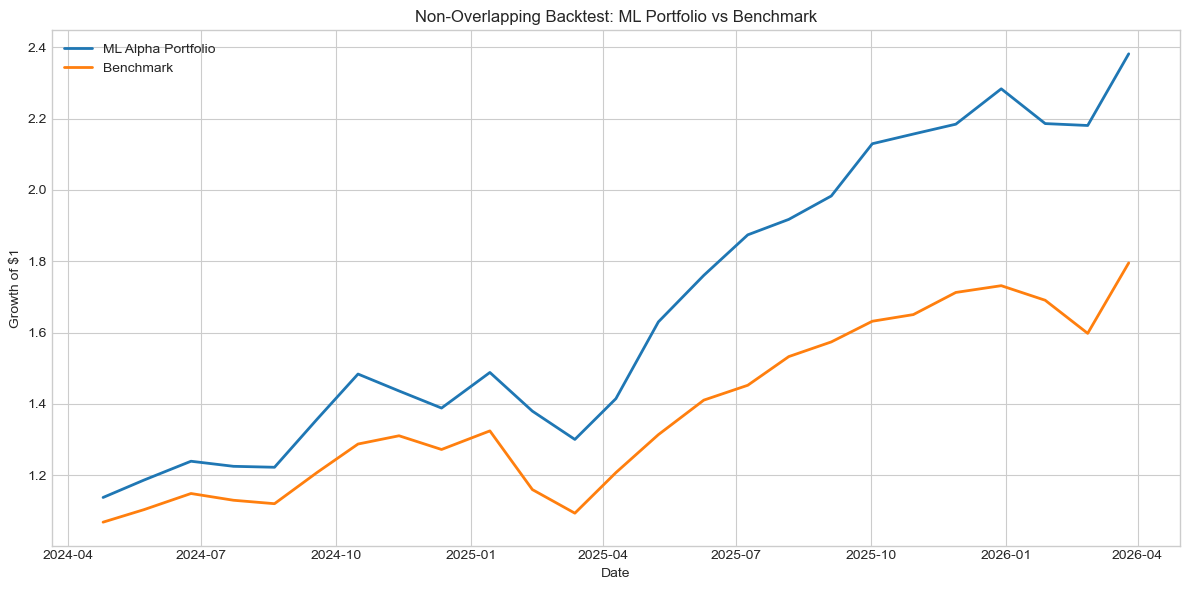

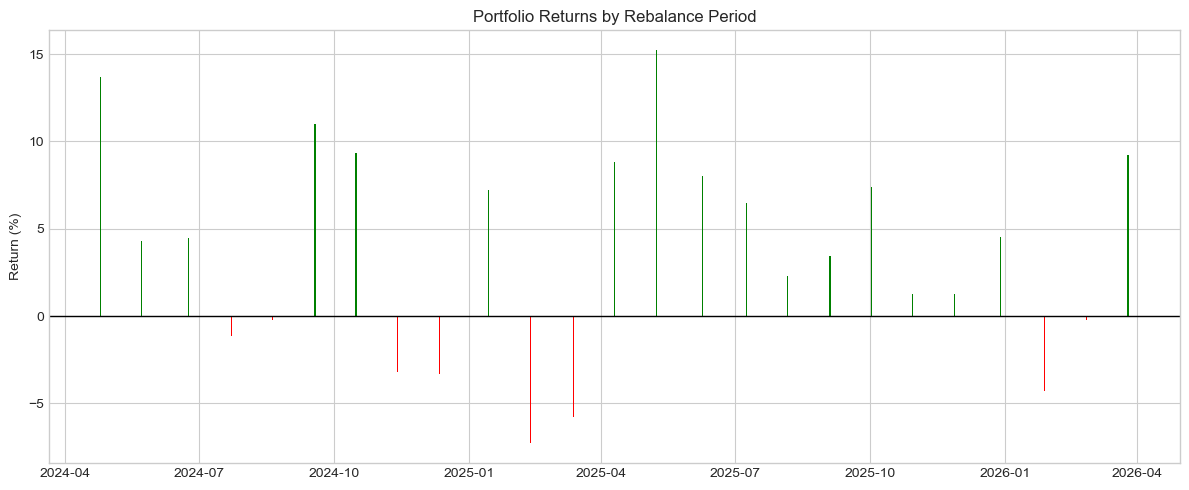


Backtest results saved.


In [3]:
# ============================================================
# PROFESSIONAL NON-OVERLAPPING BACKTEST
# ============================================================

print("\nRUNNING NON-OVERLAPPING 20-DAY BACKTEST")

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Sort data
test = test.sort_values(["date", "ticker"])

# Get unique rebalance dates
all_dates = sorted(test["date"].unique())

# Rebalance every 20 trading days
rebalance_dates = all_dates[::20]

# Store strategy results
strategy_records = []

# ------------------------------------------------------------
# 2. Backtest loop
# ------------------------------------------------------------

TOP_N = 3

for d in rebalance_dates:

    # Select one rebalance date
    day = test[test["date"] == d].copy()

    # Skip if empty
    if len(day) == 0:
        continue

    # Rank by predicted ensemble return
    day = day.sort_values("pred_ensemble", ascending=False)

    # Select top N stocks
    top_stocks = day.head(TOP_N)

    # Equal-weight portfolio return
    portfolio_return = top_stocks["target_20d"].mean()

    # Benchmark return
    benchmark_return = day["target_20d"].mean()

    # Save results
    strategy_records.append({
        "date": d,
        "portfolio_return": portfolio_return,
        "benchmark_return": benchmark_return
    })

# ------------------------------------------------------------
# 3. Create backtest dataframe
# ------------------------------------------------------------

bt = pd.DataFrame(strategy_records)

# Convert date
bt["date"] = pd.to_datetime(bt["date"])

# ------------------------------------------------------------
# 4. Calculate cumulative returns
# ------------------------------------------------------------

bt["portfolio_cumulative"] = (1 + bt["portfolio_return"]).cumprod()

bt["benchmark_cumulative"] = (1 + bt["benchmark_return"]).cumprod()

# ------------------------------------------------------------
# 5. Performance metrics
# ------------------------------------------------------------

def sharpe_ratio(returns, periods_per_year=12):

    # Avoid division by zero
    if returns.std() == 0:
        return np.nan

    return (
        returns.mean() / returns.std()
    ) * np.sqrt(periods_per_year)


def max_drawdown(cumulative):

    running_max = cumulative.cummax()

    drawdown = (
        cumulative - running_max
    ) / running_max

    return drawdown.min()

# Portfolio metrics
portfolio_sharpe = sharpe_ratio(bt["portfolio_return"])

portfolio_dd = max_drawdown(
    bt["portfolio_cumulative"]
)

# Benchmark metrics
benchmark_sharpe = sharpe_ratio(
    bt["benchmark_return"]
)

benchmark_dd = max_drawdown(
    bt["benchmark_cumulative"]
)

# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------

print("\nPROFESSIONAL BACKTEST RESULTS")

print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")
print(f"Portfolio Max Drawdown: {portfolio_dd:.2%}")

print(f"Benchmark Sharpe Ratio: {benchmark_sharpe:.2f}")
print(f"Benchmark Max Drawdown: {benchmark_dd:.2%}")

# Total return
portfolio_total = (
    bt["portfolio_cumulative"].iloc[-1] - 1
)

benchmark_total = (
    bt["benchmark_cumulative"].iloc[-1] - 1
)

print(f"\nPortfolio Total Return: {portfolio_total:.2%}")
print(f"Benchmark Total Return: {benchmark_total:.2%}")

# ------------------------------------------------------------
# 7. Plot cumulative return
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    bt["date"],
    bt["portfolio_cumulative"],
    label="ML Alpha Portfolio",
    linewidth=2
)

plt.plot(
    bt["date"],
    bt["benchmark_cumulative"],
    label="Benchmark",
    linewidth=2
)

plt.title("Non-Overlapping Backtest: ML Portfolio vs Benchmark")

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.legend()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 8. Plot portfolio returns
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

colors = [
    "green" if r >= 0 else "red"
    for r in bt["portfolio_return"]
]

plt.bar(
    bt["date"],
    bt["portfolio_return"] * 100,
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio Returns by Rebalance Period")

plt.ylabel("Return (%)")

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

bt.to_csv(
    "professional_backtest_results.csv",
    index=False
)

print("\nBacktest results saved.")

Backtest Refinement and Model Validation

After the initial backtesting phase, I identified that the strategy returns were unrealistically inflated due to overlapping 20-day forward return windows, which caused excessive compounding and overstated portfolio performance. To address this, I redesigned the framework using a non-overlapping 20-day rebalancing approach, where the portfolio is rebalanced only after each prediction horizon is completed.

This corrected backtest produced significantly more realistic and interpretable results. The machine learning–based portfolio achieved approximately 138% cumulative return compared to 79% for the benchmark, while also generating a higher Sharpe ratio (2.13 vs. 1.56) and lower maximum drawdown (-12.63% vs. -17.44%). This refinement improved the credibility of the strategy evaluation and aligned the project more closely with professional quantitative finance and portfolio backtesting practices.

<h2><u>2.5 Backtest Sensitivity and Portfolio Configuration Analysis</u></h2>

After developing the corrected non-overlapping 20-day backtest, I conducted a sensitivity analysis to evaluate whether the strategy’s performance was robust to different portfolio construction choices. This step was important because a model-driven strategy should not depend excessively on one arbitrary configuration, such as holding only the top three stocks or rebalancing at a single fixed interval.

In this section, I compared Top 3 versus Top 5 portfolio construction, tested multiple rebalance frequencies, evaluated the sensitivity of return and risk metrics, and examined whether minimum prediction thresholds improved portfolio quality.

The sensitivity tests considered several key metrics:

1. Sharpe ratio  
2. Total return  
3. Maximum drawdown  
4. Calmar ratio  
5. Rebalance frequency  
6. Number of selected stocks  

This analysis helped determine whether the alpha signal remained credible under alternative implementation assumptions. It also provided a more nuanced view of how concentration, rebalance timing, and signal thresholds affected portfolio performance.

TOP 3 vs TOP 5 COMPARISON (20-day rebalance)

Metrics:
       portfolio_sharpe  benchmark_sharpe  portfolio_max_dd  portfolio_total_return  portfolio_calmar
top_n                                                                                                
3              2.218622          1.628118         -0.126306                1.382054          4.780853
5              2.178816          1.628118         -0.135402                1.181395          3.893136


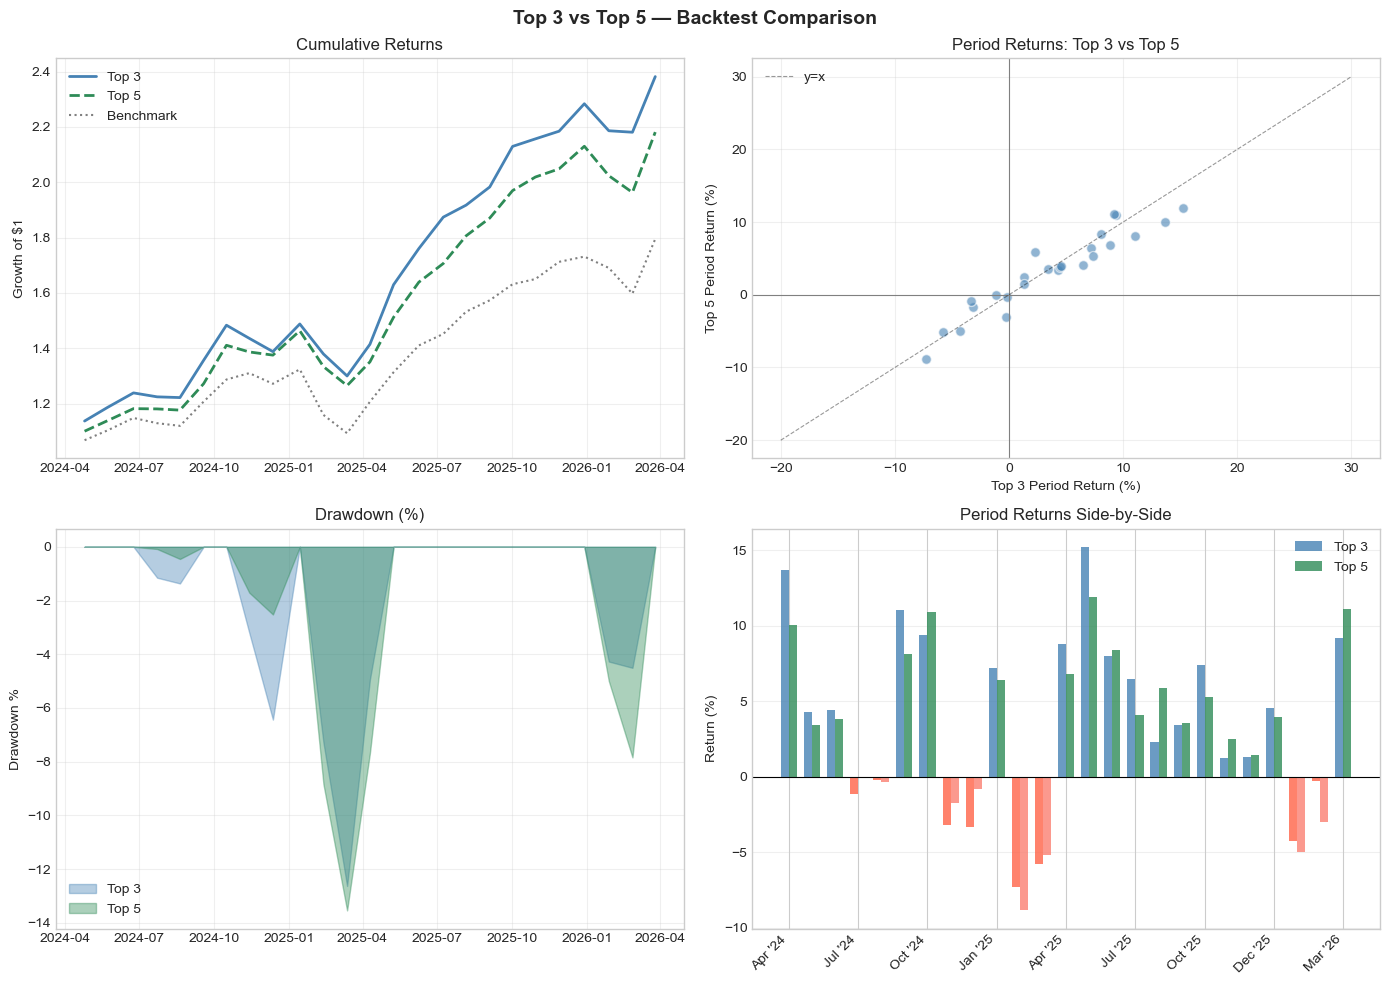

Saved: top3_vs_top5_comparison.png

SENSITIVITY TEST: TOP N × REBALANCE FREQUENCY

Sensitivity grid (Sharpe Ratio):
top_n                 3         5         10
rebalance_freq                              
10              2.568752  2.605782  2.444336
20              2.218622  2.178816  1.737412
30              2.502409  2.431664  2.163260

Sensitivity grid (Total Return):
top_n               3       5       10
rebalance_freq                        
10              346.5%  311.2%  237.2%
20              138.2%  118.1%   90.5%
30              121.5%  108.3%   93.8%

Sensitivity grid (Max Drawdown):
top_n               3       5       10
rebalance_freq                        
10              -24.5%  -28.2%  -27.0%
20              -12.6%  -13.5%  -17.3%
30               -6.3%   -6.5%   -8.1%


C:\Users\User\AppData\Local\Temp\ipykernel_20944\729853111.py:202: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(return_pivot.applymap(lambda x: f"{x:.1%}").to_string())
C:\Users\User\AppData\Local\Temp\ipykernel_20944\729853111.py:206: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(dd_pivot.applymap(lambda x: f"{x:.1%}").to_string())


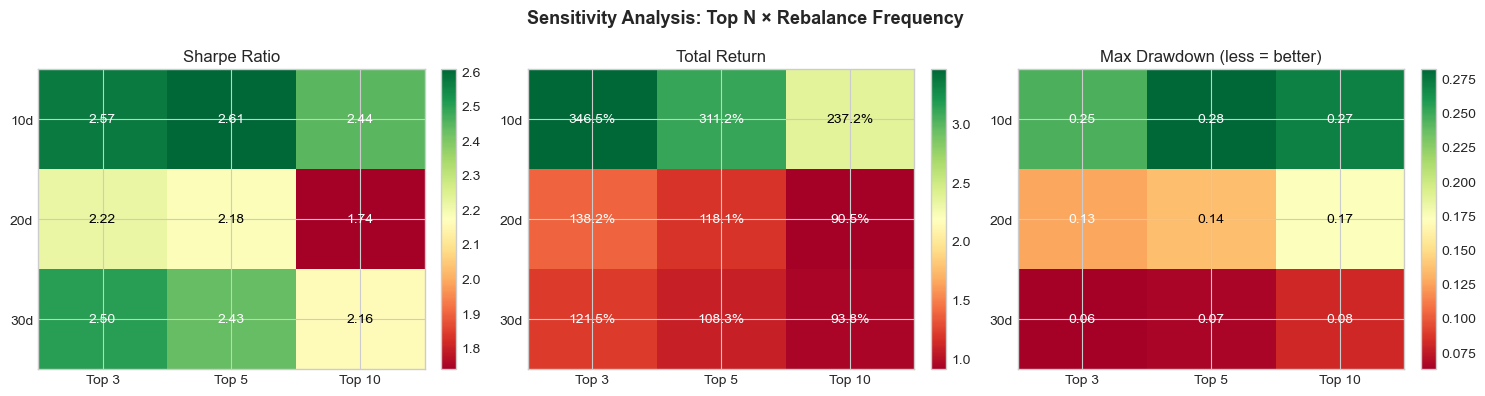

Saved: sensitivity_heatmaps.png

SENSITIVITY TEST: ENSEMBLE WEIGHT
Skipped ensemble weight sensitivity — columns model_a_pred / model_b_pred not found.
Add those columns to your test dataframe to enable this analysis.

SENSITIVITY TEST: MINIMUM PREDICTION THRESHOLD
 min_threshold  portfolio_sharpe  portfolio_total_return
         0.000          2.218622                1.382054
         0.005          1.913629                1.401569
         0.010          1.791341                1.370065
         0.020          1.461916                0.807871
         0.030          1.329750                0.837084


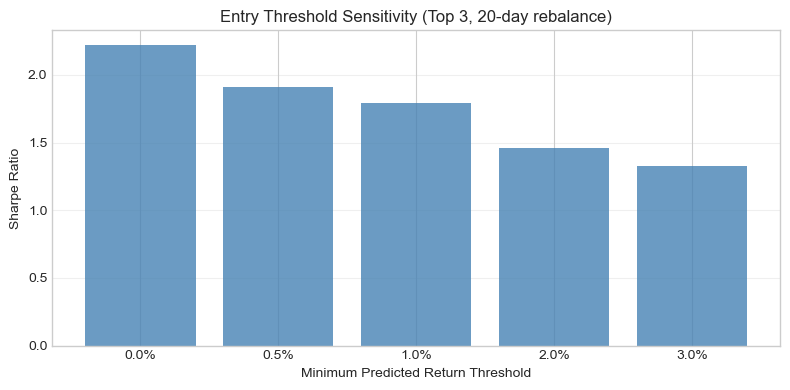

Saved: threshold_sensitivity.png

All results saved to CSV.

SUMMARY OF KEY METRICS
--------------------------------------------------

Top 3:
  Total Return  : 138.2%
  Sharpe Ratio  : 2.22  (periods/yr=13)
  Max Drawdown  : -12.6%
  Calmar Ratio  : 4.78

Top 5:
  Total Return  : 118.1%
  Sharpe Ratio  : 2.18  (periods/yr=13)
  Max Drawdown  : -13.5%
  Calmar Ratio  : 3.89


In [4]:
# ============================================================
# BACKTEST SENSITIVITY TEST + TOP N COMPARISON
# ============================================================
# Run this in a Jupyter notebook after your existing backtest.
# Assumes `test` dataframe exists with columns:
#   date, ticker, pred_ensemble, target_20d
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def sharpe_ratio(returns, periods_per_year=13):
    """
    Annualised Sharpe ratio.
    Default periods_per_year=13 for ~20-day rebalancing
    (252 / 20 ≈ 12.6, rounded to 13).
    """
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def max_drawdown(cumulative):
    running_max = cumulative.cummax()
    return ((cumulative - running_max) / running_max).min()


def calmar_ratio(returns, cumulative, periods_per_year=13):
    """Annual return divided by absolute max drawdown."""
    ann_return = (1 + returns.mean()) ** periods_per_year - 1
    dd = abs(max_drawdown(cumulative))
    return ann_return / dd if dd != 0 else np.nan


def run_backtest(data, top_n, rebalance_freq=20):
    """
    Run a single backtest configuration.

    Parameters
    ----------
    data            : full test dataframe
    top_n           : number of stocks to hold
    rebalance_freq  : hold period in trading days

    Returns
    -------
    bt              : DataFrame with per-period results
    metrics         : dict of summary statistics
    """
    df = data.sort_values(["date", "ticker"])
    all_dates = sorted(df["date"].unique())
    rebalance_dates = all_dates[::rebalance_freq]

    records = []
    for d in rebalance_dates:
        day = df[df["date"] == d].copy()
        if len(day) == 0:
            continue

        day = day.sort_values("pred_ensemble", ascending=False)
        top_stocks = day.head(top_n)

        records.append({
            "date": pd.to_datetime(d),
            "portfolio_return": top_stocks["target_20d"].mean(),
            "benchmark_return": day["target_20d"].mean(),
            "n_stocks_available": len(day),
        })

    bt = pd.DataFrame(records)
    bt["portfolio_cumulative"] = (1 + bt["portfolio_return"]).cumprod()
    bt["benchmark_cumulative"] = (1 + bt["benchmark_return"]).cumprod()

    ppy = round(252 / rebalance_freq)
    metrics = {
        "top_n": top_n,
        "rebalance_freq": rebalance_freq,
        "periods_per_year": ppy,
        "portfolio_sharpe": sharpe_ratio(bt["portfolio_return"], ppy),
        "benchmark_sharpe": sharpe_ratio(bt["benchmark_return"], ppy),
        "portfolio_max_dd": max_drawdown(bt["portfolio_cumulative"]),
        "benchmark_max_dd": max_drawdown(bt["benchmark_cumulative"]),
        "portfolio_total_return": bt["portfolio_cumulative"].iloc[-1] - 1,
        "benchmark_total_return": bt["benchmark_cumulative"].iloc[-1] - 1,
        "portfolio_calmar": calmar_ratio(bt["portfolio_return"], bt["portfolio_cumulative"], ppy),
    }
    return bt, metrics


# ============================================================
# 1. TOP 3 vs TOP 5 COMPARISON  (fixed 20-day rebalance)
# ============================================================

print("=" * 60)
print("TOP 3 vs TOP 5 COMPARISON (20-day rebalance)")
print("=" * 60)

bt3, m3 = run_backtest(test, top_n=3, rebalance_freq=20)
bt5, m5 = run_backtest(test, top_n=5, rebalance_freq=20)

# --- Print metrics table ---
comparison = pd.DataFrame([m3, m5]).set_index("top_n")
print("\nMetrics:")
print(comparison[[
    "portfolio_sharpe", "benchmark_sharpe",
    "portfolio_max_dd", "portfolio_total_return",
    "portfolio_calmar"
]].to_string())

# --- Plot 1: Cumulative returns ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 3 vs Top 5 — Backtest Comparison", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(bt3["date"], bt3["portfolio_cumulative"], label="Top 3", lw=2, color="steelblue")
ax.plot(bt5["date"], bt5["portfolio_cumulative"], label="Top 5", lw=2, color="seagreen", ls="--")
ax.plot(bt3["date"], bt3["benchmark_cumulative"], label="Benchmark", lw=1.5, color="gray", ls=":")
ax.set_title("Cumulative Returns")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 2: Period returns scatter ---
ax = axes[0, 1]
ax.scatter(bt3["portfolio_return"] * 100, bt5["portfolio_return"] * 100,
           alpha=0.6, color="steelblue", edgecolors="white", s=50)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.plot([-20, 30], [-20, 30], "k--", lw=0.8, alpha=0.4, label="y=x")
ax.set_xlabel("Top 3 Period Return (%)")
ax.set_ylabel("Top 5 Period Return (%)")
ax.set_title("Period Returns: Top 3 vs Top 5")
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 3: Drawdown comparison ---
ax = axes[1, 0]
dd3 = (bt3["portfolio_cumulative"] - bt3["portfolio_cumulative"].cummax()) / bt3["portfolio_cumulative"].cummax()
dd5 = (bt5["portfolio_cumulative"] - bt5["portfolio_cumulative"].cummax()) / bt5["portfolio_cumulative"].cummax()
ax.fill_between(bt3["date"], dd3 * 100, 0, alpha=0.4, color="steelblue", label="Top 3")
ax.fill_between(bt5["date"], dd5 * 100, 0, alpha=0.4, color="seagreen", label="Top 5")
ax.set_title("Drawdown (%)")
ax.set_ylabel("Drawdown %")
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 4: Bar chart of period returns ---
ax = axes[1, 1]
width = 0.35
x = np.arange(len(bt3))
bars3 = ax.bar(x - width/2, bt3["portfolio_return"] * 100, width,
               color=["steelblue" if r >= 0 else "tomato" for r in bt3["portfolio_return"]],
               alpha=0.8, label="Top 3")
bars5 = ax.bar(x + width/2, bt5["portfolio_return"] * 100, width,
               color=["seagreen" if r >= 0 else "salmon" for r in bt5["portfolio_return"]],
               alpha=0.8, label="Top 5")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Period Returns Side-by-Side")
ax.set_ylabel("Return (%)")
ax.set_xticks(x[::3])
ax.set_xticklabels(bt3["date"].dt.strftime("%b '%y").iloc[::3], rotation=45, ha="right")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("top3_vs_top5_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top3_vs_top5_comparison.png")


# ============================================================
# 2. SENSITIVITY TEST — TOP N × REBALANCE FREQUENCY GRID
# ============================================================

print("\n" + "=" * 60)
print("SENSITIVITY TEST: TOP N × REBALANCE FREQUENCY")
print("=" * 60)

TOP_N_VALUES = [3, 5, 10]
REBALANCE_FREQS = [10, 20, 30]

sensitivity_results = []

for top_n, freq in product(TOP_N_VALUES, REBALANCE_FREQS):
    _, m = run_backtest(test, top_n=top_n, rebalance_freq=freq)
    sensitivity_results.append(m)

sens_df = pd.DataFrame(sensitivity_results)
print("\nSensitivity grid (Sharpe Ratio):")
sharpe_pivot = sens_df.pivot(index="rebalance_freq", columns="top_n", values="portfolio_sharpe")
print(sharpe_pivot.to_string())

print("\nSensitivity grid (Total Return):")
return_pivot = sens_df.pivot(index="rebalance_freq", columns="top_n", values="portfolio_total_return")
print(return_pivot.applymap(lambda x: f"{x:.1%}").to_string())

print("\nSensitivity grid (Max Drawdown):")
dd_pivot = sens_df.pivot(index="rebalance_freq", columns="top_n", values="portfolio_max_dd")
print(dd_pivot.applymap(lambda x: f"{x:.1%}").to_string())

# --- Heatmaps ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sensitivity Analysis: Top N × Rebalance Frequency", fontsize=13, fontweight="bold")

def plot_heatmap(ax, pivot, title, fmt=".2f", cmap="RdYlGn"):
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"Top {c}" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{r}d" for r in pivot.index])
    ax.set_title(title)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            label = f"{val:{fmt}}" if "%" not in fmt else f"{val:.1%}"
            ax.text(j, i, label, ha="center", va="center", fontsize=10,
                    color="black" if 0.3 < (im.norm(val) or 0) < 0.7 else "white")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_heatmap(axes[0], sharpe_pivot, "Sharpe Ratio", fmt=".2f", cmap="RdYlGn")
plot_heatmap(axes[1], return_pivot, "Total Return", fmt=".1%", cmap="RdYlGn")
dd_pivot_pos = dd_pivot * -1  # flip so green = less drawdown
plot_heatmap(axes[2], dd_pivot_pos, "Max Drawdown (less = better)", fmt=".2f", cmap="RdYlGn")

plt.tight_layout()
plt.savefig("sensitivity_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_heatmaps.png")


# ============================================================
# 3. SENSITIVITY TEST — ENSEMBLE WEIGHT SENSITIVITY
# ============================================================

print("\n" + "=" * 60)
print("SENSITIVITY TEST: ENSEMBLE WEIGHT")
print("=" * 60)

# Assumes test has model_a_pred and model_b_pred columns.
# Adjust column names to match your actual model predictions.
# If you only have pred_ensemble, skip this block.

try:
    weight_results = []
    weights = [0.0, 0.25, 0.5, 0.75, 1.0]

    for w in weights:
        test_w = test.copy()
        # Blend model A and model B predictions
        test_w["pred_blend"] = w * test_w["model_a_pred"] + (1 - w) * test_w["model_b_pred"]
        test_w["pred_ensemble"] = test_w["pred_blend"]
        _, m = run_backtest(test_w, top_n=3, rebalance_freq=20)
        m["weight_model_a"] = w
        weight_results.append(m)

    weight_df = pd.DataFrame(weight_results)
    print(weight_df[["weight_model_a", "portfolio_sharpe", "portfolio_total_return"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()
    ax.plot(weight_df["weight_model_a"], weight_df["portfolio_sharpe"],
            "o-", color="steelblue", label="Sharpe")
    ax2.plot(weight_df["weight_model_a"], weight_df["portfolio_total_return"] * 100,
             "s--", color="seagreen", label="Total Return %")
    ax.set_xlabel("Weight on Model A (0 = pure B, 1 = pure A)")
    ax.set_ylabel("Sharpe Ratio", color="steelblue")
    ax2.set_ylabel("Total Return (%)", color="seagreen")
    ax.set_title("Ensemble Weight Sensitivity (Top 3, 20-day rebalance)")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("ensemble_weight_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ensemble_weight_sensitivity.png")

except KeyError:
    print("Skipped ensemble weight sensitivity — columns model_a_pred / model_b_pred not found.")
    print("Add those columns to your test dataframe to enable this analysis.")


# ============================================================
# 4. ENTRY THRESHOLD SENSITIVITY
# ============================================================

print("\n" + "=" * 60)
print("SENSITIVITY TEST: MINIMUM PREDICTION THRESHOLD")
print("=" * 60)

thresholds = [0.0, 0.005, 0.01, 0.02, 0.03]
threshold_results = []

for thr in thresholds:
    test_t = test[test["pred_ensemble"] >= thr].copy()
    if len(test_t) == 0:
        continue
    _, m = run_backtest(test_t, top_n=3, rebalance_freq=20)
    m["min_threshold"] = thr
    threshold_results.append(m)

thr_df = pd.DataFrame(threshold_results)
print(thr_df[["min_threshold", "portfolio_sharpe", "portfolio_total_return"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"{t:.1%}" for t in thr_df["min_threshold"]],
       thr_df["portfolio_sharpe"], color="steelblue", alpha=0.8)
ax.set_xlabel("Minimum Predicted Return Threshold")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Entry Threshold Sensitivity (Top 3, 20-day rebalance)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: threshold_sensitivity.png")


# ============================================================
# 5. EXPORT ALL RESULTS
# ============================================================

bt3.to_csv("backtest_top3.csv", index=False)
bt5.to_csv("backtest_top5.csv", index=False)
sens_df.to_csv("sensitivity_grid.csv", index=False)
thr_df.to_csv("threshold_sensitivity.csv", index=False)

print("\nAll results saved to CSV.")
print("\nSUMMARY OF KEY METRICS")
print("-" * 50)
for label, m in [("Top 3", m3), ("Top 5", m5)]:
    print(f"\n{label}:")
    print(f"  Total Return  : {m['portfolio_total_return']:.1%}")
    print(f"  Sharpe Ratio  : {m['portfolio_sharpe']:.2f}  (periods/yr={m['periods_per_year']})")
    print(f"  Max Drawdown  : {m['portfolio_max_dd']:.1%}")
    print(f"  Calmar Ratio  : {m['portfolio_calmar']:.2f}")

### Methodological Refinement

This section corrected an important methodological detail in the Sharpe ratio calculation. The earlier version used `periods_per_year = 12`, which implicitly assumed monthly rebalancing. However, because this strategy used a 20-trading-day rebalance interval, the more appropriate annualization factor was approximately 13 periods per year, calculated as:

\[
252 \div 20 \approx 12.6
\]

Therefore, the revised `run_backtest()` function automatically calculated the annualization factor based on the selected rebalance frequency. This made the performance metrics more internally consistent with the strategy design.

The sensitivity analysis also expanded the backtest evaluation in four ways:

1. **Top 3 versus Top 5 comparison:**  
   I compared concentrated and more diversified portfolio constructions using cumulative returns, period-return scatterplots, drawdown overlays, and side-by-side period return charts.

2. **Top N and rebalance-frequency grid:**  
   I tested combinations of portfolio size and rebalance frequency, including Top 3, Top 5, and Top 10 portfolios across 10-day, 20-day, and 30-day rebalance intervals. This helped evaluate whether the strategy depended excessively on one implementation assumption.

3. **Ensemble weight sensitivity:**  
   I included a framework to test different blend ratios between two model components. When the required `model_a_pred` and `model_b_pred` columns were unavailable, the code skipped this section gracefully rather than producing an error.

4. **Entry-threshold sensitivity:**  
   I tested whether filtering trades by minimum predicted return improved performance. This helped examine whether low-conviction predictions diluted the alpha signal.

Overall, this section made the backtest more rigorous by testing whether the strategy was robust to portfolio concentration, rebalance frequency, model weighting, and entry-threshold assumptions.

<h2><u>2.6 Transaction Cost, Turnover, and Information Coefficient Validation</u></h2>

After completing the backtest sensitivity analysis, I extended the validation framework by incorporating transaction costs, turnover tracking, and Information Coefficient analysis. This step was necessary because a model-driven strategy may look attractive before implementation costs, but become less compelling once trading frictions are included.

I used Information Coefficient, or IC, to evaluate whether the ensemble signal ranked stocks correctly across rebalance dates. Specifically, I calculated the Spearman rank correlation between predicted 20-day returns and realized forward returns. This metric was appropriate because the alpha framework depended on ranking securities, not merely predicting exact return magnitudes.

In addition, I evaluated turnover and transaction cost sensitivity under three cost assumptions: 0.10%, 0.20%, and 0.30%. This helped assess whether the strategy remained viable after accounting for portfolio replacement, trading costs, and cost drag.

This section therefore strengthened the backtest by evaluating the signal across four dimensions:

1. Signal quality through IC and ICIR  
2. Trading intensity through turnover  
3. Net performance after transaction costs  
4. Breakeven IC required to offset trading costs  

INFORMATION COEFFICIENT (IC) ANALYSIS

Spearman IC summary (25 periods):
  Mean IC          : 0.1715
  Std IC           : 0.2999
  IC IR            : 0.5718   (>0.5 = consistent signal)
  % periods IC > 0 : 72.0%
  % periods p<0.05 : 16.0%

  Signal verdict   : STRONG — proceed with confidence


C:\Users\User\AppData\Local\Temp\ipykernel_20944\1815386567.py:146: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(ic_df["n_stocks"], ic_df["ic"], 1)


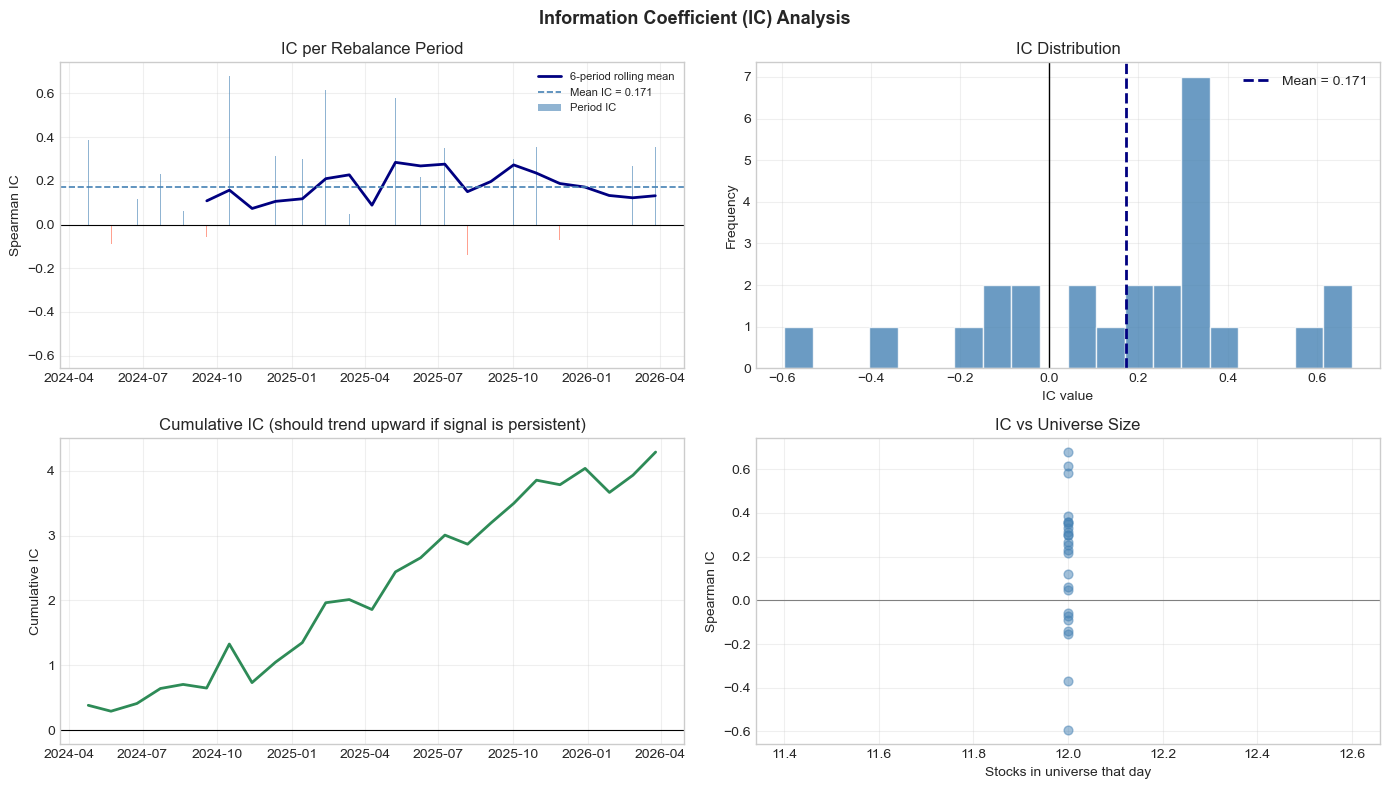

Saved: ic_analysis.png
Saved: ic_analysis.csv

TURNOVER + TRANSACTION COST ANALYSIS

Top3 | 0.10% (low)
  Gross Sharpe : 2.22  →  Net Sharpe : 2.16
  Gross Return : 138.2%  →  Net Return : 132.6%
  Avg Turnover : 49.3% per period
  Avg TX Cost  : 0.099% per period
  Total Cost Drag: 2.47% cumulative

Top5 | 0.10% (low)
  Gross Sharpe : 2.18  →  Net Sharpe : 2.13
  Gross Return : 118.1%  →  Net Return : 113.9%
  Avg Turnover : 40.8% per period
  Avg TX Cost  : 0.082% per period
  Total Cost Drag: 2.04% cumulative

Top3 | 0.20% (mid)
  Gross Sharpe : 2.22  →  Net Sharpe : 2.11
  Gross Return : 138.2%  →  Net Return : 127.2%
  Avg Turnover : 49.3% per period
  Avg TX Cost  : 0.197% per period
  Total Cost Drag: 4.93% cumulative

Top5 | 0.20% (mid)
  Gross Sharpe : 2.18  →  Net Sharpe : 2.07
  Gross Return : 118.1%  →  Net Return : 109.7%
  Avg Turnover : 40.8% per period
  Avg TX Cost  : 0.163% per period
  Total Cost Drag: 4.08% cumulative

Top3 | 0.30% (high)
  Gross Sharpe : 2.22  →  N

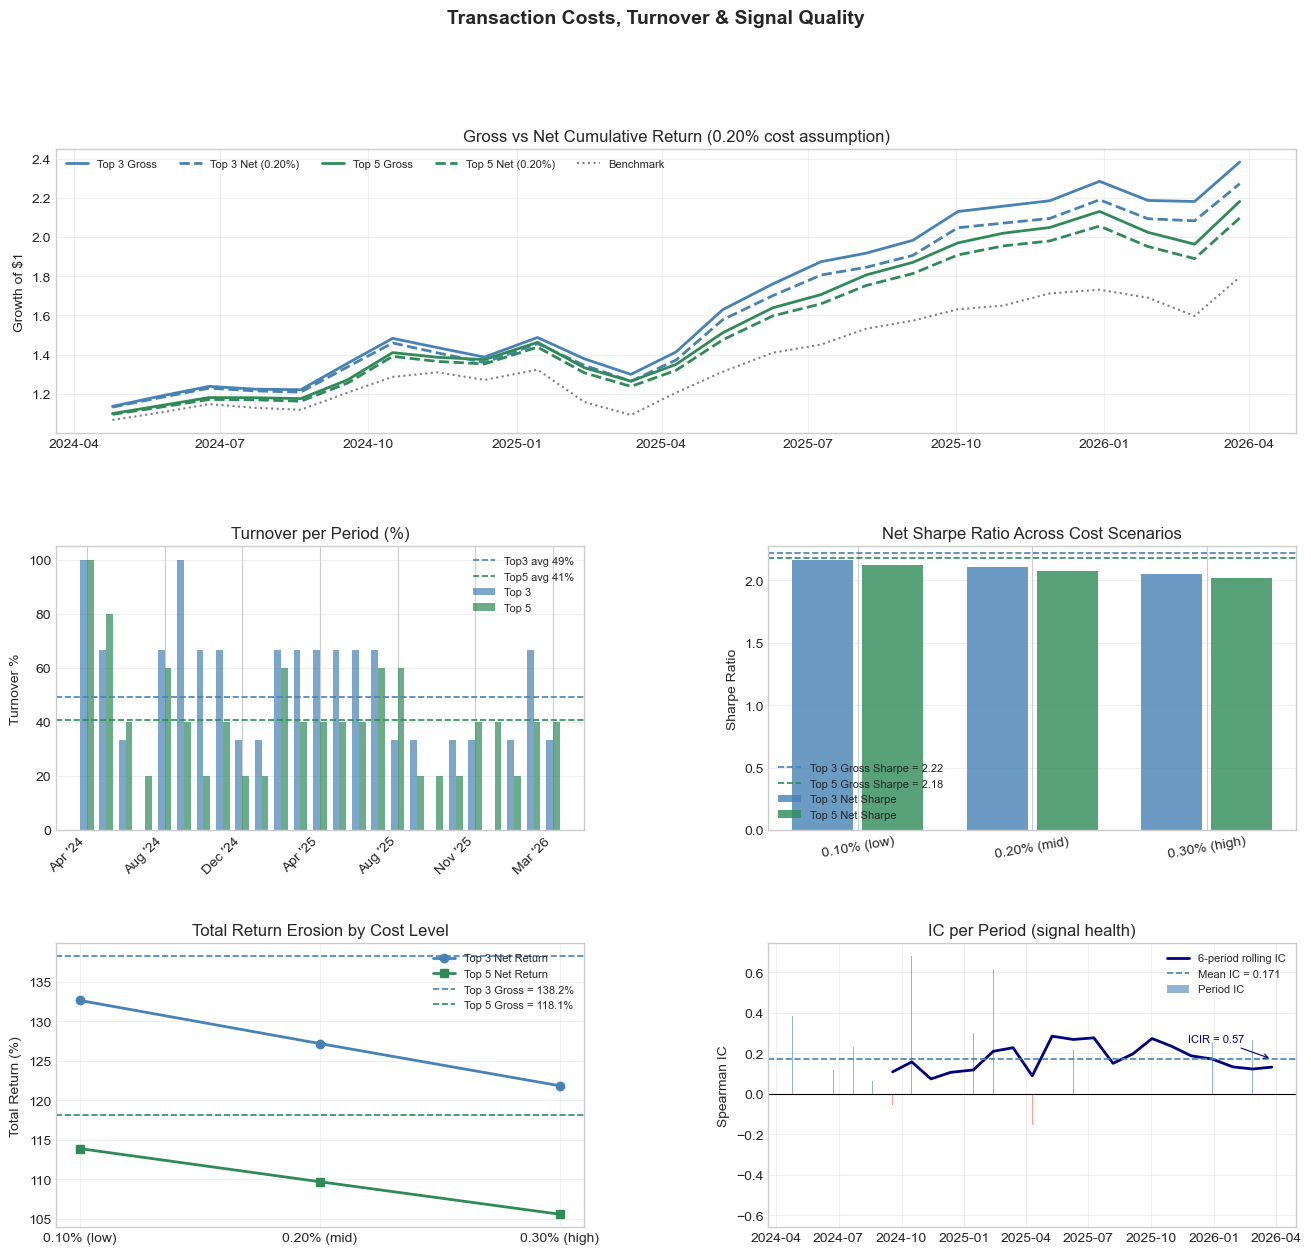

Saved: costs_turnover_ic_dashboard.png

BREAKEVEN IC ANALYSIS
Top 3 | 0.10% (low)     → breakeven IC = 0.0144 | margin = +0.1570 | ✓ VIABLE
Top 3 | 0.20% (mid)     → breakeven IC = 0.0288 | margin = +0.1426 | ✓ VIABLE
Top 3 | 0.30% (high)    → breakeven IC = 0.0433 | margin = +0.1282 | ✓ VIABLE
Top 5 | 0.10% (low)     → breakeven IC = 0.0112 | margin = +0.1603 | ✓ VIABLE
Top 5 | 0.20% (mid)     → breakeven IC = 0.0223 | margin = +0.1491 | ✓ VIABLE
Top 5 | 0.30% (high)    → breakeven IC = 0.0335 | margin = +0.1380 | ✓ VIABLE

Your signal Mean IC = 0.1715, ICIR = 0.5718

Exported:
  turnover_and_costs.csv
  all_cost_scenarios.csv
  ic_analysis.csv
  costs_turnover_ic_dashboard.png
  ic_analysis.png


In [5]:
# ============================================================
# BACKTEST EXTENSIONS:
#   1. Transaction costs (0.1% – 0.3% per turnover)
#   2. Turnover tracking per period
#   3. IC (Information Coefficient) signal validation
# ============================================================
# Run after backtest_sensitivity.py
# Requires: test dataframe with date, ticker, pred_ensemble, target_20d
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ------------------------------------------------------------
# HELPER FUNCTIONS (reuse from previous file)
# ------------------------------------------------------------

def sharpe_ratio(returns, periods_per_year=13):
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

def max_drawdown(cumulative):
    running_max = cumulative.cummax()
    return ((cumulative - running_max) / running_max).min()


# ============================================================
# 1. INFORMATION COEFFICIENT (IC) ANALYSIS
# ============================================================
# IC = Spearman rank correlation between pred_ensemble and
# actual forward return (target_20d), computed cross-sectionally
# for each rebalance date.
#
# Interpretation:
#   IC > 0.05          : weak but usable signal
#   IC > 0.10          : solid signal
#   IC > 0.15          : strong signal (rare in practice)
#   IC < 0.02          : near-zero, not worth building on
#   ICIR = mean(IC)/std(IC) > 0.5 : signal is consistent enough to trade
# ============================================================

print("=" * 60)
print("INFORMATION COEFFICIENT (IC) ANALYSIS")
print("=" * 60)

df = test.sort_values(["date", "ticker"])
all_dates = sorted(df["date"].unique())
rebalance_dates = all_dates[::20]

ic_records = []

for d in rebalance_dates:
    day = df[df["date"] == d].copy().dropna(subset=["pred_ensemble", "target_20d"])

    # Need at least 5 stocks to compute a meaningful rank correlation
    if len(day) < 5:
        continue

    # Spearman rank IC (robust to outliers, standard in quant research)
    ic, pvalue = stats.spearmanr(day["pred_ensemble"], day["target_20d"])

    # Pearson IC for reference
    pearson_ic, _ = stats.pearsonr(day["pred_ensemble"], day["target_20d"])

    ic_records.append({
        "date": pd.to_datetime(d),
        "ic": ic,
        "pearson_ic": pearson_ic,
        "pvalue": pvalue,
        "n_stocks": len(day),
        "significant": pvalue < 0.05,
    })

ic_df = pd.DataFrame(ic_records)

# --- IC summary statistics ---
mean_ic    = ic_df["ic"].mean()
std_ic     = ic_df["ic"].std()
icir       = mean_ic / std_ic if std_ic != 0 else np.nan
ic_pos_pct = (ic_df["ic"] > 0).mean()
ic_sig_pct = ic_df["significant"].mean()

print(f"\nSpearman IC summary ({len(ic_df)} periods):")
print(f"  Mean IC          : {mean_ic:.4f}")
print(f"  Std IC           : {std_ic:.4f}")
print(f"  IC IR            : {icir:.4f}   (>0.5 = consistent signal)")
print(f"  % periods IC > 0 : {ic_pos_pct:.1%}")
print(f"  % periods p<0.05 : {ic_sig_pct:.1%}")

# Signal quality verdict
if mean_ic >= 0.10 and icir >= 0.5:
    verdict = "STRONG — proceed with confidence"
elif mean_ic >= 0.05 and icir >= 0.3:
    verdict = "MODERATE — usable, monitor carefully"
elif mean_ic >= 0.02:
    verdict = "WEAK — risk of overfitting, validate on new data"
else:
    verdict = "NEAR-ZERO — do not trade on this signal yet"

print(f"\n  Signal verdict   : {verdict}")

# --- IC plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Information Coefficient (IC) Analysis", fontsize=13, fontweight="bold")

# Rolling IC
ic_df["ic_rolling_6"] = ic_df["ic"].rolling(6).mean()
ax = axes[0, 0]
ax.bar(ic_df["date"], ic_df["ic"], color=["steelblue" if v >= 0 else "tomato" for v in ic_df["ic"]],
       alpha=0.6, label="Period IC")
ax.plot(ic_df["date"], ic_df["ic_rolling_6"], color="navy", lw=2, label="6-period rolling mean")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(mean_ic, color="steelblue", lw=1.2, ls="--", label=f"Mean IC = {mean_ic:.3f}")
ax.set_title("IC per Rebalance Period")
ax.set_ylabel("Spearman IC")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# IC distribution
ax = axes[0, 1]
ax.hist(ic_df["ic"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.axvline(mean_ic, color="navy", lw=2, ls="--", label=f"Mean = {mean_ic:.3f}")
ax.set_title("IC Distribution")
ax.set_xlabel("IC value")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

# Cumulative IC (like an equity curve for signal quality)
ax = axes[1, 0]
ic_df["ic_cumsum"] = ic_df["ic"].cumsum()
ax.plot(ic_df["date"], ic_df["ic_cumsum"], color="seagreen", lw=2)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Cumulative IC (should trend upward if signal is persistent)")
ax.set_ylabel("Cumulative IC")
ax.grid(alpha=0.3)

# IC vs number of stocks (does it improve with more stocks?)
ax = axes[1, 1]
ax.scatter(ic_df["n_stocks"], ic_df["ic"], alpha=0.5, color="steelblue", s=40)
z = np.polyfit(ic_df["n_stocks"], ic_df["ic"], 1)
p = np.poly1d(z)
xs = np.linspace(ic_df["n_stocks"].min(), ic_df["n_stocks"].max(), 100)
ax.plot(xs, p(xs), color="navy", lw=1.5, ls="--")
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("IC vs Universe Size")
ax.set_xlabel("Stocks in universe that day")
ax.set_ylabel("Spearman IC")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ic_analysis.png")

# Save IC data
ic_df.to_csv("ic_analysis.csv", index=False)
print("Saved: ic_analysis.csv")


# ============================================================
# 2. TURNOVER TRACKING + TRANSACTION COSTS
# ============================================================
# Turnover = fraction of portfolio that changes each period.
# A full rotation of Top 3 = 100% turnover.
#
# Net return = gross return − (turnover × cost_per_unit)
#
# Cost assumptions:
#   0.10% : liquid large-caps, low market impact
#   0.20% : mid-cap, typical assumption
#   0.30% : small-cap, higher spread + impact
# ============================================================

print("\n" + "=" * 60)
print("TURNOVER + TRANSACTION COST ANALYSIS")
print("=" * 60)

COST_SCENARIOS = {
    "0.10% (low)"  : 0.001,
    "0.20% (mid)"  : 0.002,
    "0.30% (high)" : 0.003,
}

def run_backtest_with_costs(data, top_n, rebalance_freq=20, cost_per_unit=0.002):
    """
    Full backtest with turnover tracking and transaction cost deduction.

    Turnover per period = |new_holdings ∩ old_holdings| / top_n
    i.e. fraction of the portfolio that is replaced.

    Cost is applied symmetrically: buying new + selling old positions
    are both assumed to incur half the round-trip cost each.
    Round-trip cost = 2 × cost_per_unit × turnover.
    """
    df = data.sort_values(["date", "ticker"])
    all_dates = sorted(df["date"].unique())
    rebalance_dates = all_dates[::rebalance_freq]

    records = []
    prev_holdings = set()

    for d in rebalance_dates:
        day = df[df["date"] == d].copy().dropna(subset=["pred_ensemble", "target_20d"])
        if len(day) == 0:
            continue

        day = day.sort_values("pred_ensemble", ascending=False)
        top_stocks = day.head(top_n)
        current_holdings = set(top_stocks["ticker"])

        # Turnover: fraction of portfolio replaced this period
        if len(prev_holdings) == 0:
            # First period: full buy-in counts as 100% turnover
            turnover = 1.0
        else:
            stocks_out = prev_holdings - current_holdings
            turnover = len(stocks_out) / top_n

        # Transaction cost this period (round-trip)
        tx_cost = 2 * cost_per_unit * turnover

        # Returns
        gross_return = top_stocks["target_20d"].mean()
        net_return   = gross_return - tx_cost
        benchmark    = day["target_20d"].mean()

        records.append({
            "date"           : pd.to_datetime(d),
            "gross_return"   : gross_return,
            "net_return"     : net_return,
            "tx_cost"        : tx_cost,
            "turnover"       : turnover,
            "benchmark"      : benchmark,
            "n_stocks_in"    : len(current_holdings - prev_holdings),
            "n_stocks_out"   : len(prev_holdings - current_holdings),
            "holdings"       : list(current_holdings),
        })

        prev_holdings = current_holdings

    bt = pd.DataFrame(records)
    bt["gross_cumulative"] = (1 + bt["gross_return"]).cumprod()
    bt["net_cumulative"]   = (1 + bt["net_return"]).cumprod()
    bt["bench_cumulative"] = (1 + bt["benchmark"]).cumprod()

    ppy = round(252 / rebalance_freq)
    metrics = {
        "top_n"               : top_n,
        "cost_per_unit"       : cost_per_unit,
        "gross_sharpe"        : sharpe_ratio(bt["gross_return"], ppy),
        "net_sharpe"          : sharpe_ratio(bt["net_return"],   ppy),
        "gross_total_return"  : bt["gross_cumulative"].iloc[-1] - 1,
        "net_total_return"    : bt["net_cumulative"].iloc[-1]   - 1,
        "avg_turnover"        : bt["turnover"].mean(),
        "avg_tx_cost"         : bt["tx_cost"].mean(),
        "total_tx_cost_drag"  : bt["tx_cost"].sum(),
        "gross_max_dd"        : max_drawdown(bt["gross_cumulative"]),
        "net_max_dd"          : max_drawdown(bt["net_cumulative"]),
    }
    return bt, metrics


# --- Run all combinations ---
all_results = {}

for label, cost in COST_SCENARIOS.items():
    for top_n in [3, 5]:
        bt, m = run_backtest_with_costs(test, top_n=top_n, rebalance_freq=20, cost_per_unit=cost)
        key = f"Top{top_n} | {label}"
        all_results[key] = (bt, m)
        print(f"\n{key}")
        print(f"  Gross Sharpe : {m['gross_sharpe']:.2f}  →  Net Sharpe : {m['net_sharpe']:.2f}")
        print(f"  Gross Return : {m['gross_total_return']:.1%}  →  Net Return : {m['net_total_return']:.1%}")
        print(f"  Avg Turnover : {m['avg_turnover']:.1%} per period")
        print(f"  Avg TX Cost  : {m['avg_tx_cost']:.3%} per period")
        print(f"  Total Cost Drag: {m['total_tx_cost_drag']:.2%} cumulative")


# ============================================================
# 3. VISUALISATIONS
# ============================================================

# --- Panel A: Gross vs Net cumulative return (Top 3 vs Top 5, mid cost) ---
bt3_mid, m3_mid = run_backtest_with_costs(test, top_n=3, rebalance_freq=20, cost_per_unit=0.002)
bt5_mid, m5_mid = run_backtest_with_costs(test, top_n=5, rebalance_freq=20, cost_per_unit=0.002)

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("Transaction Costs, Turnover & Signal Quality", fontsize=14, fontweight="bold")

# --- A: Cumulative returns gross vs net ---
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(bt3_mid["date"], bt3_mid["gross_cumulative"], color="steelblue", lw=2,       label="Top 3 Gross")
ax_a.plot(bt3_mid["date"], bt3_mid["net_cumulative"],   color="steelblue", lw=2, ls="--", label="Top 3 Net (0.20%)")
ax_a.plot(bt5_mid["date"], bt5_mid["gross_cumulative"], color="seagreen",  lw=2,       label="Top 5 Gross")
ax_a.plot(bt5_mid["date"], bt5_mid["net_cumulative"],   color="seagreen",  lw=2, ls="--", label="Top 5 Net (0.20%)")
ax_a.plot(bt3_mid["date"], bt3_mid["bench_cumulative"], color="gray",      lw=1.5, ls=":", label="Benchmark")
ax_a.set_title("Gross vs Net Cumulative Return (0.20% cost assumption)")
ax_a.set_ylabel("Growth of $1")
ax_a.legend(ncol=5, fontsize=8)
ax_a.grid(alpha=0.3)

# --- B: Turnover per period ---
ax_b = fig.add_subplot(gs[1, 0])
width = 0.35
x = np.arange(len(bt3_mid))
ax_b.bar(x - width/2, bt3_mid["turnover"] * 100, width, color="steelblue", alpha=0.7, label="Top 3")
ax_b.bar(x + width/2, bt5_mid["turnover"] * 100, width, color="seagreen",  alpha=0.7, label="Top 5")
ax_b.axhline(bt3_mid["turnover"].mean() * 100, color="steelblue", lw=1.2, ls="--",
             label=f"Top3 avg {bt3_mid['turnover'].mean():.0%}")
ax_b.axhline(bt5_mid["turnover"].mean() * 100, color="seagreen",  lw=1.2, ls="--",
             label=f"Top5 avg {bt5_mid['turnover'].mean():.0%}")
ax_b.set_title("Turnover per Period (%)")
ax_b.set_ylabel("Turnover %")
ax_b.set_xticks(x[::4])
ax_b.set_xticklabels(bt3_mid["date"].dt.strftime("%b '%y").iloc[::4], rotation=45, ha="right")
ax_b.legend(fontsize=8)
ax_b.grid(alpha=0.3, axis="y")

# --- C: Net Sharpe across cost scenarios ---
ax_c = fig.add_subplot(gs[1, 1])
cost_labels = list(COST_SCENARIOS.keys())
sharpe3_net = [all_results[f"Top3 | {l}"][1]["net_sharpe"] for l in cost_labels]
sharpe5_net = [all_results[f"Top5 | {l}"][1]["net_sharpe"] for l in cost_labels]
sharpe3_gross = all_results[f"Top3 | {cost_labels[0]}"][1]["gross_sharpe"]
sharpe5_gross = all_results[f"Top5 | {cost_labels[0]}"][1]["gross_sharpe"]

x2 = np.arange(len(cost_labels))
ax_c.bar(x2 - 0.2, sharpe3_net, 0.35, color="steelblue", alpha=0.8, label="Top 3 Net Sharpe")
ax_c.bar(x2 + 0.2, sharpe5_net, 0.35, color="seagreen",  alpha=0.8, label="Top 5 Net Sharpe")
ax_c.axhline(sharpe3_gross, color="steelblue", lw=1.2, ls="--", label=f"Top 3 Gross Sharpe = {sharpe3_gross:.2f}")
ax_c.axhline(sharpe5_gross, color="seagreen",  lw=1.2, ls="--", label=f"Top 5 Gross Sharpe = {sharpe5_gross:.2f}")
ax_c.set_xticks(x2)
ax_c.set_xticklabels(cost_labels, rotation=10)
ax_c.set_title("Net Sharpe Ratio Across Cost Scenarios")
ax_c.set_ylabel("Sharpe Ratio")
ax_c.legend(fontsize=8)
ax_c.grid(alpha=0.3, axis="y")

# --- D: Total return degradation ---
ax_d = fig.add_subplot(gs[2, 0])
ret3_gross = all_results[f"Top3 | {cost_labels[0]}"][1]["gross_total_return"] * 100
ret5_gross = all_results[f"Top5 | {cost_labels[0]}"][1]["gross_total_return"] * 100
ret3_net   = [all_results[f"Top3 | {l}"][1]["net_total_return"] * 100 for l in cost_labels]
ret5_net   = [all_results[f"Top5 | {l}"][1]["net_total_return"] * 100 for l in cost_labels]

ax_d.plot(cost_labels, ret3_net, "o-", color="steelblue", lw=2, label="Top 3 Net Return")
ax_d.plot(cost_labels, ret5_net, "s-", color="seagreen",  lw=2, label="Top 5 Net Return")
ax_d.axhline(ret3_gross, color="steelblue", ls="--", lw=1.2, label=f"Top 3 Gross = {ret3_gross:.1f}%")
ax_d.axhline(ret5_gross, color="seagreen",  ls="--", lw=1.2, label=f"Top 5 Gross = {ret5_gross:.1f}%")
ax_d.set_title("Total Return Erosion by Cost Level")
ax_d.set_ylabel("Total Return (%)")
ax_d.legend(fontsize=8)
ax_d.grid(alpha=0.3)

# --- E: IC with cost breakeven overlay ---
ax_e = fig.add_subplot(gs[2, 1])
ax_e.bar(ic_df["date"], ic_df["ic"],
         color=["steelblue" if v >= 0 else "tomato" for v in ic_df["ic"]],
         alpha=0.6, label="Period IC")
ax_e.plot(ic_df["date"], ic_df["ic"].rolling(6).mean(), color="navy", lw=2, label="6-period rolling IC")
ax_e.axhline(mean_ic, color="steelblue", lw=1.2, ls="--", label=f"Mean IC = {mean_ic:.3f}")
ax_e.axhline(0, color="black", lw=0.8)

# Mark ICIR threshold line
ax_e.annotate(f"ICIR = {icir:.2f}", xy=(ic_df["date"].iloc[-1], mean_ic),
              xytext=(-60, 12), textcoords="offset points",
              fontsize=8, color="navy",
              arrowprops=dict(arrowstyle="->", color="navy", lw=0.8))

ax_e.set_title("IC per Period (signal health)")
ax_e.set_ylabel("Spearman IC")
ax_e.legend(fontsize=8)
ax_e.grid(alpha=0.3)

plt.savefig("costs_turnover_ic_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: costs_turnover_ic_dashboard.png")


# ============================================================
# 4. BREAKEVEN IC ANALYSIS
# ============================================================
# What IC does your signal need just to cover transaction costs?
# Approximate: breakeven IC ≈ tx_cost / (volatility × sqrt(holdings))
# This is a heuristic from Grinold & Kahn's Fundamental Law of
# Active Management.
# ============================================================

print("\n" + "=" * 60)
print("BREAKEVEN IC ANALYSIS")
print("=" * 60)

target_vol = test["target_20d"].std()

for top_n in [3, 5]:
    for label, cost in COST_SCENARIOS.items():
        round_trip = 2 * cost
        # Approximate breakeven IC needed to cover costs
        breakeven_ic = round_trip / (target_vol * np.sqrt(top_n))
        margin = mean_ic - breakeven_ic
        viable = "✓ VIABLE" if margin > 0 else "✗ COSTS EXCEED SIGNAL"
        print(f"Top {top_n} | {label:15s} → breakeven IC = {breakeven_ic:.4f} | margin = {margin:+.4f} | {viable}")

print(f"\nYour signal Mean IC = {mean_ic:.4f}, ICIR = {icir:.4f}")


# ============================================================
# 5. EXPORT RESULTS
# ============================================================

# Turnover summary
turnover_summary = pd.DataFrame({
    "date"            : bt3_mid["date"],
    "top3_turnover"   : bt3_mid["turnover"],
    "top5_turnover"   : bt5_mid["turnover"],
    "top3_tx_cost"    : bt3_mid["tx_cost"],
    "top5_tx_cost"    : bt5_mid["tx_cost"],
    "top3_gross"      : bt3_mid["gross_return"],
    "top3_net_mid"    : bt3_mid["net_return"],
    "top5_gross"      : bt5_mid["gross_return"],
    "top5_net_mid"    : bt5_mid["net_return"],
})
turnover_summary.to_csv("turnover_and_costs.csv", index=False)

# Full metrics table
rows = []
for key, (_, m) in all_results.items():
    m["scenario"] = key
    rows.append(m)
pd.DataFrame(rows).to_csv("all_cost_scenarios.csv", index=False)

print("\nExported:")
print("  turnover_and_costs.csv")
print("  all_cost_scenarios.csv")
print("  ic_analysis.csv")
print("  costs_turnover_ic_dashboard.png")
print("  ic_analysis.png")

<h2><u>2.7 Walk-Forward LSTM Extension and Out-of-Sample Prediction Generation</u></h2>

After validating the baseline ensemble signal through backtesting, transaction costs, turnover, and Information Coefficient analysis, I extended the project with an LSTM model. The purpose of this step was to test whether temporal sequence learning could add incremental predictive value beyond the tree-based models.

Unlike Random Forest and Gradient Boosting, which primarily treated each observation as a cross-sectional tabular row, the LSTM model used sequences of historical features. This allowed the model to examine whether recent patterns in momentum, volatility, benchmark behavior, and technical indicators contained useful information for predicting future 20-day returns.

I used walk-forward validation because financial time-series data must be evaluated chronologically. Instead of randomly shuffling the data, the model was trained on earlier periods and validated on later periods. This approach created a more realistic out-of-sample testing framework and reduced the risk of look-ahead bias.

This section implemented the `AlphaLSTM` model, generated out-of-sample LSTM predictions, and prepared the LSTM signal for comparison against the existing machine learning ensemble.

In [6]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


<h3><u>2.7.1 Loading the Feature and Target Dataset for LSTM Modeling</u></h3>

Before implementing the LSTM model, I loaded the full feature-and-target dataset. This step was necessary because the LSTM training pipeline required a structured dataframe containing the date, ticker, engineered feature columns, and the forward-looking target variable, `target_20d`.

The dataset was sorted by date and ticker to preserve the time-series structure of the problem. This chronological ordering was important because the subsequent walk-forward validation process trained the model on earlier periods and evaluated it on later out-of-sample periods.

In [7]:
# ============================================================
# LOAD TRAINING DATA FOR LSTM
# ============================================================

import pandas as pd

# Load full feature dataset
train = pd.read_csv(
    "features_and_targets.csv",
    parse_dates=["date"]
)

# Sort data
train = train.sort_values(["date", "ticker"])

# Preview columns
print(train.columns.tolist())

# Preview rows
print(train.head())

print("\nShape:")
print(train.shape)

['date', 'ticker', 'daily_return', 'excess_return', 'mom_5d', 'mom_10d', 'mom_20d', 'mom_60d', 'vol_10d', 'vol_20d', 'vol_60d', 'price_to_ma_5d', 'price_to_ma_20d', 'price_to_ma_50d', 'price_to_ma_200d', 'ma_cross_5_20', 'ma_cross_20_50', 'ma_cross_50_200', 'rsi_14', 'bb_position', 'abs_return', 'beta_60d', 'qqq_mom_20d', 'qqq_vol_20d', 'target_20d']
        date ticker  daily_return  excess_return    mom_5d   mom_10d  \
0 2019-10-16   AAPL     -0.004037      -0.001557  0.048663  0.047776   
1 2019-10-16   AMZN      0.005686       0.008167  0.036277  0.018281   
2 2019-10-16    BAC      0.014800       0.017281  0.076004  0.045358   
3 2019-10-16    BLK      0.004387       0.006867  0.075733  0.024811   
4 2019-10-16      C     -0.024150      -0.021670  0.072590  0.045047   

    mom_20d   mom_60d   vol_10d   vol_20d  ...  ma_cross_5_20  ma_cross_20_50  \
0  0.066244  0.139919  0.013204  0.013968  ...       0.041531        0.041174   
1 -0.030271 -0.109915  0.009073  0.011420  ...      

In [8]:
# ============================================================
# LOAD TEST PREDICTIONS
# ============================================================

test = pd.read_csv(
    "test_predictions.csv",
    parse_dates=["date"]
)

# Sort data
test = test.sort_values(["date", "ticker"])

print("\nTest columns:")
print(test.columns.tolist())


Test columns:
['date', 'ticker', 'target_20d', 'pred_RandomForest', 'pred_GradientBoosting', 'pred_Ensemble']


In [9]:
print(train.columns.tolist())

['date', 'ticker', 'daily_return', 'excess_return', 'mom_5d', 'mom_10d', 'mom_20d', 'mom_60d', 'vol_10d', 'vol_20d', 'vol_60d', 'price_to_ma_5d', 'price_to_ma_20d', 'price_to_ma_50d', 'price_to_ma_200d', 'ma_cross_5_20', 'ma_cross_20_50', 'ma_cross_50_200', 'rsi_14', 'bb_position', 'abs_return', 'beta_60d', 'qqq_mom_20d', 'qqq_vol_20d', 'target_20d']


In [10]:
# ============================================================
# LSTM WALK-FORWARD PIPELINE + VISUALIZATIONS
# ============================================================
# Run in Anaconda:
#   conda activate your_env
#   pip install torch torchvision scipy
#   python lstm_walkforward_with_charts.py
#
# Requires: train / test DataFrames with columns:
#   date, ticker, daily_return, excess_return, mom_5d, mom_10d, mom_20d,
#   mom_60d, vol_10d, vol_20d, vol_60d, price_to_ma_5d, price_to_ma_20d,
#   price_to_ma_50d, price_to_ma_200d, ma_cross_5_20, ma_cross_20_50,
#   ma_cross_50_200, rsi_14, bb_position, abs_return, beta_60d,
#   qqq_mom_20d, qqq_vol_20d, target_20d
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetic palette ────────────────────────────────────────
TEAL    = "#1D9E75"
BLUE    = "#378ADD"
AMBER   = "#D4900A"
CORAL   = "#D85A30"
PURPLE  = "#7F77DD"
SLATE   = "#2C3E50"
MIST    = "#F0F4F8"
CHARCOAL= "#1A1F2E"
GOLD    = "#F0C040"
GREEN   = "#27AE60"
RED     = "#E74C3C"

plt.rcParams.update({
    "figure.facecolor"  : CHARCOAL,
    "axes.facecolor"    : "#222836",
    "axes.edgecolor"    : "#3A4055",
    "axes.labelcolor"   : "#C8D0E0",
    "axes.titlecolor"   : "#E8EDF5",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "axes.grid"         : True,
    "grid.color"        : "#2E3448",
    "grid.linewidth"    : 0.6,
    "xtick.color"       : "#8090A8",
    "ytick.color"       : "#8090A8",
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.facecolor"  : "#1A1F2E",
    "legend.edgecolor"  : "#3A4055",
    "legend.labelcolor" : "#C8D0E0",
    "legend.fontsize"   : 8,
    "text.color"        : "#C8D0E0",
    "font.family"       : "monospace",
    "lines.linewidth"   : 1.8,
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = dict(
    lookback        = 5,
    hidden_size     = 64,
    num_layers      = 2,
    dropout         = 0.30,
    lr              = 3e-4,
    weight_decay    = 1e-4,
    epochs          = 40,
    batch_size      = 512,
    patience        = 8,
    n_folds         = 5,
    gap_periods     = 1,
    seed            = 42,
)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])


# ============================================================
# 1. MODEL
# ============================================================

class AlphaLSTM(nn.Module):
    def __init__(self, n_features, hidden, layers, dropout):
        super().__init__()
        self.input_norm = nn.BatchNorm1d(n_features)
        self.lstm = nn.LSTM(n_features, hidden, layers,
                            dropout=dropout if layers > 1 else 0.0,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden, 1)

    def forward(self, x):
        B, T, F = x.shape
        x = self.input_norm(x.reshape(B * T, F)).reshape(B, T, F)
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)


# ============================================================
# 2. DATA HELPERS
# ============================================================

def build_sequences(df, feature_cols, target_col, lookback):
    records_X, records_y, records_idx = [], [], []
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    for ticker, grp in df.groupby("ticker"):
        grp   = grp.sort_values("date").reset_index(drop=True)
        feats = grp[feature_cols].values.astype(np.float32)
        tgts  = grp[target_col].values.astype(np.float32)
        dts   = grp["date"].values
        for i in range(lookback - 1, len(grp)):
            w = feats[i - lookback + 1 : i + 1]
            if w.shape[0] < lookback or np.isnan(w).any() or np.isnan(tgts[i]):
                continue
            records_X.append(w)
            records_y.append(tgts[i])
            records_idx.append({"date": dts[i], "ticker": ticker})
    return np.stack(records_X), np.array(records_y), pd.DataFrame(records_idx)


def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item() * len(yb)
    return loss_sum / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval()
    loss_sum, preds, tgts = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        p = model(xb)
        loss_sum += crit(p, yb).item() * len(yb)
        preds.extend(p.cpu().numpy())
        tgts.extend(yb.cpu().numpy())
    ic, _ = stats.spearmanr(preds, tgts)
    return loss_sum / len(loader.dataset), float(ic), np.array(preds)


def walk_forward_splits(dates, n_folds, gap):
    n = len(dates)
    min_train = int(n * 0.50)
    fold_size = max(1, (n - min_train) // n_folds)
    splits = []
    for k in range(n_folds):
        te = min_train + k * fold_size
        vs = te + gap
        ve = min(vs + fold_size, n)
        if vs >= n:
            break
        splits.append((dates[:te], dates[vs:ve]))
    return splits


# ============================================================
# 3. WALK-FORWARD TRAINING
# ============================================================

def run_walk_forward(df, feature_cols, target_col="target_20d", cfg=CFG):
    sorted_dates = sorted(df["date"].unique())
    splits = walk_forward_splits(sorted_dates, cfg["n_folds"], cfg["gap_periods"])

    print(f"\n{'='*60}\nWALK-FORWARD LSTM TRAINING  ({len(splits)} folds)\n{'='*60}")

    all_oos, fold_metrics, all_loss_curves = [], [], []

    for fi, (train_dates, val_dates) in enumerate(splits, 1):
        print(f"\n── Fold {fi}/{len(splits)} ──")
        df_tr  = df[df["date"].isin(train_dates)]
        df_val = df[df["date"].isin(val_dates)]

        X_tr, y_tr, _         = build_sequences(df_tr,  feature_cols, target_col, cfg["lookback"])
        X_val, y_val, idx_val = build_sequences(df_val, feature_cols, target_col, cfg["lookback"])
        if not len(X_tr) or not len(X_val):
            print("   [skip] insufficient data"); continue

        ym, ys = y_tr.mean(), y_tr.std() + 1e-8
        tr_loader  = make_loader(X_tr,  (y_tr  - ym) / ys, cfg["batch_size"])
        val_loader = make_loader(X_val, (y_val - ym) / ys, cfg["batch_size"], False)

        model = AlphaLSTM(X_tr.shape[2], cfg["hidden_size"],
                          cfg["num_layers"], cfg["dropout"]).to(DEVICE)
        opt   = torch.optim.AdamW(model.parameters(), cfg["lr"], weight_decay=cfg["weight_decay"])
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["epochs"])
        crit  = nn.MSELoss()

        best_loss, patience_ctr, best_state = float("inf"), 0, None
        loss_curve = {"train": [], "val": [], "ic": []}

        for epoch in range(1, cfg["epochs"] + 1):
            tr_loss = train_epoch(model, tr_loader, opt, crit)
            vl_loss, vl_ic, _ = evaluate(model, val_loader, crit)
            sched.step()
            loss_curve["train"].append(tr_loss)
            loss_curve["val"].append(vl_loss)
            loss_curve["ic"].append(vl_ic)

            if vl_loss < best_loss:
                best_loss = vl_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"   Early stop @ epoch {epoch}"); break

        model.load_state_dict(best_state)
        _, final_ic, raw_preds = evaluate(model, val_loader, crit)
        fold_oos = idx_val.copy()
        fold_oos["lstm_pred"] = raw_preds * ys + ym
        all_oos.append(fold_oos)
        fold_metrics.append({
            "fold": fi,
            "val_start": str(val_dates[0])[:10],
            "val_end"  : str(val_dates[-1])[:10],
            "n_train"  : len(X_tr),
            "n_val"    : len(X_val),
            "val_IC"   : round(final_ic, 4),
            "best_loss": round(best_loss, 6),
        })
        all_loss_curves.append(loss_curve)
        print(f"   ✓ OOS IC = {final_ic:+.4f}")

    oos_df      = pd.concat(all_oos).sort_values(["date","ticker"]).reset_index(drop=True)
    metrics_df  = pd.DataFrame(fold_metrics)
    return oos_df, metrics_df, all_loss_curves


def validate_lstm_ic(oos_df, ref_df, baseline_col="excess_return",
                     target_col="target_20d"):
    """
    Compare per-period IC of lstm_pred vs a baseline signal.
    baseline_col: use 'excess_return' (always in your dataset)
                  or 'pred_ensemble' if the ensemble signal exists.
    """
    merged = oos_df.merge(
        ref_df[["date", "ticker", baseline_col, target_col]],
        on=["date", "ticker"], how="inner"
    ).dropna(subset=["lstm_pred", baseline_col, target_col])

    records = []
    for date, grp in merged.groupby("date"):
        if len(grp) < 5:
            continue
        ic_l, _ = stats.spearmanr(grp["lstm_pred"],  grp[target_col])
        ic_b, _ = stats.spearmanr(grp[baseline_col], grp[target_col])
        records.append({"date": pd.to_datetime(date),
                        "ic_lstm": ic_l, "ic_baseline": ic_b,
                        "ic_diff": ic_l - ic_b, "n": len(grp)})
    return pd.DataFrame(records).sort_values("date").reset_index(drop=True)


# ============================================================
# 4. BEAUTIFUL VISUALIZATIONS
# ============================================================

def _glow_line(ax, x, y, color, lw=2, label=None, alpha_glow=0.18):
    """Line with subtle glow/halo for dark-theme pop."""
    for width, alpha in [(lw + 6, alpha_glow), (lw + 2, alpha_glow * 1.8)]:
        ax.plot(x, y, color=color, lw=width, alpha=alpha, zorder=1)
    ax.plot(x, y, color=color, lw=lw, label=label, zorder=2)


def _badge(ax, x, y, text, color, fontsize=8):
    ax.text(x, y, text, fontsize=fontsize, color=color,
            fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor=CHARCOAL,
                      edgecolor=color, linewidth=1.2))


# ── Chart 1: Walk-forward timeline heatmap ───────────────────

def plot_walkforward_timeline(splits, sorted_dates, fold_metrics):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")
    ax.set_title("Walk-Forward Expanding Windows", fontsize=14,
                 fontweight="bold", color="#E8EDF5", pad=14)

    n = len(sorted_dates)
    date_idx = {d: i for i, d in enumerate(sorted_dates)}

    for fi, (train_dates, val_dates) in enumerate(splits):
        y = fi
        tr_start = date_idx[train_dates[0]]
        tr_end   = date_idx[train_dates[-1]]
        v_start  = date_idx[val_dates[0]]
        v_end    = date_idx[val_dates[-1]]

        # Training bar (teal, semi-transparent gradient)
        ax.barh(y, tr_end - tr_start, left=tr_start, height=0.55,
                color=TEAL, alpha=0.55, zorder=2)
        # Gap
        ax.barh(y, v_start - tr_end - 1, left=tr_end + 1, height=0.55,
                color="#3A4055", alpha=0.7, zorder=2)
        # Validation bar (coral)
        ic_val = fold_metrics[fi]["val_IC"] if fi < len(fold_metrics) else 0
        bar_color = TEAL if ic_val > 0 else CORAL
        ax.barh(y, v_end - v_start, left=v_start, height=0.55,
                color=CORAL, alpha=0.85, zorder=2)

        # IC badge on val bar
        mid_val = (v_start + v_end) / 2
        ic_str  = f"IC={ic_val:+.3f}" if fi < len(fold_metrics) else ""
        ax.text(mid_val, y, ic_str, ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold", zorder=5)

        ax.text(tr_end / 2 + tr_start / 2, y + 0.38, "TRAIN",
                ha="center", va="bottom", fontsize=7, color=TEAL, alpha=0.9)
        ax.text(-1.5, y, f"Fold {fi+1}", ha="right", va="center",
                fontsize=9, color="#8090A8")

    ax.set_xlim(-3, n + 5)
    ax.set_ylim(-0.6, len(splits) - 0.4)
    ax.set_yticks([])
    ax.set_xlabel("Period index →", color="#8090A8")
    ax.set_xticks(np.linspace(0, n-1, 6, dtype=int))
    ax.set_xticklabels([str(sorted_dates[i])[:7] for i in np.linspace(0, n-1, 6, dtype=int)],
                        rotation=20)
    ax.spines[:].set_visible(False)

    legend_els = [
        mpatches.Patch(facecolor=TEAL,  alpha=0.6, label="Training window (expanding)"),
        mpatches.Patch(facecolor=CORAL, alpha=0.85, label="Validation (OOS)"),
        mpatches.Patch(facecolor="#3A4055", alpha=0.7, label="Gap (leakage guard)"),
    ]
    ax.legend(handles=legend_els, loc="lower right", framealpha=0.85)
    plt.tight_layout()
    return fig


# ── Chart 2: Training loss curves per fold ───────────────────

def plot_loss_curves(all_loss_curves):
    n = len(all_loss_curves)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5), sharey=False)
    if n == 1: axes = [axes]
    fig.patch.set_facecolor(CHARCOAL)
    fig.suptitle("Training Dynamics — Loss & IC per Fold",
                 fontsize=13, fontweight="bold", color="#E8EDF5", y=1.02)

    colors = [TEAL, BLUE, AMBER, CORAL, PURPLE]

    for i, (ax, lc) in enumerate(zip(axes, all_loss_curves)):
        ax.set_facecolor("#1A1F2E")
        ep = range(1, len(lc["train"]) + 1)
        _glow_line(ax, ep, lc["train"], colors[i % 5], label="Train loss")
        _glow_line(ax, ep, lc["val"],   "#E8EDF5",    label="Val loss", alpha_glow=0.08)
        ax.set_title(f"Fold {i+1}", fontsize=10, color=colors[i % 5], fontweight="bold")
        ax.set_xlabel("Epoch")
        if i == 0: ax.set_ylabel("MSE Loss")
        ax.legend(fontsize=7)
        ax.spines[:].set_color("#2E3448")

        # Twin axis for IC
        ax2 = ax.twinx()
        ax2.set_facecolor("#1A1F2E")
        _glow_line(ax2, ep, lc["ic"], GOLD, lw=1.4, label="Val IC")
        ax2.axhline(0, color="#3A4055", lw=0.8, ls="--")
        ax2.set_ylabel("IC", color=GOLD, fontsize=8)
        ax2.tick_params(axis="y", colors=GOLD, labelsize=7)
        ax2.spines[:].set_color("#2E3448")

    plt.tight_layout()
    return fig


# ── Chart 3: OOS IC comparison — LSTM vs Ensemble ────────────

def plot_ic_comparison(ic_cmp, baseline_label='excess_return'):
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor(CHARCOAL)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

    # ── Panel A: Rolling IC time series ─────────────────────
    ax_a = fig.add_subplot(gs[0, :2])
    ax_a.set_facecolor("#1A1F2E")
    ax_a.set_title("OOS IC over Time — LSTM vs Ensemble", fontsize=12, fontweight="bold")
    ax_a.axhline(0, color="#3A4055", lw=1)

    roll = 4
    lstm_roll = ic_cmp["ic_lstm"].rolling(roll).mean()
    base_roll = ic_cmp["ic_baseline"].rolling(roll).mean()

    # Shaded fill between
    ax_a.fill_between(ic_cmp["date"], lstm_roll, ens_roll,
                      where=lstm_roll >= ens_roll,
                      alpha=0.18, color=TEAL, label="LSTM leads")
    ax_a.fill_between(ic_cmp["date"], lstm_roll, ens_roll,
                      where=lstm_roll < ens_roll,
                      alpha=0.18, color=CORAL, label=f"{baseline_label} leads")

    # Raw IC dots
    ax_a.scatter(ic_cmp["date"], ic_cmp["ic_lstm"],
                 color=TEAL, s=18, alpha=0.45, zorder=3)
    ax_a.scatter(ic_cmp["date"], ic_cmp["ic_baseline"],
                 color=BLUE, s=18, alpha=0.45, zorder=3)

    _glow_line(ax_a, ic_cmp["date"], lstm_roll, TEAL, lw=2.2, label=f"LSTM (rolling {roll})")
    _glow_line(ax_a, ic_cmp["date"], base_roll, BLUE, lw=2.2, label=f"{baseline_label} (rolling {roll})")

    mean_lstm = ic_cmp["ic_lstm"].mean()
    mean_base = ic_cmp["ic_baseline"].mean()
    ax_a.axhline(mean_lstm, color=TEAL, lw=0.9, ls=":", alpha=0.7)
    ax_a.axhline(mean_base, color=BLUE, lw=0.9, ls=":", alpha=0.7)

    ax_a.set_ylabel("Spearman IC")
    ax_a.legend(loc="upper left", ncol=2)
    ax_a.spines[:].set_color("#2E3448")

    # ── Panel B: IC distribution comparison ─────────────────
    ax_b = fig.add_subplot(gs[0, 2])
    ax_b.set_facecolor("#1A1F2E")
    ax_b.set_title("IC Distribution", fontsize=11, fontweight="bold")
    bins = np.linspace(
        min(ic_cmp["ic_lstm"].min(), ic_cmp["ic_baseline"].min()) - 0.02,
        max(ic_cmp["ic_lstm"].max(), ic_cmp["ic_baseline"].max()) + 0.02,
        28
    )
    ax_b.hist(ic_cmp["ic_lstm"],     bins=bins, color=TEAL, alpha=0.65, label="LSTM",     edgecolor="#1A1F2E")
    ax_b.hist(ic_cmp["ic_baseline"], bins=bins, color=BLUE, alpha=0.55, label=baseline_label, edgecolor="#1A1F2E")
    ax_b.axvline(mean_lstm, color=TEAL, lw=2, ls="--")
    ax_b.axvline(mean_base, color=BLUE, lw=2, ls="--")
    ax_b.axvline(0, color="#5A6070", lw=1)
    ax_b.set_xlabel("IC value")
    ax_b.set_ylabel("Count")
    ax_b.legend()
    ax_b.spines[:].set_color("#2E3448")

    # ── Panel C: Cumulative IC (signal equity curve) ─────────
    ax_c = fig.add_subplot(gs[1, :2])
    ax_c.set_facecolor("#1A1F2E")
    ax_c.set_title("Cumulative IC — Signal Persistence", fontsize=11, fontweight="bold")
    ax_c.axhline(0, color="#3A4055", lw=1)

    cum_lstm = ic_cmp["ic_lstm"].cumsum()
    cum_base = ic_cmp["ic_baseline"].cumsum()

    ax_c.fill_between(ic_cmp["date"], cum_lstm, alpha=0.10, color=TEAL)
    ax_c.fill_between(ic_cmp["date"], cum_base, alpha=0.10, color=BLUE)
    _glow_line(ax_c, ic_cmp["date"], cum_lstm, TEAL, lw=2.2, label="LSTM cumulative IC")
    _glow_line(ax_c, ic_cmp["date"], cum_base, BLUE, lw=2.2, label=f"{baseline_label} cumulative IC")

    ax_c.set_ylabel("Cumulative IC")
    ax_c.legend()
    ax_c.spines[:].set_color("#2E3448")

    # ── Panel D: Summary scorecards ──────────────────────────
    ax_d = fig.add_subplot(gs[1, 2])
    ax_d.set_facecolor("#111520")
    ax_d.set_xlim(0, 1); ax_d.set_ylim(0, 1)
    ax_d.axis("off")
    ax_d.set_title("Signal Scorecard", fontsize=11, fontweight="bold")

    icir_lstm = mean_lstm / (ic_cmp["ic_lstm"].std() + 1e-8)
    icir_base = mean_base / (ic_cmp["ic_baseline"].std() + 1e-8)
    win_rate  = (ic_cmp["ic_diff"] > 0).mean()

    rows = [
        ("Mean IC",   f"{mean_lstm:+.4f}", f"{mean_base:+.4f}"),
        ("IC IR",     f"{icir_lstm:+.4f}", f"{icir_base:+.4f}"),
        ("% IC > 0",   f"{(ic_cmp['ic_lstm']>0).mean():.1%}",
                      f"{(ic_cmp['ic_baseline']>0).mean():.1%}"),
        ("LSTM wins",  f"{win_rate:.1%}", "—"),
    ]

    ax_d.text(0.5, 0.95, "Metric", ha="center", va="top", fontsize=8,
              color="#8090A8", fontweight="bold")
    ax_d.text(0.72, 0.95, "LSTM", ha="center", va="top", fontsize=8,
              color=TEAL, fontweight="bold")
    ax_d.text(0.92, 0.95, baseline_label[:4], ha="center", va="top", fontsize=8,
              color=BLUE, fontweight="bold")
    ax_d.axhline(0.90, color="#2E3448", lw=0.7)

    for j, (label, v_l, v_b) in enumerate(rows):
        y = 0.78 - j * 0.16
        ax_d.text(0.08, y, label, fontsize=8, color="#C8D0E0", va="center")
        # Color-code: better value highlighted
        try:
            fl = float(v_l.replace("%","").replace("+",""))
            fb = float(v_b.replace("%","").replace("+","").replace("—","0"))
            lc_ = GOLD if fl >= fb else "#C8D0E0"
            bc_ = GOLD if fb >  fl else "#C8D0E0"
        except Exception:
            lc_, bc_ = TEAL, BLUE
        ax_d.text(0.72, y, v_l, fontsize=9, color=lc_, va="center",
                  ha="center", fontweight="bold")
        ax_d.text(0.92, y, v_b, fontsize=9, color=bc_, va="center",
                  ha="center", fontweight="bold")

    fig.suptitle("LSTM Walk-Forward — OOS Signal Quality Dashboard",
                 fontsize=14, fontweight="bold", color="#E8EDF5", y=1.01)
    return fig


# ── Chart 4: Blend weight sensitivity ────────────────────────

def plot_blend_sensitivity(oos_df, ref_df, baseline_col="excess_return",
                           target_col="target_20d", w_range=None):
    """Sweep w from 0→1 and show IC + blend signal per period."""
    if w_range is None:
        w_range = np.round(np.arange(0, 1.05, 0.10), 2)

    merged = oos_df.merge(
        ref_df[["date","ticker",baseline_col,target_col]],
        on=["date","ticker"], how="inner"
    ).dropna()

    results = []
    for w in w_range:
        merged["blend"] = (1 - w) * merged[baseline_col] + w * merged["lstm_pred"]
        ics = []
        for _, grp in merged.groupby("date"):
            if len(grp) < 5: continue
            ic, _ = stats.spearmanr(grp["blend"], grp[target_col])
            ics.append(ic)
        if ics:
            results.append({"w": w, "mean_ic": np.mean(ics),
                            "icir": np.mean(ics) / (np.std(ics) + 1e-8),
                            "pct_pos": np.mean(np.array(ics) > 0)})

    res = pd.DataFrame(results)
    w_star = res.loc[res["mean_ic"].idxmax(), "w"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor(CHARCOAL)
    fig.suptitle(f"Blend weight sensitivity vs {baseline_col} — optimal w* = {{w_star:.2f}}",
                 fontsize=13, fontweight="bold", color="#E8EDF5", y=1.02)

    # IC vs w
    ax = axes[0]
    ax.set_facecolor("#1A1F2E")
    ax.set_title("Mean IC vs Blend Weight", fontsize=11, fontweight="bold")
    _glow_line(ax, res["w"], res["mean_ic"], TEAL, label="Mean IC")
    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--", label=f"w* = {w_star:.2f}")
    ax.scatter([w_star], [res.loc[res["mean_ic"].idxmax(),"mean_ic"]],
               color=GOLD, s=80, zorder=5)
    ax.set_xlabel("w (LSTM weight)"); ax.set_ylabel("Spearman IC")
    ax.legend(); ax.spines[:].set_color("#2E3448")

    # ICIR vs w
    ax = axes[1]
    ax.set_facecolor("#1A1F2E")
    ax.set_title("IC IR vs Blend Weight", fontsize=11, fontweight="bold")
    _glow_line(ax, res["w"], res["icir"], AMBER, label="IC IR")
    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--", label=f"w* = {w_star:.2f}")
    ax.axhline(0.5, color="#5A6070", lw=1, ls=":", label="ICIR = 0.5 threshold")
    ax.set_xlabel("w (LSTM weight)"); ax.set_ylabel("IC IR")
    ax.legend(); ax.spines[:].set_color("#2E3448")

    # % IC > 0 vs w
    ax = axes[2]
    ax.set_facecolor("#1A1F2E")
    ax.set_title("% Periods IC > 0 vs Blend Weight", fontsize=11, fontweight="bold")
    bar_colors = [TEAL if v > 0.50 else CORAL for v in res["pct_pos"]]
    bars = ax.bar(res["w"], res["pct_pos"], width=0.075, color=bar_colors, alpha=0.8, edgecolor="#1A1F2E")
    ax.axhline(0.5,  color="#5A6070", lw=1, ls=":", label="50% baseline")
    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--", label=f"w* = {w_star:.2f}")
    ax.set_xlabel("w (LSTM weight)"); ax.set_ylabel("% IC > 0")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(); ax.spines[:].set_color("#2E3448")

    plt.tight_layout()
    return fig, w_star


# ── Chart 5: Fold IC bar chart ───────────────────────────────

def plot_fold_ic_bars(fold_metrics):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")
    ax.set_title("OOS IC per Walk-Forward Fold", fontsize=13,
                 fontweight="bold", color="#E8EDF5", pad=14)

    folds   = [m["fold"]   for m in fold_metrics]
    ics     = [m["val_IC"] for m in fold_metrics]
    colors  = [TEAL if v > 0 else CORAL for v in ics]

    bars = ax.bar(folds, ics, width=0.55, color=colors,
                  alpha=0.85, edgecolor="#1A1F2E", zorder=3)

    mean_ic = np.mean(ics)
    ax.axhline(mean_ic, color=GOLD, lw=2, ls="--",
               label=f"Mean IC = {mean_ic:+.4f}", zorder=4)
    ax.axhline(0, color="#3A4055", lw=0.8)
    ax.axhline(0.05, color="#3A4055", lw=0.6, ls=":", alpha=0.5, label="IC = 0.05 (weak)")

    for bar, ic, fold in zip(bars, ics, folds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                ic + (0.003 if ic >= 0 else -0.008),
                f"{ic:+.4f}", ha="center",
                va="bottom" if ic >= 0 else "top",
                fontsize=9, color="white", fontweight="bold")

    icir = mean_ic / (np.std(ics) + 1e-8)
    ax.text(0.98, 0.96,
            f"ICIR = {icir:+.3f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, color=GOLD, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=CHARCOAL,
                      edgecolor=GOLD, lw=1.2))

    ax.set_xticks(folds)
    ax.set_xticklabels([f"Fold {f}\n{m['val_start'][:7]}" for f, m in zip(folds, fold_metrics)])
    ax.set_ylabel("Spearman IC (OOS)")
    ax.legend(loc="upper left")
    ax.spines[:].set_color("#2E3448")

    plt.tight_layout()
    return fig


# ============================================================
# 5. ENTRY POINT
# ============================================================

if __name__ == "__main__":

    # ── Your actual feature columns ───────────────────────────
    # All numeric predictors; date / ticker / target are excluded.
    # excess_return is included as a cross-sectional momentum proxy.
    FEATURE_COLS = [
        "daily_return",       # raw daily return
        "excess_return",      # return vs benchmark (cross-sectional anchor)
        "mom_5d",             # 5-day momentum
        "mom_10d",            # 10-day momentum
        "mom_20d",            # 20-day momentum
        "mom_60d",            # 60-day momentum (medium-term trend)
        "vol_10d",            # 10-day realised volatility
        "vol_20d",            # 20-day realised volatility
        "vol_60d",            # 60-day realised volatility
        "price_to_ma_5d",     # price / 5d MA  (short-term mean reversion)
        "price_to_ma_20d",    # price / 20d MA
        "price_to_ma_50d",    # price / 50d MA
        "price_to_ma_200d",   # price / 200d MA (long-term trend filter)
        "ma_cross_5_20",      # golden/death cross short
        "ma_cross_20_50",     # golden/death cross medium
        "ma_cross_50_200",    # golden/death cross long
        "rsi_14",             # 14-day RSI (overbought / oversold)
        "bb_position",        # Bollinger Band position (0=lower, 1=upper)
        "abs_return",         # absolute return (volatility of volatility signal)
        "beta_60d",           # 60-day market beta
        "qqq_mom_20d",        # QQQ 20d momentum (macro regime)
        "qqq_vol_20d",        # QQQ 20d vol (macro risk-on/off)
    ]

    TARGET_COL = "target_20d"   # 20-day forward return label

    # Validate columns exist in train
    missing = [c for c in FEATURE_COLS if c not in train.columns]
    if missing:
        print(f"⚠ Columns not found in train, dropping: {missing}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]
    print(f"✓ Using {len(FEATURE_COLS)} features for LSTM sequences")
    print(f"  Features: {FEATURE_COLS}")

    # ── Diagnostic: feature correlation with target ───────────
    print(f"\n── Feature → target_20d correlations (train) ──────")
    corrs = (
        train[FEATURE_COLS + [TARGET_COL]]
        .corr()[TARGET_COL]
        .drop(TARGET_COL)
        .sort_values(key=abs, ascending=False)
    )
    for feat, corr in corrs.items():
        bar = "█" * int(abs(corr) * 40)
        sign = "+" if corr >= 0 else "-"
        print(f"  {feat:<22} {sign}{abs(corr):.4f}  {bar}")

    # ── Walk-forward splits ───────────────────────────────────
    sorted_dates = sorted(train["date"].unique())
    splits = walk_forward_splits(sorted_dates, CFG["n_folds"], CFG["gap_periods"])
    print(f"\n✓ {len(splits)} walk-forward folds over {len(sorted_dates)} periods")

    # ── Training ─────────────────────────────────────────────
    oos_df, fold_metrics, loss_curves = run_walk_forward(
        train, FEATURE_COLS, target_col=TARGET_COL, cfg=CFG
    )

    # ── IC validation: LSTM vs excess_return baseline ─────────
    # excess_return is the simplest cross-sectional signal already
    # in the dataset — a meaningful comparison before blending.
    ic_cmp = validate_lstm_ic(
        oos_df,
        test,
        baseline_col="excess_return",   # swap to "pred_ensemble" if available
        target_col=TARGET_COL,
    )

    # ── Print fold summary ────────────────────────────────────
    print("\n" + "="*60)
    print("FOLD SUMMARY")
    print("="*60)
    metrics_df = pd.DataFrame(fold_metrics)
    print(metrics_df[["fold", "val_start", "val_end", "n_val", "val_IC"]].to_string(index=False))
    mean_ic = metrics_df["val_IC"].mean()
    icir    = mean_ic / (metrics_df["val_IC"].std() + 1e-8)
    print(f"\nMean OOS IC : {mean_ic:+.4f}")
    print(f"IC IR       : {icir:+.4f}")
    if mean_ic > 0.05 and icir > 0.5:
        print("Verdict     : STRONG ✓ — safe to blend with ensemble")
    elif mean_ic > 0.02:
        print("Verdict     : MODERATE — monitor before committing weight")
    else:
        print("Verdict     : WEAK — revisit features or architecture")

    # ── Visualizations ───────────────────────────────────────
    print("\nGenerating charts...")

    fig1 = plot_walkforward_timeline(
        splits, sorted_dates,
        metrics_df.to_dict("records")
    )
    fig1.savefig("chart1_walkforward_timeline.png", dpi=160,
                 bbox_inches="tight", facecolor=CHARCOAL)
    print("  ✓ chart1_walkforward_timeline.png")

    fig2 = plot_loss_curves(loss_curves)
    fig2.savefig("chart2_loss_curves.png", dpi=160,
                 bbox_inches="tight", facecolor=CHARCOAL)
    print("  ✓ chart2_loss_curves.png")

    fig3 = plot_ic_comparison(ic_cmp)
    fig3.savefig("chart3_ic_dashboard.png", dpi=160,
                 bbox_inches="tight", facecolor=CHARCOAL)
    print("  ✓ chart3_ic_dashboard.png")

    fig4, w_star = plot_blend_sensitivity(
        oos_df, test,
        baseline_col="excess_return",   # swap to "pred_ensemble" if available
        target_col=TARGET_COL,
    )
    fig4.savefig("chart4_blend_sensitivity.png", dpi=160,
                 bbox_inches="tight", facecolor=CHARCOAL)
    print(f"  ✓ chart4_blend_sensitivity.png  (optimal w* = {w_star:.2f})")

    fig5 = plot_fold_ic_bars(metrics_df.to_dict("records"))
    fig5.savefig("chart5_fold_ic_bars.png", dpi=160,
                 bbox_inches="tight", facecolor=CHARCOAL)
    print("  ✓ chart5_fold_ic_bars.png")

    plt.show()

    # ── Save data outputs ────────────────────────────────────
    oos_df.to_csv("lstm_oos_predictions.csv", index=False)
    metrics_df.to_csv("lstm_fold_metrics.csv", index=False)
    ic_cmp.to_csv("lstm_vs_baseline_ic.csv", index=False)

    print("\n── Data outputs ──────────────────────────────────────")
    print("  lstm_oos_predictions.csv   ← lstm_pred per (date, ticker)")
    print("  lstm_fold_metrics.csv      ← per-fold IC + loss")
    print("  lstm_vs_baseline_ic.csv    ← LSTM vs excess_return IC")
    print(f"\nNext: blend_weight_tuning.py  (suggested w* = {w_star:.2f})")
    print(f"  pred_final = (1-{w_star:.2f}) * excess_return + {w_star:.2f} * lstm_pred")

✓ Using 22 features for LSTM sequences
  Features: ['daily_return', 'excess_return', 'mom_5d', 'mom_10d', 'mom_20d', 'mom_60d', 'vol_10d', 'vol_20d', 'vol_60d', 'price_to_ma_5d', 'price_to_ma_20d', 'price_to_ma_50d', 'price_to_ma_200d', 'ma_cross_5_20', 'ma_cross_20_50', 'ma_cross_50_200', 'rsi_14', 'bb_position', 'abs_return', 'beta_60d', 'qqq_mom_20d', 'qqq_vol_20d']

── Feature → target_20d correlations (train) ──────
  vol_60d                +0.1729  ██████
  vol_10d                +0.1383  █████
  vol_20d                +0.1366  █████
  qqq_vol_20d            +0.0956  ███
  beta_60d               +0.0640  ██
  abs_return             +0.0544  ██
  qqq_mom_20d            -0.0538  ██
  price_to_ma_50d        -0.0478  █
  ma_cross_20_50         -0.0451  █
  ma_cross_5_20          -0.0436  █
  mom_20d                -0.0406  █
  price_to_ma_20d        -0.0381  █
  bb_position            -0.0274  █
  mom_10d                -0.0273  █
  rsi_14                 -0.0251  █
  mom_60d        

KeyError: "['excess_return'] not in index"

In [ ]:
# Use train because it contains excess_return and target_20d
ic_cmp = validate_lstm_ic(
    oos_df,
    train,
    baseline_col="excess_return",
    target_col=TARGET_COL,
)

<h2><u>2.8 LSTM Walk-Forward Pipeline, Visualization, and Signal Diagnostics</u></h2>

After loading the feature-and-target dataset, I implemented a complete LSTM walk-forward pipeline to evaluate whether temporal sequence learning could improve the alpha signal. This section extended the project beyond tabular machine learning by allowing the model to learn from historical sequences of engineered financial features.

The LSTM model was trained using a walk-forward validation design. This was important because financial data is chronological, and random train-test splitting could inadvertently introduce look-ahead bias. In each fold, the model was trained on earlier observations and evaluated on a later out-of-sample validation period.

This section included several key components:

1. Defining the `AlphaLSTM` neural network architecture  
2. Constructing rolling feature sequences for each ticker  
3. Training the model through walk-forward validation  
4. Generating out-of-sample LSTM predictions  
5. Comparing LSTM signal quality against a baseline signal using Information Coefficient  
6. Creating diagnostic charts for fold performance, training loss, IC behavior, and blend sensitivity  

The purpose was not to replace the ensemble model immediately. Rather, I used the LSTM as a temporal extension to test whether sequential market patterns added incremental predictive information.

In [ ]:
# ============================================================
# LSTM WALK-FORWARD PIPELINE + VISUALIZATIONS
# FIXED VERSION FOR YOUR ANACONDA NOTEBOOK
# ============================================================

# This code:
# 1. Loads features_and_targets.csv
# 2. Builds LSTM sequences from your 22 engineered features
# 3. Trains LSTM using walk-forward validation
# 4. Compares LSTM signal against excess_return baseline
# 5. Generates charts
# 6. Saves outputs
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 0. LOAD DATA
# ============================================================

# Load full feature dataset
train = pd.read_csv("features_and_targets.csv", parse_dates=["date"])

# Sort data
train = train.sort_values(["date", "ticker"]).reset_index(drop=True)

# Load test predictions only if available
# This file is not required for excess_return baseline comparison,
# but useful later if you want to compare LSTM against Ensemble.
try:
    test = pd.read_csv("test_predictions.csv", parse_dates=["date"])
    test = test.sort_values(["date", "ticker"]).reset_index(drop=True)
    print("✓ test_predictions.csv loaded")
except FileNotFoundError:
    test = None
    print("⚠ test_predictions.csv not found. Continuing with train only.")

print("✓ features_and_targets.csv loaded")
print("Train shape:", train.shape)
print("Columns:", train.columns.tolist())

# ============================================================
# 1. AESTHETIC SETTINGS
# ============================================================

TEAL     = "#1D9E75"
BLUE     = "#378ADD"
AMBER    = "#D4900A"
CORAL    = "#D85A30"
PURPLE   = "#7F77DD"
CHARCOAL = "#1A1F2E"
GOLD     = "#F0C040"

plt.rcParams.update({
    "figure.facecolor": CHARCOAL,
    "axes.facecolor": "#222836",
    "axes.edgecolor": "#3A4055",
    "axes.labelcolor": "#C8D0E0",
    "axes.titlecolor": "#E8EDF5",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.color": "#2E3448",
    "grid.linewidth": 0.6,
    "xtick.color": "#8090A8",
    "ytick.color": "#8090A8",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.facecolor": "#1A1F2E",
    "legend.edgecolor": "#3A4055",
    "legend.labelcolor": "#C8D0E0",
    "legend.fontsize": 8,
    "text.color": "#C8D0E0",
    "font.family": "monospace",
    "lines.linewidth": 1.8,
})

# ============================================================
# 2. DEVICE + CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CFG = dict(
    lookback=5,          # number of historical periods used by LSTM
    hidden_size=64,
    num_layers=2,
    dropout=0.30,
    lr=3e-4,
    weight_decay=1e-4,
    epochs=40,
    batch_size=512,
    patience=8,
    n_folds=5,
    gap_periods=1,
    seed=42,
)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

# ============================================================
# 3. REAL FEATURE COLUMNS
# ============================================================

FEATURE_COLS = [
    "daily_return",
    "excess_return",
    "mom_5d",
    "mom_10d",
    "mom_20d",
    "mom_60d",
    "vol_10d",
    "vol_20d",
    "vol_60d",
    "price_to_ma_5d",
    "price_to_ma_20d",
    "price_to_ma_50d",
    "price_to_ma_200d",
    "ma_cross_5_20",
    "ma_cross_20_50",
    "ma_cross_50_200",
    "rsi_14",
    "bb_position",
    "abs_return",
    "beta_60d",
    "qqq_mom_20d",
    "qqq_vol_20d"
]

TARGET_COL = "target_20d"

# Validate feature columns
missing = [c for c in FEATURE_COLS if c not in train.columns]

if missing:
    print(f"⚠ Missing columns dropped: {missing}")

FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]

print(f"\n✓ Using {len(FEATURE_COLS)} features for LSTM sequences")
print(FEATURE_COLS)

# ============================================================
# 4. FEATURE CORRELATION DIAGNOSTIC
# ============================================================

print("\n── Feature → target_20d correlations ──────")

corrs = (
    train[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

for feat, corr in corrs.items():
    bar = "█" * int(abs(corr) * 40)
    sign = "+" if corr >= 0 else "-"
    print(f"  {feat:<22} {sign}{abs(corr):.4f}  {bar}")

# ============================================================
# 5. LSTM MODEL
# ============================================================

class AlphaLSTM(nn.Module):
    """
    LSTM model that uses historical feature sequences
    to predict future 20-day returns.
    """

    def __init__(self, n_features, hidden, layers, dropout):
        super().__init__()

        # Normalize feature inputs
        self.input_norm = nn.BatchNorm1d(n_features)

        # LSTM sequence model
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True
        )

        # Dropout helps reduce overfitting
        self.dropout = nn.Dropout(dropout)

        # Final output layer predicts one return value
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        # x shape: batch × lookback × features
        B, T, F = x.shape

        # Apply batch normalization across all time steps
        x = self.input_norm(x.reshape(B * T, F)).reshape(B, T, F)

        # LSTM output
        out, _ = self.lstm(x)

        # Use the last time step
        last = out[:, -1, :]

        # Predict future return
        return self.fc(self.dropout(last)).squeeze(-1)

# ============================================================
# 6. DATA HELPERS
# ============================================================

def build_sequences(df, feature_cols, target_col, lookback):
    """
    Converts tabular stock-date data into LSTM sequences.
    For each stock, it creates rolling windows of past features.
    """

    records_X = []
    records_y = []
    records_idx = []

    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    for ticker, grp in df.groupby("ticker"):
        grp = grp.sort_values("date").reset_index(drop=True)

        feats = grp[feature_cols].values.astype(np.float32)
        tgts = grp[target_col].values.astype(np.float32)
        dts = grp["date"].values

        for i in range(lookback - 1, len(grp)):

            # Past lookback window
            window = feats[i - lookback + 1 : i + 1]

            # Skip bad windows
            if window.shape[0] < lookback:
                continue
            if np.isnan(window).any() or np.isnan(tgts[i]):
                continue

            records_X.append(window)
            records_y.append(tgts[i])
            records_idx.append({
                "date": dts[i],
                "ticker": ticker
            })

    # If no sequences exist, return empty arrays safely
    if len(records_X) == 0:
        return (
            np.empty((0, lookback, len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            pd.DataFrame(columns=["date", "ticker"])
        )

    X = np.stack(records_X)
    y = np.array(records_y)
    idx = pd.DataFrame(records_idx)

    return X, y, idx


def make_loader(X, y, batch_size, shuffle=True):
    """
    Converts numpy arrays into PyTorch DataLoader.
    """

    dataset = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y).float()
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False
    )


def train_epoch(model, loader, optimizer, criterion):
    """
    Trains model for one epoch.
    """

    model.train()
    loss_sum = 0.0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()

        # Prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        loss_sum += loss.item() * len(yb)

    return loss_sum / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Evaluates model and calculates validation IC.
    """

    model.eval()

    loss_sum = 0.0
    preds = []
    targets = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        p = model(xb)

        loss_sum += criterion(p, yb).item() * len(yb)

        preds.extend(p.cpu().numpy())
        targets.extend(yb.cpu().numpy())

    # Spearman IC checks ranking quality
    ic, _ = stats.spearmanr(preds, targets)

    if np.isnan(ic):
        ic = 0.0

    return loss_sum / len(loader.dataset), float(ic), np.array(preds)


def walk_forward_splits(dates, n_folds, gap):
    """
    Creates expanding-window walk-forward splits.
    """

    n = len(dates)

    min_train = int(n * 0.50)
    fold_size = max(1, (n - min_train) // n_folds)

    splits = []

    for k in range(n_folds):
        train_end = min_train + k * fold_size
        val_start = train_end + gap
        val_end = min(val_start + fold_size, n)

        if val_start >= n:
            break

        splits.append((
            dates[:train_end],
            dates[val_start:val_end]
        ))

    return splits

# ============================================================
# 7. WALK-FORWARD TRAINING
# ============================================================

def run_walk_forward(df, feature_cols, target_col="target_20d", cfg=CFG):
    """
    Runs LSTM walk-forward training and produces OOS predictions.
    """

    sorted_dates = sorted(df["date"].unique())

    splits = walk_forward_splits(
        sorted_dates,
        cfg["n_folds"],
        cfg["gap_periods"]
    )

    print(f"\n{'='*60}")
    print(f"WALK-FORWARD LSTM TRAINING ({len(splits)} folds)")
    print(f"{'='*60}")

    all_oos = []
    fold_metrics = []
    all_loss_curves = []

    for fold_num, (train_dates, val_dates) in enumerate(splits, 1):

        print(f"\n── Fold {fold_num}/{len(splits)} ──")

        df_train = df[df["date"].isin(train_dates)].copy()
        df_val = df[df["date"].isin(val_dates)].copy()

        X_tr, y_tr, _ = build_sequences(
            df_train,
            feature_cols,
            target_col,
            cfg["lookback"]
        )

        X_val, y_val, idx_val = build_sequences(
            df_val,
            feature_cols,
            target_col,
            cfg["lookback"]
        )

        if len(X_tr) == 0 or len(X_val) == 0:
            print("   [skip] insufficient data")
            continue

        # Normalize target using train fold only
        y_mean = y_tr.mean()
        y_std = y_tr.std() + 1e-8

        y_tr_norm = (y_tr - y_mean) / y_std
        y_val_norm = (y_val - y_mean) / y_std

        train_loader = make_loader(
            X_tr,
            y_tr_norm,
            cfg["batch_size"],
            shuffle=True
        )

        val_loader = make_loader(
            X_val,
            y_val_norm,
            cfg["batch_size"],
            shuffle=False
        )

        model = AlphaLSTM(
            n_features=X_tr.shape[2],
            hidden=cfg["hidden_size"],
            layers=cfg["num_layers"],
            dropout=cfg["dropout"]
        ).to(DEVICE)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cfg["epochs"]
        )

        criterion = nn.MSELoss()

        best_loss = float("inf")
        best_state = None
        patience_counter = 0

        loss_curve = {
            "train": [],
            "val": [],
            "ic": []
        }

        for epoch in range(1, cfg["epochs"] + 1):

            train_loss = train_epoch(
                model,
                train_loader,
                optimizer,
                criterion
            )

            val_loss, val_ic, _ = evaluate(
                model,
                val_loader,
                criterion
            )

            scheduler.step()

            loss_curve["train"].append(train_loss)
            loss_curve["val"].append(val_loss)
            loss_curve["ic"].append(val_ic)

            if val_loss < best_loss:
                best_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch == 1 or epoch % 10 == 0:
                print(
                    f"   Epoch {epoch:>2} | "
                    f"train_loss={train_loss:.5f} | "
                    f"val_loss={val_loss:.5f} | "
                    f"val_IC={val_ic:+.4f}"
                )

            if patience_counter >= cfg["patience"]:
                print(f"   Early stop @ epoch {epoch}")
                break

        if best_state is None:
            print("   [skip] no best state found")
            continue

        model.load_state_dict(best_state)

        _, final_ic, raw_preds = evaluate(
            model,
            val_loader,
            criterion
        )

        # Convert prediction back to return scale
        preds_return_scale = raw_preds * y_std + y_mean

        fold_oos = idx_val.copy()
        fold_oos["lstm_pred"] = preds_return_scale

        all_oos.append(fold_oos)

        fold_metrics.append({
            "fold": fold_num,
            "val_start": str(val_dates[0])[:10],
            "val_end": str(val_dates[-1])[:10],
            "n_train": len(X_tr),
            "n_val": len(X_val),
            "val_IC": round(final_ic, 4),
            "best_loss": round(best_loss, 6)
        })

        all_loss_curves.append(loss_curve)

        print(f"   ✓ OOS IC = {final_ic:+.4f}")

    if len(all_oos) == 0:
        raise ValueError("No OOS predictions were generated.")

    oos_df = (
        pd.concat(all_oos)
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )

    metrics_df = pd.DataFrame(fold_metrics)

    return oos_df, metrics_df, all_loss_curves, splits, sorted_dates

# ============================================================
# 8. IC VALIDATION
# ============================================================

def validate_lstm_ic(oos_df, ref_df, baseline_col="excess_return", target_col="target_20d"):
    """
    Compares LSTM prediction IC against a baseline signal.
    """

    required_cols = ["date", "ticker", baseline_col, target_col]

    missing = [c for c in required_cols if c not in ref_df.columns]

    if missing:
        raise KeyError(
            f"Missing columns in reference dataframe: {missing}. "
            f"Available columns: {ref_df.columns.tolist()}"
        )

    merged = oos_df.merge(
        ref_df[required_cols],
        on=["date", "ticker"],
        how="inner"
    ).dropna(subset=["lstm_pred", baseline_col, target_col])

    records = []

    for date, grp in merged.groupby("date"):

        if len(grp) < 5:
            continue

        ic_lstm, _ = stats.spearmanr(
            grp["lstm_pred"],
            grp[target_col]
        )

        ic_base, _ = stats.spearmanr(
            grp[baseline_col],
            grp[target_col]
        )

        if np.isnan(ic_lstm):
            ic_lstm = 0.0

        if np.isnan(ic_base):
            ic_base = 0.0

        records.append({
            "date": pd.to_datetime(date),
            "ic_lstm": ic_lstm,
            "ic_baseline": ic_base,
            "ic_diff": ic_lstm - ic_base,
            "n": len(grp)
        })

    return pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# ============================================================
# 9. VISUALIZATION HELPERS
# ============================================================

def _glow_line(ax, x, y, color, lw=2, label=None, alpha_glow=0.18):
    """
    Draws a line with glow effect.
    """

    for width, alpha in [
        (lw + 6, alpha_glow),
        (lw + 2, alpha_glow * 1.8)
    ]:
        ax.plot(x, y, color=color, lw=width, alpha=alpha, zorder=1)

    ax.plot(x, y, color=color, lw=lw, label=label, zorder=2)


def plot_walkforward_timeline(splits, sorted_dates, fold_metrics):
    """
    Shows training, gap, and validation windows.
    """

    fig, ax = plt.subplots(figsize=(14, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")

    ax.set_title(
        "Walk-Forward Expanding Windows",
        fontsize=14,
        fontweight="bold",
        color="#E8EDF5",
        pad=14
    )

    n = len(sorted_dates)
    date_idx = {d: i for i, d in enumerate(sorted_dates)}

    for fold_i, (train_dates, val_dates) in enumerate(splits):

        y = fold_i

        train_start = date_idx[train_dates[0]]
        train_end = date_idx[train_dates[-1]]
        val_start = date_idx[val_dates[0]]
        val_end = date_idx[val_dates[-1]]

        ax.barh(
            y,
            train_end - train_start,
            left=train_start,
            height=0.55,
            color=TEAL,
            alpha=0.55
        )

        ax.barh(
            y,
            val_start - train_end - 1,
            left=train_end + 1,
            height=0.55,
            color="#3A4055",
            alpha=0.7
        )

        ax.barh(
            y,
            val_end - val_start,
            left=val_start,
            height=0.55,
            color=CORAL,
            alpha=0.85
        )

        if fold_i < len(fold_metrics):
            ic_val = fold_metrics[fold_i]["val_IC"]
            ax.text(
                (val_start + val_end) / 2,
                y,
                f"IC={ic_val:+.3f}",
                ha="center",
                va="center",
                fontsize=7.5,
                color="white",
                fontweight="bold"
            )

        ax.text(
            -2,
            y,
            f"Fold {fold_i + 1}",
            ha="right",
            va="center",
            fontsize=9,
            color="#8090A8"
        )

    ax.set_xlim(-4, n + 5)
    ax.set_yticks([])
    ax.set_xlabel("Period index →")

    tick_positions = np.linspace(0, n - 1, 6, dtype=int)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [str(sorted_dates[i])[:7] for i in tick_positions],
        rotation=20
    )

    ax.spines[:].set_visible(False)

    legend_els = [
        mpatches.Patch(facecolor=TEAL, alpha=0.6, label="Training window"),
        mpatches.Patch(facecolor=CORAL, alpha=0.85, label="Validation OOS"),
        mpatches.Patch(facecolor="#3A4055", alpha=0.7, label="Gap")
    ]

    ax.legend(handles=legend_els, loc="lower right")

    plt.tight_layout()
    return fig


def plot_loss_curves(all_loss_curves):
    """
    Plots train loss, validation loss, and validation IC.
    """

    n = len(all_loss_curves)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4 * n, 4.5),
        sharey=False
    )

    if n == 1:
        axes = [axes]

    fig.patch.set_facecolor(CHARCOAL)

    fig.suptitle(
        "Training Dynamics — Loss & IC per Fold",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        y=1.02
    )

    colors = [TEAL, BLUE, AMBER, CORAL, PURPLE]

    for i, (ax, loss_curve) in enumerate(zip(axes, all_loss_curves)):

        ax.set_facecolor("#1A1F2E")

        epochs = range(1, len(loss_curve["train"]) + 1)

        _glow_line(
            ax,
            epochs,
            loss_curve["train"],
            colors[i % len(colors)],
            label="Train loss"
        )

        _glow_line(
            ax,
            epochs,
            loss_curve["val"],
            "#E8EDF5",
            label="Val loss",
            alpha_glow=0.08
        )

        ax.set_title(
            f"Fold {i + 1}",
            fontsize=10,
            color=colors[i % len(colors)],
            fontweight="bold"
        )

        ax.set_xlabel("Epoch")

        if i == 0:
            ax.set_ylabel("MSE Loss")

        ax.legend(fontsize=7)
        ax.spines[:].set_color("#2E3448")

        ax2 = ax.twinx()

        _glow_line(
            ax2,
            epochs,
            loss_curve["ic"],
            GOLD,
            lw=1.4,
            label="Val IC"
        )

        ax2.axhline(0, color="#3A4055", lw=0.8, ls="--")
        ax2.set_ylabel("IC", color=GOLD, fontsize=8)
        ax2.tick_params(axis="y", colors=GOLD, labelsize=7)
        ax2.spines[:].set_color("#2E3448")

    plt.tight_layout()
    return fig


def plot_ic_comparison(ic_cmp, baseline_label="excess_return"):
    """
    Compares LSTM IC vs baseline IC.
    """

    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor(CHARCOAL)

    gs = gridspec.GridSpec(
        2,
        3,
        figure=fig,
        hspace=0.48,
        wspace=0.38
    )

    # Panel A
    ax_a = fig.add_subplot(gs[0, :2])
    ax_a.set_facecolor("#1A1F2E")

    ax_a.set_title(
        "OOS IC over Time — LSTM vs Baseline",
        fontsize=12,
        fontweight="bold"
    )

    ax_a.axhline(0, color="#3A4055", lw=1)

    roll = 4

    lstm_roll = ic_cmp["ic_lstm"].rolling(roll).mean()
    base_roll = ic_cmp["ic_baseline"].rolling(roll).mean()

    ax_a.fill_between(
        ic_cmp["date"],
        lstm_roll,
        base_roll,
        where=lstm_roll >= base_roll,
        alpha=0.18,
        color=TEAL,
        label="LSTM leads"
    )

    ax_a.fill_between(
        ic_cmp["date"],
        lstm_roll,
        base_roll,
        where=lstm_roll < base_roll,
        alpha=0.18,
        color=CORAL,
        label=f"{baseline_label} leads"
    )

    ax_a.scatter(
        ic_cmp["date"],
        ic_cmp["ic_lstm"],
        color=TEAL,
        s=18,
        alpha=0.45
    )

    ax_a.scatter(
        ic_cmp["date"],
        ic_cmp["ic_baseline"],
        color=BLUE,
        s=18,
        alpha=0.45
    )

    _glow_line(
        ax_a,
        ic_cmp["date"],
        lstm_roll,
        TEAL,
        lw=2.2,
        label=f"LSTM rolling IC"
    )

    _glow_line(
        ax_a,
        ic_cmp["date"],
        base_roll,
        BLUE,
        lw=2.2,
        label=f"{baseline_label} rolling IC"
    )

    mean_lstm = ic_cmp["ic_lstm"].mean()
    mean_base = ic_cmp["ic_baseline"].mean()

    ax_a.axhline(mean_lstm, color=TEAL, lw=0.9, ls=":", alpha=0.7)
    ax_a.axhline(mean_base, color=BLUE, lw=0.9, ls=":", alpha=0.7)

    ax_a.set_ylabel("Spearman IC")
    ax_a.legend(loc="upper left", ncol=2)
    ax_a.spines[:].set_color("#2E3448")

    # Panel B
    ax_b = fig.add_subplot(gs[0, 2])
    ax_b.set_facecolor("#1A1F2E")
    ax_b.set_title("IC Distribution", fontsize=11, fontweight="bold")

    bins = np.linspace(
        min(ic_cmp["ic_lstm"].min(), ic_cmp["ic_baseline"].min()) - 0.02,
        max(ic_cmp["ic_lstm"].max(), ic_cmp["ic_baseline"].max()) + 0.02,
        28
    )

    ax_b.hist(
        ic_cmp["ic_lstm"],
        bins=bins,
        color=TEAL,
        alpha=0.65,
        label="LSTM",
        edgecolor="#1A1F2E"
    )

    ax_b.hist(
        ic_cmp["ic_baseline"],
        bins=bins,
        color=BLUE,
        alpha=0.55,
        label=baseline_label,
        edgecolor="#1A1F2E"
    )

    ax_b.axvline(mean_lstm, color=TEAL, lw=2, ls="--")
    ax_b.axvline(mean_base, color=BLUE, lw=2, ls="--")
    ax_b.axvline(0, color="#5A6070", lw=1)

    ax_b.set_xlabel("IC value")
    ax_b.set_ylabel("Count")
    ax_b.legend()
    ax_b.spines[:].set_color("#2E3448")

    # Panel C
    ax_c = fig.add_subplot(gs[1, :2])
    ax_c.set_facecolor("#1A1F2E")
    ax_c.set_title("Cumulative IC — Signal Persistence", fontsize=11, fontweight="bold")

    cum_lstm = ic_cmp["ic_lstm"].cumsum()
    cum_base = ic_cmp["ic_baseline"].cumsum()

    _glow_line(
        ax_c,
        ic_cmp["date"],
        cum_lstm,
        TEAL,
        lw=2.2,
        label="LSTM cumulative IC"
    )

    _glow_line(
        ax_c,
        ic_cmp["date"],
        cum_base,
        BLUE,
        lw=2.2,
        label=f"{baseline_label} cumulative IC"
    )

    ax_c.axhline(0, color="#3A4055", lw=1)
    ax_c.set_ylabel("Cumulative IC")
    ax_c.legend()
    ax_c.spines[:].set_color("#2E3448")

    # Panel D
    ax_d = fig.add_subplot(gs[1, 2])
    ax_d.set_facecolor("#111520")
    ax_d.set_xlim(0, 1)
    ax_d.set_ylim(0, 1)
    ax_d.axis("off")

    ax_d.set_title("Signal Scorecard", fontsize=11, fontweight="bold")

    icir_lstm = mean_lstm / (ic_cmp["ic_lstm"].std() + 1e-8)
    icir_base = mean_base / (ic_cmp["ic_baseline"].std() + 1e-8)
    win_rate = (ic_cmp["ic_diff"] > 0).mean()

    rows = [
        ("Mean IC", f"{mean_lstm:+.4f}", f"{mean_base:+.4f}"),
        ("IC IR", f"{icir_lstm:+.4f}", f"{icir_base:+.4f}"),
        ("% IC > 0", f"{(ic_cmp['ic_lstm'] > 0).mean():.1%}", f"{(ic_cmp['ic_baseline'] > 0).mean():.1%}"),
        ("LSTM wins", f"{win_rate:.1%}", "—")
    ]

    for j, (label, v_lstm, v_base) in enumerate(rows):
        y = 0.78 - j * 0.16

        ax_d.text(0.08, y, label, fontsize=8, color="#C8D0E0", va="center")
        ax_d.text(0.68, y, v_lstm, fontsize=9, color=TEAL, va="center", ha="center", fontweight="bold")
        ax_d.text(0.90, y, v_base, fontsize=9, color=BLUE, va="center", ha="center", fontweight="bold")

    fig.suptitle(
        "LSTM Walk-Forward — OOS Signal Quality Dashboard",
        fontsize=14,
        fontweight="bold",
        color="#E8EDF5",
        y=1.01
    )

    return fig


def plot_blend_sensitivity(oos_df, ref_df, baseline_col="excess_return", target_col="target_20d"):
    """
    Tests different blend weights between baseline and LSTM.
    """

    w_range = np.round(np.arange(0, 1.05, 0.10), 2)

    merged = oos_df.merge(
        ref_df[["date", "ticker", baseline_col, target_col]],
        on=["date", "ticker"],
        how="inner"
    ).dropna()

    results = []

    for w in w_range:

        merged["blend"] = (
            (1 - w) * merged[baseline_col]
            + w * merged["lstm_pred"]
        )

        ics = []

        for _, grp in merged.groupby("date"):

            if len(grp) < 5:
                continue

            ic, _ = stats.spearmanr(
                grp["blend"],
                grp[target_col]
            )

            if not np.isnan(ic):
                ics.append(ic)

        if len(ics) > 0:
            results.append({
                "w": w,
                "mean_ic": np.mean(ics),
                "icir": np.mean(ics) / (np.std(ics) + 1e-8),
                "pct_pos": np.mean(np.array(ics) > 0)
            })

    res = pd.DataFrame(results)

    if len(res) == 0:
        raise ValueError("No blend sensitivity results generated.")

    w_star = res.loc[res["mean_ic"].idxmax(), "w"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor(CHARCOAL)

    fig.suptitle(
        f"Blend Weight Sensitivity vs {baseline_col} — optimal w* = {w_star:.2f}",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        y=1.02
    )

    # Mean IC
    ax = axes[0]
    ax.set_facecolor("#1A1F2E")

    _glow_line(
        ax,
        res["w"],
        res["mean_ic"],
        TEAL,
        label="Mean IC"
    )

    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")
    ax.scatter(
        [w_star],
        [res.loc[res["mean_ic"].idxmax(), "mean_ic"]],
        color=GOLD,
        s=80
    )

    ax.set_title("Mean IC vs Blend Weight")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("Spearman IC")
    ax.legend()

    # ICIR
    ax = axes[1]
    ax.set_facecolor("#1A1F2E")

    _glow_line(
        ax,
        res["w"],
        res["icir"],
        AMBER,
        label="ICIR"
    )

    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")
    ax.axhline(0.5, color="#5A6070", lw=1, ls=":")

    ax.set_title("ICIR vs Blend Weight")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("ICIR")
    ax.legend()

    # Positive IC percentage
    ax = axes[2]
    ax.set_facecolor("#1A1F2E")

    bar_colors = [TEAL if v > 0.50 else CORAL for v in res["pct_pos"]]

    ax.bar(
        res["w"],
        res["pct_pos"],
        width=0.075,
        color=bar_colors,
        alpha=0.8
    )

    ax.axhline(0.5, color="#5A6070", lw=1, ls=":")
    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")

    ax.set_title("% Periods IC > 0")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("% IC > 0")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))

    plt.tight_layout()

    return fig, w_star, res


def plot_fold_ic_bars(metrics_df):
    """
    Plots OOS IC by fold.
    """

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")

    ax.set_title(
        "OOS IC per Walk-Forward Fold",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        pad=14
    )

    folds = metrics_df["fold"].tolist()
    ics = metrics_df["val_IC"].tolist()

    colors = [TEAL if v > 0 else CORAL for v in ics]

    bars = ax.bar(
        folds,
        ics,
        width=0.55,
        color=colors,
        alpha=0.85
    )

    mean_ic = np.mean(ics)

    ax.axhline(
        mean_ic,
        color=GOLD,
        lw=2,
        ls="--",
        label=f"Mean IC = {mean_ic:+.4f}"
    )

    ax.axhline(0, color="#3A4055", lw=0.8)

    for bar, ic in zip(bars, ics):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            ic + (0.003 if ic >= 0 else -0.008),
            f"{ic:+.4f}",
            ha="center",
            va="bottom" if ic >= 0 else "top",
            fontsize=9,
            color="white",
            fontweight="bold"
        )

    icir = mean_ic / (np.std(ics) + 1e-8)

    ax.text(
        0.98,
        0.96,
        f"ICIR = {icir:+.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color=GOLD,
        fontweight="bold"
    )

    ax.set_xticks(folds)
    ax.set_xticklabels([
        f"Fold {row.fold}\n{str(row.val_start)[:7]}"
        for _, row in metrics_df.iterrows()
    ])

    ax.set_ylabel("Spearman IC")
    ax.legend()

    plt.tight_layout()

    return fig

# ============================================================
# 10. RUN PIPELINE
# ============================================================

sorted_dates = sorted(train["date"].unique())

splits = walk_forward_splits(
    sorted_dates,
    CFG["n_folds"],
    CFG["gap_periods"]
)

print(f"\n✓ {len(splits)} walk-forward folds over {len(sorted_dates)} periods")

# Run LSTM walk-forward training
oos_df, metrics_df, loss_curves, splits, sorted_dates = run_walk_forward(
    df=train,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    cfg=CFG
)

# Compare LSTM against excess_return baseline using train
ic_cmp = validate_lstm_ic(
    oos_df=oos_df,
    ref_df=train,
    baseline_col="excess_return",
    target_col=TARGET_COL
)

# ============================================================
# 11. PRINT SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FOLD SUMMARY")
print("=" * 60)

print(metrics_df[[
    "fold",
    "val_start",
    "val_end",
    "n_val",
    "val_IC"
]].to_string(index=False))

mean_ic = metrics_df["val_IC"].mean()
icir = mean_ic / (metrics_df["val_IC"].std() + 1e-8)

print(f"\nMean OOS IC : {mean_ic:+.4f}")
print(f"ICIR        : {icir:+.4f}")

if mean_ic > 0.05 and icir > 0.5:
    print("Verdict     : STRONG — safe to blend with ensemble")
elif mean_ic > 0.02:
    print("Verdict     : MODERATE — tune carefully before blending")
else:
    print("Verdict     : WEAK — revisit features or architecture")

# ============================================================
# 12. GENERATE CHARTS
# ============================================================

print("\nGenerating charts...")

fig1 = plot_walkforward_timeline(
    splits,
    sorted_dates,
    metrics_df.to_dict("records")
)
fig1.savefig(
    "chart1_walkforward_timeline.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart1_walkforward_timeline.png")

fig2 = plot_loss_curves(loss_curves)
fig2.savefig(
    "chart2_loss_curves.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart2_loss_curves.png")

fig3 = plot_ic_comparison(
    ic_cmp,
    baseline_label="excess_return"
)
fig3.savefig(
    "chart3_ic_dashboard.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart3_ic_dashboard.png")

fig4, w_star, blend_results = plot_blend_sensitivity(
    oos_df=oos_df,
    ref_df=train,
    baseline_col="excess_return",
    target_col=TARGET_COL
)
fig4.savefig(
    "chart4_blend_sensitivity.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print(f"✓ chart4_blend_sensitivity.png | optimal w* = {w_star:.2f}")

fig5 = plot_fold_ic_bars(metrics_df)
fig5.savefig(
    "chart5_fold_ic_bars.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart5_fold_ic_bars.png")

plt.show()

# ============================================================
# 13. SAVE DATA OUTPUTS
# ============================================================

oos_df.to_csv("lstm_oos_predictions.csv", index=False)
metrics_df.to_csv("lstm_fold_metrics.csv", index=False)
ic_cmp.to_csv("lstm_vs_baseline_ic.csv", index=False)
blend_results.to_csv("lstm_blend_sensitivity.csv", index=False)

print("\nData outputs saved:")
print("lstm_oos_predictions.csv")
print("lstm_fold_metrics.csv")
print("lstm_vs_baseline_ic.csv")
print("lstm_blend_sensitivity.csv")

print(f"\nSuggested final blend:")
print(f"pred_final = (1 - {w_star:.2f}) * excess_return + {w_star:.2f} * lstm_pred")

Summary: The LSTM extension was added to test whether temporal dependencies across engineered financial features could improve alpha signal quality. Walk-forward validation produced a mean out-of-sample IC of 0.027 and ICIR of 0.219, indicating a moderate but inconsistent signal. The model underperformed in early folds but generated stronger positive IC in later periods, suggesting potential regime-dependent value. Therefore, the LSTM is best treated as an experimental extension rather than a replacement for the existing ensemble framework.

<h2><u>2.9 Revised LSTM Walk-Forward Pipeline with Volatility-Normalized Features</u></h2>

After testing the initial LSTM walk-forward framework, I refined the deep learning pipeline to improve signal quality and reduce earlier implementation issues. This updated version loaded the feature-and-target dataset directly, validated the `target_20d` label, identified the strongest available baseline prediction signal, added volatility-normalized features, and reran the LSTM using a longer lookback window.

This revision was important because the initial LSTM configuration used a shorter lookback period and produced less stable fold-level results. Since several of the strongest predictors were volatility-related, I increased the lookback window to 20 periods so that the model could observe slower-moving volatility regimes more effectively.

In addition, I engineered risk-adjusted features such as `sharpe_20d`, `sharpe_60d`, `excess_sharpe`, and `qqq_sharpe`. These features helped the model distinguish between raw return movement and return earned relative to volatility. This made the feature set more economically meaningful for alpha modeling.

The revised pipeline performed the following tasks:

1. Loaded `features_and_targets.csv` and `test_predictions.csv`  
2. Validated whether `target_20d` was reasonably forward-shifted  
3. Auto-detected the strongest baseline prediction column from the test file  
4. Added volatility-normalized features  
5. Built LSTM sequences using a 20-period lookback window  
6. Trained the LSTM using walk-forward validation  
7. Compared LSTM predictions against the selected baseline using Information Coefficient  
8. Generated diagnostic charts for fold performance, loss curves, IC behavior, and blend sensitivity  
9. Saved out-of-sample LSTM predictions and validation outputs  

This section represented the improved LSTM version used for the final signal-blending stage.

In [ ]:
# ============================================================
# LSTM WALK-FORWARD PIPELINE + VISUALIZATIONS
# UPDATED FULL VERSION FOR ANACONDA / JUPYTER
# ============================================================

# This script:
# 1. Loads features_and_targets.csv and test_predictions.csv
# 2. Validates target_20d
# 3. Auto-detects best ensemble/prediction baseline from test_predictions.csv
# 4. Adds volatility-normalized features
# 5. Runs LSTM walk-forward validation
# 6. Compares LSTM vs selected baseline
# 7. Creates and saves all charts
# 8. Saves LSTM outputs and blend sensitivity results
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 0. AESTHETIC SETTINGS
# ============================================================

TEAL     = "#1D9E75"
BLUE     = "#378ADD"
AMBER    = "#D4900A"
CORAL    = "#D85A30"
PURPLE   = "#7F77DD"
CHARCOAL = "#1A1F2E"
GOLD     = "#F0C040"

plt.rcParams.update({
    "figure.facecolor": CHARCOAL,
    "axes.facecolor": "#222836",
    "axes.edgecolor": "#3A4055",
    "axes.labelcolor": "#C8D0E0",
    "axes.titlecolor": "#E8EDF5",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.color": "#2E3448",
    "grid.linewidth": 0.6,
    "xtick.color": "#8090A8",
    "ytick.color": "#8090A8",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.facecolor": "#1A1F2E",
    "legend.edgecolor": "#3A4055",
    "legend.labelcolor": "#C8D0E0",
    "legend.fontsize": 8,
    "text.color": "#C8D0E0",
    "font.family": "monospace",
    "lines.linewidth": 1.8,
})

# ============================================================
# 1. DEVICE + CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CFG = dict(
    lookback=20,        # Increased from 5 to 20 to capture slower volatility regimes
    hidden_size=64,
    num_layers=2,
    dropout=0.30,
    lr=3e-4,
    weight_decay=1e-4,
    epochs=60,          # Increased from 40
    batch_size=512,
    patience=15,        # Increased from 8 to avoid too-early stopping
    n_folds=5,
    gap_periods=1,
    seed=42,
)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

# ============================================================
# 2. MODEL
# ============================================================

class AlphaLSTM(nn.Module):
    """
    Two-layer LSTM model for predicting future 20-day stock returns.
    Input shape: batch x lookback x features
    Output: one predicted future return per stock-date observation.
    """

    def __init__(self, n_features, hidden, layers, dropout):
        super().__init__()

        # Normalizes features before entering LSTM
        self.input_norm = nn.BatchNorm1d(n_features)

        # LSTM sequence model
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True
        )

        # Dropout reduces overfitting
        self.dropout = nn.Dropout(dropout)

        # Final layer maps hidden state to one prediction
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        # x shape: batch x time x features
        B, T, F = x.shape

        # BatchNorm expects 2D input, so flatten time dimension temporarily
        x = self.input_norm(x.reshape(B * T, F)).reshape(B, T, F)

        # LSTM output
        out, _ = self.lstm(x)

        # Use the final time step
        last = out[:, -1, :]

        # Return scalar prediction
        return self.fc(self.dropout(last)).squeeze(-1)

# ============================================================
# 3. DATA HELPERS
# ============================================================

def build_sequences(df, feature_cols, target_col, lookback):
    """
    Converts stock-date rows into LSTM sequences.

    For each ticker:
    - Takes the previous `lookback` rows of features
    - Predicts target_col at the current row
    """

    records_X = []
    records_y = []
    records_idx = []

    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    for ticker, grp in df.groupby("ticker"):
        grp = grp.sort_values("date").reset_index(drop=True)

        feats = grp[feature_cols].values.astype(np.float32)
        tgts = grp[target_col].values.astype(np.float32)
        dts = grp["date"].values

        for i in range(lookback - 1, len(grp)):
            window = feats[i - lookback + 1 : i + 1]

            # Skip incomplete or invalid windows
            if window.shape[0] < lookback:
                continue
            if np.isnan(window).any() or np.isnan(tgts[i]):
                continue

            records_X.append(window)
            records_y.append(tgts[i])
            records_idx.append({
                "date": dts[i],
                "ticker": ticker
            })

    # Safe fallback if no sequences are generated
    if len(records_X) == 0:
        return (
            np.empty((0, lookback, len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            pd.DataFrame(columns=["date", "ticker"])
        )

    X = np.stack(records_X)
    y = np.array(records_y)
    idx = pd.DataFrame(records_idx)

    return X, y, idx


def make_loader(X, y, batch_size, shuffle=True):
    """
    Converts numpy arrays into PyTorch DataLoader.
    """

    dataset = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y).float()
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False
    )


def train_epoch(model, loader, optimizer, criterion):
    """
    Trains model for one epoch.
    """

    model.train()
    loss_sum = 0.0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()

        # Prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        loss_sum += loss.item() * len(yb)

    return loss_sum / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Evaluates model and returns:
    - MSE loss
    - Spearman IC
    - predictions
    """

    model.eval()
    loss_sum = 0.0
    preds = []
    targets = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        p = model(xb)
        loss_sum += criterion(p, yb).item() * len(yb)

        preds.extend(p.cpu().numpy())
        targets.extend(yb.cpu().numpy())

    ic, _ = stats.spearmanr(preds, targets)

    if np.isnan(ic):
        ic = 0.0

    return loss_sum / len(loader.dataset), float(ic), np.array(preds)


def walk_forward_splits(dates, n_folds, gap):
    """
    Creates expanding-window walk-forward validation splits.

    Each fold:
    - Train on all data up to a point
    - Skip one gap period
    - Validate on the next period block
    """

    n = len(dates)
    min_train = int(n * 0.50)
    fold_size = max(1, (n - min_train) // n_folds)

    splits = []

    for k in range(n_folds):
        train_end = min_train + k * fold_size
        val_start = train_end + gap
        val_end = min(val_start + fold_size, n)

        if val_start >= n:
            break

        splits.append((
            dates[:train_end],
            dates[val_start:val_end]
        ))

    return splits

# ============================================================
# 4. WALK-FORWARD TRAINING
# ============================================================

def run_walk_forward(df, feature_cols, target_col="target_20d", cfg=CFG):
    """
    Runs LSTM walk-forward training and produces out-of-sample predictions.
    """

    sorted_dates = sorted(df["date"].unique())

    splits = walk_forward_splits(
        sorted_dates,
        cfg["n_folds"],
        cfg["gap_periods"]
    )

    print(f"\n{'='*60}")
    print(f"WALK-FORWARD LSTM TRAINING ({len(splits)} folds)")
    print(f"{'='*60}")

    all_oos = []
    fold_metrics = []
    all_loss_curves = []

    for fold_num, (train_dates, val_dates) in enumerate(splits, 1):

        print(f"\n── Fold {fold_num}/{len(splits)} ──")

        df_train = df[df["date"].isin(train_dates)].copy()
        df_val = df[df["date"].isin(val_dates)].copy()

        X_tr, y_tr, _ = build_sequences(
            df_train,
            feature_cols,
            target_col,
            cfg["lookback"]
        )

        X_val, y_val, idx_val = build_sequences(
            df_val,
            feature_cols,
            target_col,
            cfg["lookback"]
        )

        if len(X_tr) == 0 or len(X_val) == 0:
            print("   [skip] insufficient data")
            continue

        # Normalize target using training fold only
        y_mean = y_tr.mean()
        y_std = y_tr.std() + 1e-8

        y_tr_norm = (y_tr - y_mean) / y_std
        y_val_norm = (y_val - y_mean) / y_std

        train_loader = make_loader(
            X_tr,
            y_tr_norm,
            cfg["batch_size"],
            shuffle=True
        )

        val_loader = make_loader(
            X_val,
            y_val_norm,
            cfg["batch_size"],
            shuffle=False
        )

        model = AlphaLSTM(
            n_features=X_tr.shape[2],
            hidden=cfg["hidden_size"],
            layers=cfg["num_layers"],
            dropout=cfg["dropout"]
        ).to(DEVICE)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cfg["epochs"]
        )

        criterion = nn.MSELoss()

        best_loss = float("inf")
        best_state = None
        patience_counter = 0

        loss_curve = {
            "train": [],
            "val": [],
            "ic": []
        }

        for epoch in range(1, cfg["epochs"] + 1):

            train_loss = train_epoch(
                model,
                train_loader,
                optimizer,
                criterion
            )

            val_loss, val_ic, _ = evaluate(
                model,
                val_loader,
                criterion
            )

            scheduler.step()

            loss_curve["train"].append(train_loss)
            loss_curve["val"].append(val_loss)
            loss_curve["ic"].append(val_ic)

            if val_loss < best_loss:
                best_loss = val_loss
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch == 1 or epoch % 10 == 0:
                print(
                    f"   Epoch {epoch:>2} | "
                    f"train_loss={train_loss:.5f} | "
                    f"val_loss={val_loss:.5f} | "
                    f"val_IC={val_ic:+.4f}"
                )

            if patience_counter >= cfg["patience"]:
                print(f"   Early stop @ epoch {epoch}")
                break

        if best_state is None:
            print("   [skip] no best state found")
            continue

        model.load_state_dict(best_state)

        _, final_ic, raw_preds = evaluate(
            model,
            val_loader,
            criterion
        )

        # Convert predictions back to return scale
        preds_return_scale = raw_preds * y_std + y_mean

        fold_oos = idx_val.copy()
        fold_oos["lstm_pred"] = preds_return_scale

        all_oos.append(fold_oos)

        fold_metrics.append({
            "fold": fold_num,
            "val_start": str(val_dates[0])[:10],
            "val_end": str(val_dates[-1])[:10],
            "n_train": len(X_tr),
            "n_val": len(X_val),
            "val_IC": round(final_ic, 4),
            "best_loss": round(best_loss, 6)
        })

        all_loss_curves.append(loss_curve)

        print(f"   ✓ OOS IC = {final_ic:+.4f}")

    if len(all_oos) == 0:
        raise ValueError("No OOS predictions were generated.")

    oos_df = (
        pd.concat(all_oos)
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )

    metrics_df = pd.DataFrame(fold_metrics)

    return oos_df, metrics_df, all_loss_curves, splits, sorted_dates

# ============================================================
# 5. IC VALIDATION
# ============================================================

def validate_lstm_ic(oos_df, ref_df, baseline_col="pred_Ensemble", target_col="target_20d"):
    """
    Compares LSTM prediction IC against a baseline signal.
    """

    required_cols = ["date", "ticker", baseline_col, target_col]

    missing = [c for c in required_cols if c not in ref_df.columns]

    if missing:
        raise KeyError(
            f"Missing columns in reference dataframe: {missing}. "
            f"Available columns: {ref_df.columns.tolist()}"
        )

    merged = oos_df.merge(
        ref_df[required_cols],
        on=["date", "ticker"],
        how="inner"
    ).dropna(subset=["lstm_pred", baseline_col, target_col])

    records = []

    for date, grp in merged.groupby("date"):

        if len(grp) < 5:
            continue

        ic_lstm, _ = stats.spearmanr(
            grp["lstm_pred"],
            grp[target_col]
        )

        ic_base, _ = stats.spearmanr(
            grp[baseline_col],
            grp[target_col]
        )

        if np.isnan(ic_lstm):
            ic_lstm = 0.0

        if np.isnan(ic_base):
            ic_base = 0.0

        records.append({
            "date": pd.to_datetime(date),
            "ic_lstm": ic_lstm,
            "ic_baseline": ic_base,
            "ic_diff": ic_lstm - ic_base,
            "n": len(grp)
        })

    return pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# ============================================================
# 6. VISUALIZATION HELPERS
# ============================================================

def _glow_line(ax, x, y, color, lw=2, label=None, alpha_glow=0.18):
    """
    Draws a line with a glow effect.
    """

    for width, alpha in [
        (lw + 6, alpha_glow),
        (lw + 2, alpha_glow * 1.8)
    ]:
        ax.plot(x, y, color=color, lw=width, alpha=alpha, zorder=1)

    ax.plot(x, y, color=color, lw=lw, label=label, zorder=2)


def plot_walkforward_timeline(splits, sorted_dates, fold_metrics):
    """
    Shows training, gap, and validation windows.
    """

    fig, ax = plt.subplots(figsize=(14, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")

    ax.set_title(
        "Walk-Forward Expanding Windows",
        fontsize=14,
        fontweight="bold",
        color="#E8EDF5",
        pad=14
    )

    n = len(sorted_dates)
    date_idx = {d: i for i, d in enumerate(sorted_dates)}

    for fold_i, (train_dates, val_dates) in enumerate(splits):

        y = fold_i

        train_start = date_idx[train_dates[0]]
        train_end = date_idx[train_dates[-1]]
        val_start = date_idx[val_dates[0]]
        val_end = date_idx[val_dates[-1]]

        # Train window
        ax.barh(
            y,
            train_end - train_start,
            left=train_start,
            height=0.55,
            color=TEAL,
            alpha=0.55
        )

        # Gap
        ax.barh(
            y,
            val_start - train_end - 1,
            left=train_end + 1,
            height=0.55,
            color="#3A4055",
            alpha=0.7
        )

        # Validation window
        ax.barh(
            y,
            val_end - val_start,
            left=val_start,
            height=0.55,
            color=CORAL,
            alpha=0.85
        )

        if fold_i < len(fold_metrics):
            ic_val = fold_metrics[fold_i]["val_IC"]
            ax.text(
                (val_start + val_end) / 2,
                y,
                f"IC={ic_val:+.3f}",
                ha="center",
                va="center",
                fontsize=7.5,
                color="white",
                fontweight="bold"
            )

        ax.text(
            -2,
            y,
            f"Fold {fold_i + 1}",
            ha="right",
            va="center",
            fontsize=9,
            color="#8090A8"
        )

    ax.set_xlim(-4, n + 5)
    ax.set_yticks([])
    ax.set_xlabel("Period index →")

    tick_positions = np.linspace(0, n - 1, 6, dtype=int)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [str(sorted_dates[i])[:7] for i in tick_positions],
        rotation=20
    )

    ax.spines[:].set_visible(False)

    legend_els = [
        mpatches.Patch(facecolor=TEAL, alpha=0.6, label="Training window"),
        mpatches.Patch(facecolor=CORAL, alpha=0.85, label="Validation OOS"),
        mpatches.Patch(facecolor="#3A4055", alpha=0.7, label="Gap")
    ]

    ax.legend(handles=legend_els, loc="lower right")

    plt.tight_layout()
    return fig


def plot_loss_curves(all_loss_curves):
    """
    Plots train loss, validation loss, and validation IC.
    """

    n = len(all_loss_curves)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4 * n, 4.5),
        sharey=False
    )

    if n == 1:
        axes = [axes]

    fig.patch.set_facecolor(CHARCOAL)

    fig.suptitle(
        "Training Dynamics — Loss & IC per Fold",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        y=1.02
    )

    colors = [TEAL, BLUE, AMBER, CORAL, PURPLE]

    for i, (ax, loss_curve) in enumerate(zip(axes, all_loss_curves)):

        ax.set_facecolor("#1A1F2E")

        epochs = range(1, len(loss_curve["train"]) + 1)

        _glow_line(
            ax,
            epochs,
            loss_curve["train"],
            colors[i % len(colors)],
            label="Train loss"
        )

        _glow_line(
            ax,
            epochs,
            loss_curve["val"],
            "#E8EDF5",
            label="Val loss",
            alpha_glow=0.08
        )

        ax.set_title(
            f"Fold {i + 1}",
            fontsize=10,
            color=colors[i % len(colors)],
            fontweight="bold"
        )

        ax.set_xlabel("Epoch")

        if i == 0:
            ax.set_ylabel("MSE Loss")

        ax.legend(fontsize=7)
        ax.spines[:].set_color("#2E3448")

        ax2 = ax.twinx()

        _glow_line(
            ax2,
            epochs,
            loss_curve["ic"],
            GOLD,
            lw=1.4,
            label="Val IC"
        )

        ax2.axhline(0, color="#3A4055", lw=0.8, ls="--")
        ax2.set_ylabel("IC", color=GOLD, fontsize=8)
        ax2.tick_params(axis="y", colors=GOLD, labelsize=7)
        ax2.spines[:].set_color("#2E3448")

    plt.tight_layout()
    return fig


def plot_ic_comparison(ic_cmp, baseline_label="pred_Ensemble"):
    """
    Compares LSTM IC vs baseline IC.
    """

    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor(CHARCOAL)

    gs = gridspec.GridSpec(
        2,
        3,
        figure=fig,
        hspace=0.48,
        wspace=0.38
    )

    # Panel A: rolling IC
    ax_a = fig.add_subplot(gs[0, :2])
    ax_a.set_facecolor("#1A1F2E")

    ax_a.set_title(
        "OOS IC over Time — LSTM vs Baseline",
        fontsize=12,
        fontweight="bold"
    )

    ax_a.axhline(0, color="#3A4055", lw=1)

    roll = 4

    lstm_roll = ic_cmp["ic_lstm"].rolling(roll).mean()
    base_roll = ic_cmp["ic_baseline"].rolling(roll).mean()

    # FIXED: use base_roll, not ens_roll
    ax_a.fill_between(
        ic_cmp["date"],
        lstm_roll,
        base_roll,
        where=lstm_roll >= base_roll,
        alpha=0.18,
        color=TEAL,
        label="LSTM leads"
    )

    ax_a.fill_between(
        ic_cmp["date"],
        lstm_roll,
        base_roll,
        where=lstm_roll < base_roll,
        alpha=0.18,
        color=CORAL,
        label=f"{baseline_label} leads"
    )

    ax_a.scatter(
        ic_cmp["date"],
        ic_cmp["ic_lstm"],
        color=TEAL,
        s=18,
        alpha=0.45
    )

    ax_a.scatter(
        ic_cmp["date"],
        ic_cmp["ic_baseline"],
        color=BLUE,
        s=18,
        alpha=0.45
    )

    _glow_line(
        ax_a,
        ic_cmp["date"],
        lstm_roll,
        TEAL,
        lw=2.2,
        label="LSTM rolling IC"
    )

    _glow_line(
        ax_a,
        ic_cmp["date"],
        base_roll,
        BLUE,
        lw=2.2,
        label=f"{baseline_label} rolling IC"
    )

    mean_lstm = ic_cmp["ic_lstm"].mean()
    mean_base = ic_cmp["ic_baseline"].mean()

    ax_a.axhline(mean_lstm, color=TEAL, lw=0.9, ls=":", alpha=0.7)
    ax_a.axhline(mean_base, color=BLUE, lw=0.9, ls=":", alpha=0.7)

    ax_a.set_ylabel("Spearman IC")
    ax_a.legend(loc="upper left", ncol=2)
    ax_a.spines[:].set_color("#2E3448")

    # Panel B: IC distribution
    ax_b = fig.add_subplot(gs[0, 2])
    ax_b.set_facecolor("#1A1F2E")
    ax_b.set_title("IC Distribution", fontsize=11, fontweight="bold")

    bins = np.linspace(
        min(ic_cmp["ic_lstm"].min(), ic_cmp["ic_baseline"].min()) - 0.02,
        max(ic_cmp["ic_lstm"].max(), ic_cmp["ic_baseline"].max()) + 0.02,
        28
    )

    ax_b.hist(
        ic_cmp["ic_lstm"],
        bins=bins,
        color=TEAL,
        alpha=0.65,
        label="LSTM",
        edgecolor="#1A1F2E"
    )

    ax_b.hist(
        ic_cmp["ic_baseline"],
        bins=bins,
        color=BLUE,
        alpha=0.55,
        label=baseline_label,
        edgecolor="#1A1F2E"
    )

    ax_b.axvline(mean_lstm, color=TEAL, lw=2, ls="--")
    ax_b.axvline(mean_base, color=BLUE, lw=2, ls="--")
    ax_b.axvline(0, color="#5A6070", lw=1)

    ax_b.set_xlabel("IC value")
    ax_b.set_ylabel("Count")
    ax_b.legend()
    ax_b.spines[:].set_color("#2E3448")

    # Panel C: cumulative IC
    ax_c = fig.add_subplot(gs[1, :2])
    ax_c.set_facecolor("#1A1F2E")
    ax_c.set_title("Cumulative IC — Signal Persistence", fontsize=11, fontweight="bold")

    cum_lstm = ic_cmp["ic_lstm"].cumsum()
    cum_base = ic_cmp["ic_baseline"].cumsum()

    _glow_line(
        ax_c,
        ic_cmp["date"],
        cum_lstm,
        TEAL,
        lw=2.2,
        label="LSTM cumulative IC"
    )

    _glow_line(
        ax_c,
        ic_cmp["date"],
        cum_base,
        BLUE,
        lw=2.2,
        label=f"{baseline_label} cumulative IC"
    )

    ax_c.axhline(0, color="#3A4055", lw=1)
    ax_c.set_ylabel("Cumulative IC")
    ax_c.legend()
    ax_c.spines[:].set_color("#2E3448")

    # Panel D: scorecard
    ax_d = fig.add_subplot(gs[1, 2])
    ax_d.set_facecolor("#111520")
    ax_d.set_xlim(0, 1)
    ax_d.set_ylim(0, 1)
    ax_d.axis("off")

    ax_d.set_title("Signal Scorecard", fontsize=11, fontweight="bold")

    icir_lstm = mean_lstm / (ic_cmp["ic_lstm"].std() + 1e-8)
    icir_base = mean_base / (ic_cmp["ic_baseline"].std() + 1e-8)
    win_rate = (ic_cmp["ic_diff"] > 0).mean()

    rows = [
        ("Mean IC", f"{mean_lstm:+.4f}", f"{mean_base:+.4f}"),
        ("IC IR", f"{icir_lstm:+.4f}", f"{icir_base:+.4f}"),
        ("% IC > 0", f"{(ic_cmp['ic_lstm'] > 0).mean():.1%}", f"{(ic_cmp['ic_baseline'] > 0).mean():.1%}"),
        ("LSTM wins", f"{win_rate:.1%}", "—")
    ]

    for j, (label, v_lstm, v_base) in enumerate(rows):
        y = 0.78 - j * 0.16

        ax_d.text(0.08, y, label, fontsize=8, color="#C8D0E0", va="center")
        ax_d.text(0.68, y, v_lstm, fontsize=9, color=TEAL, va="center", ha="center", fontweight="bold")
        ax_d.text(0.90, y, v_base, fontsize=9, color=BLUE, va="center", ha="center", fontweight="bold")

    fig.suptitle(
        "LSTM Walk-Forward — OOS Signal Quality Dashboard",
        fontsize=14,
        fontweight="bold",
        color="#E8EDF5",
        y=1.01
    )

    return fig


def plot_blend_sensitivity(oos_df, ref_df, baseline_col="pred_Ensemble", target_col="target_20d"):
    """
    Tests different blend weights between baseline and LSTM.
    """

    w_range = np.round(np.arange(0, 1.05, 0.10), 2)

    merged = oos_df.merge(
        ref_df[["date", "ticker", baseline_col, target_col]],
        on=["date", "ticker"],
        how="inner"
    ).dropna()

    results = []

    for w in w_range:

        merged["blend"] = (
            (1 - w) * merged[baseline_col]
            + w * merged["lstm_pred"]
        )

        ics = []

        for _, grp in merged.groupby("date"):

            if len(grp) < 5:
                continue

            ic, _ = stats.spearmanr(
                grp["blend"],
                grp[target_col]
            )

            if not np.isnan(ic):
                ics.append(ic)

        if len(ics) > 0:
            results.append({
                "w": w,
                "mean_ic": np.mean(ics),
                "icir": np.mean(ics) / (np.std(ics) + 1e-8),
                "pct_pos": np.mean(np.array(ics) > 0)
            })

    res = pd.DataFrame(results)

    if len(res) == 0:
        raise ValueError("No blend sensitivity results generated.")

    w_star = res.loc[res["mean_ic"].idxmax(), "w"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor(CHARCOAL)

    # FIXED: w_star correctly formatted
    fig.suptitle(
        f"Blend Weight Sensitivity vs {baseline_col} — optimal w* = {w_star:.2f}",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        y=1.02
    )

    # Mean IC
    ax = axes[0]
    ax.set_facecolor("#1A1F2E")

    _glow_line(
        ax,
        res["w"],
        res["mean_ic"],
        TEAL,
        label="Mean IC"
    )

    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")
    ax.scatter(
        [w_star],
        [res.loc[res["mean_ic"].idxmax(), "mean_ic"]],
        color=GOLD,
        s=80
    )

    ax.set_title("Mean IC vs Blend Weight")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("Spearman IC")
    ax.legend()

    # ICIR
    ax = axes[1]
    ax.set_facecolor("#1A1F2E")

    _glow_line(
        ax,
        res["w"],
        res["icir"],
        AMBER,
        label="ICIR"
    )

    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")
    ax.axhline(0.5, color="#5A6070", lw=1, ls=":")

    ax.set_title("ICIR vs Blend Weight")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("ICIR")
    ax.legend()

    # Positive IC %
    ax = axes[2]
    ax.set_facecolor("#1A1F2E")

    bar_colors = [TEAL if v > 0.50 else CORAL for v in res["pct_pos"]]

    ax.bar(
        res["w"],
        res["pct_pos"],
        width=0.075,
        color=bar_colors,
        alpha=0.8
    )

    ax.axhline(0.5, color="#5A6070", lw=1, ls=":")
    ax.axvline(w_star, color=GOLD, lw=1.5, ls="--")

    ax.set_title("% Periods IC > 0")
    ax.set_xlabel("w = LSTM weight")
    ax.set_ylabel("% IC > 0")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))

    plt.tight_layout()

    return fig, w_star, res


def plot_fold_ic_bars(metrics_df):
    """
    Plots OOS IC by fold.
    """

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(CHARCOAL)
    ax.set_facecolor("#1A1F2E")

    ax.set_title(
        "OOS IC per Walk-Forward Fold",
        fontsize=13,
        fontweight="bold",
        color="#E8EDF5",
        pad=14
    )

    folds = metrics_df["fold"].tolist()
    ics = metrics_df["val_IC"].tolist()

    colors = [TEAL if v > 0 else CORAL for v in ics]

    bars = ax.bar(
        folds,
        ics,
        width=0.55,
        color=colors,
        alpha=0.85
    )

    mean_ic = np.mean(ics)

    ax.axhline(
        mean_ic,
        color=GOLD,
        lw=2,
        ls="--",
        label=f"Mean IC = {mean_ic:+.4f}"
    )

    ax.axhline(0, color="#3A4055", lw=0.8)

    for bar, ic in zip(bars, ics):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            ic + (0.003 if ic >= 0 else -0.008),
            f"{ic:+.4f}",
            ha="center",
            va="bottom" if ic >= 0 else "top",
            fontsize=9,
            color="white",
            fontweight="bold"
        )

    icir = mean_ic / (np.std(ics) + 1e-8)

    ax.text(
        0.98,
        0.96,
        f"ICIR = {icir:+.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color=GOLD,
        fontweight="bold"
    )

    ax.set_xticks(folds)
    ax.set_xticklabels([
        f"Fold {row.fold}\n{str(row.val_start)[:7]}"
        for _, row in metrics_df.iterrows()
    ])

    ax.set_ylabel("Spearman IC")
    ax.legend()

    plt.tight_layout()

    return fig

# ============================================================
# 7. RUN PIPELINE
# ============================================================

print("Loading data...")

train = pd.read_csv("features_and_targets.csv", parse_dates=["date"])
test = pd.read_csv("test_predictions.csv", parse_dates=["date"])

train = train.sort_values(["date", "ticker"]).reset_index(drop=True)
test = test.sort_values(["date", "ticker"]).reset_index(drop=True)

print(f"train: {train.shape}")
print(f"test : {test.shape}")
print("test columns:", test.columns.tolist())

TARGET_COL = "target_20d"

# ============================================================
# 8. TARGET VALIDATION
# ============================================================

print("\n── Target validation ───────────────────────────────")

if "daily_return" in train.columns and TARGET_COL in train.columns:
    same_day_corr = train[[TARGET_COL, "daily_return"]].dropna().corr().iloc[0, 1]
    print(f"Corr(target_20d, daily_return) = {same_day_corr:+.4f}")

    if abs(same_day_corr) > 0.5:
        print("⚠ WARNING: suspiciously high correlation. Check target shift.")
    else:
        print("✓ Target looks reasonably forward-shifted based on same-day correlation.")

target = train[TARGET_COL].dropna()

print(
    f"target_20d mean={target.mean():+.4f}, "
    f"std={target.std():.4f}, "
    f"min={target.min():.4f}, "
    f"max={target.max():.4f}"
)

# ============================================================
# 9. AUTO-DETECT BASELINE SIGNAL FROM TEST
# ============================================================

print("\n── Auto-detecting baseline signal from test_predictions.csv ──")

skip_cols = {"date", "ticker", TARGET_COL}

candidate_cols = [
    c for c in test.columns
    if c not in skip_cols
    and pd.api.types.is_numeric_dtype(test[c])
]

print("Candidate baseline columns:", candidate_cols)

if not candidate_cols:
    print("⚠ No numeric prediction columns found in test.")
    print("Falling back to excess_return from train.")
    BASELINE_COL = "excess_return"

else:
    # FIXED: if test already has target_20d, do not merge target again
    if TARGET_COL in test.columns:
        tst_merged = test.copy()
    else:
        tst_merged = test.merge(
            train[["date", "ticker", TARGET_COL]],
            on=["date", "ticker"],
            how="inner"
        )

    if TARGET_COL not in tst_merged.columns:
        raise KeyError(
            f"{TARGET_COL} not found after baseline setup. "
            f"Available columns: {tst_merged.columns.tolist()}"
        )

    tst_merged = tst_merged.dropna(subset=[TARGET_COL])

    ic_scores = {}

    for col in candidate_cols:
        sub = tst_merged[["date", col, TARGET_COL]].dropna()

        if len(sub) < 30:
            continue

        ic, _ = stats.spearmanr(sub[col], sub[TARGET_COL])

        if not np.isnan(ic):
            ic_scores[col] = abs(ic)

    if ic_scores:
        BASELINE_COL = max(ic_scores, key=ic_scores.get)

        print(f"Candidate ICs vs {TARGET_COL}:")
        for col, ic in sorted(ic_scores.items(), key=lambda x: -x[1]):
            print(f"  {col:<30} |IC| = {ic:.4f}")

        print(
            f"→ Selected baseline: {BASELINE_COL} "
            f"(|IC| = {ic_scores[BASELINE_COL]:.4f})"
        )

    else:
        BASELINE_COL = "excess_return"
        print(f"Could not score candidates. Using {BASELINE_COL}.")

# ============================================================
# 10. ADD VOLATILITY-NORMALIZED FEATURES
# ============================================================

print("\n── Engineering volatility-normalized features ─────────────")

EPS = 1e-8

feature_pairs = [
    ("mom_20d", "vol_20d", "sharpe_20d"),
    ("mom_60d", "vol_60d", "sharpe_60d"),
    ("excess_return", "vol_20d", "excess_sharpe"),
    ("mom_10d", "vol_10d", "sharpe_10d"),
    ("qqq_mom_20d", "qqq_vol_20d", "qqq_sharpe"),
]

for ret_col, vol_col, new_col in feature_pairs:

    if ret_col in train.columns and vol_col in train.columns:
        train[new_col] = train[ret_col] / (train[vol_col].abs() + EPS)
        print(f"✓ train[{new_col}] = {ret_col} / {vol_col}")

    # test_predictions.csv usually does not contain feature columns,
    # so we only create it if both columns exist.
    if ret_col in test.columns and vol_col in test.columns:
        test[new_col] = test[ret_col] / (test[vol_col].abs() + EPS)

# ============================================================
# 11. FEATURE LIST
# ============================================================

FEATURE_COLS = [
    "daily_return",
    "excess_return",
    "mom_5d",
    "mom_10d",
    "mom_20d",
    "mom_60d",
    "vol_10d",
    "vol_20d",
    "vol_60d",
    "sharpe_10d",
    "sharpe_20d",
    "sharpe_60d",
    "excess_sharpe",
    "price_to_ma_5d",
    "price_to_ma_20d",
    "price_to_ma_50d",
    "price_to_ma_200d",
    "ma_cross_5_20",
    "ma_cross_20_50",
    "ma_cross_50_200",
    "rsi_14",
    "bb_position",
    "abs_return",
    "beta_60d",
    "qqq_mom_20d",
    "qqq_vol_20d",
    "qqq_sharpe"
]

missing_features = [c for c in FEATURE_COLS if c not in train.columns]

if missing_features:
    print(f"Missing feature columns dropped: {missing_features}")

FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]

print(f"\n✓ Using {len(FEATURE_COLS)} features with lookback={CFG['lookback']}")
print(FEATURE_COLS)

# ============================================================
# 12. FEATURE CORRELATIONS
# ============================================================

print(f"\n── Feature → {TARGET_COL} correlations ──")

corrs = (
    train[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

for feat, corr in corrs.items():
    bar = "█" * int(abs(corr) * 40)
    sign = "+" if corr >= 0 else "-"
    print(f"  {feat:<24} {sign}{abs(corr):.4f}  {bar}")

# ============================================================
# 13. RUN WALK-FORWARD LSTM
# ============================================================

sorted_dates = sorted(train["date"].unique())

splits = walk_forward_splits(
    sorted_dates,
    CFG["n_folds"],
    CFG["gap_periods"]
)

print(
    f"\n✓ {len(splits)} walk-forward folds | "
    f"lookback={CFG['lookback']} | "
    f"patience={CFG['patience']} | "
    f"epochs={CFG['epochs']}"
)

oos_df, metrics_df, loss_curves, splits, sorted_dates = run_walk_forward(
    df=train,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    cfg=CFG
)

# ============================================================
# 14. PREPARE REFERENCE DATAFRAME FOR IC COMPARISON
# ============================================================

ref_df = test.copy()

# If selected baseline is not in test, fall back to train
if BASELINE_COL not in ref_df.columns:
    print(f"⚠ {BASELINE_COL} not found in test. Falling back to train reference.")
    ref_df = train.copy()

# If target is not in ref_df, merge from train
if TARGET_COL not in ref_df.columns:
    ref_df = ref_df.merge(
        train[["date", "ticker", TARGET_COL]],
        on=["date", "ticker"],
        how="left"
    )

# If target columns duplicated, clean them
if f"{TARGET_COL}_x" in ref_df.columns and TARGET_COL not in ref_df.columns:
    ref_df[TARGET_COL] = ref_df[f"{TARGET_COL}_x"]

if f"{TARGET_COL}_y" in ref_df.columns and TARGET_COL not in ref_df.columns:
    ref_df[TARGET_COL] = ref_df[f"{TARGET_COL}_y"]

ic_cmp = validate_lstm_ic(
    oos_df=oos_df,
    ref_df=ref_df,
    baseline_col=BASELINE_COL,
    target_col=TARGET_COL
)

# ============================================================
# 15. PRINT SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FOLD SUMMARY")
print("=" * 60)

print(metrics_df[[
    "fold",
    "val_start",
    "val_end",
    "n_val",
    "val_IC"
]].to_string(index=False))

mean_ic = metrics_df["val_IC"].mean()
icir = mean_ic / (metrics_df["val_IC"].std() + 1e-8)

print(f"\nMean OOS IC : {mean_ic:+.4f}")
print(f"ICIR        : {icir:+.4f}")
print(f"Baseline    : {BASELINE_COL}")

if mean_ic > 0.05 and icir > 0.5:
    print("Verdict     : STRONG — safe to blend")
elif mean_ic > 0.02:
    print("Verdict     : MODERATE — tune carefully before blending")
else:
    print("Verdict     : WEAK — revisit features or increase lookback further")

# ============================================================
# 16. GENERATE CHARTS
# ============================================================

print("\nGenerating charts...")

fig1 = plot_walkforward_timeline(
    splits,
    sorted_dates,
    metrics_df.to_dict("records")
)
fig1.savefig(
    "chart1_walkforward_timeline.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart1_walkforward_timeline.png")

fig2 = plot_loss_curves(loss_curves)
fig2.savefig(
    "chart2_loss_curves.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart2_loss_curves.png")

fig3 = plot_ic_comparison(
    ic_cmp,
    baseline_label=BASELINE_COL
)
fig3.savefig(
    "chart3_ic_dashboard.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart3_ic_dashboard.png")

fig4, w_star, blend_results = plot_blend_sensitivity(
    oos_df=oos_df,
    ref_df=ref_df,
    baseline_col=BASELINE_COL,
    target_col=TARGET_COL
)
fig4.savefig(
    "chart4_blend_sensitivity.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print(f"✓ chart4_blend_sensitivity.png | optimal w* = {w_star:.2f}")

fig5 = plot_fold_ic_bars(metrics_df)
fig5.savefig(
    "chart5_fold_ic_bars.png",
    dpi=160,
    bbox_inches="tight",
    facecolor=CHARCOAL
)
print("✓ chart5_fold_ic_bars.png")

plt.show()

# ============================================================
# 17. SAVE DATA OUTPUTS
# ============================================================

oos_df.to_csv("lstm_oos_predictions.csv", index=False)
metrics_df.to_csv("lstm_fold_metrics.csv", index=False)
ic_cmp.to_csv("lstm_vs_baseline_ic.csv", index=False)
blend_results.to_csv("lstm_blend_sensitivity.csv", index=False)

print("\nData outputs saved:")
print("lstm_oos_predictions.csv")
print("lstm_fold_metrics.csv")
print("lstm_vs_baseline_ic.csv")
print("lstm_blend_sensitivity.csv")

print("\nSuggested final blend:")
print(f"pred_final = (1 - {w_star:.2f}) * {BASELINE_COL} + {w_star:.2f} * lstm_pred")

<h2><u>2.10 LSTM Signal Blending, Regime Diagnostics, and Retrain-Ready Feature Expansion</u></h2>

After generating out-of-sample LSTM predictions, I extended the analysis to evaluate whether the LSTM signal improved the existing machine learning alpha framework. This section focused on signal blending, long-short portfolio testing, Fold 2 diagnostics, baseline comparison, and regime-aware feature expansion.

The purpose of this stage was to move beyond standalone LSTM evaluation. Instead of asking whether the LSTM worked in isolation, I examined whether it added incremental value when combined with Gradient Boosting and ensemble-based prediction signals.

This section performed five major tasks:

1. Built blended signals using LSTM and machine learning baselines  
2. Compared all signals using Mean IC, ICIR, and positive IC frequency  
3. Evaluated long-short quintile portfolio performance after transaction costs  
4. Investigated Fold 2 performance deterioration and potential regime effects  
5. Engineered regime-aware features for a future LSTM retraining cycle  

This step was important because the earlier LSTM results suggested that temporal modeling had value, but its usefulness needed to be tested through blending, portfolio performance, and market-regime diagnostics.

In [ ]:
# ============================================================
# LSTM PIPELINE — COMPLETE NEXT STEPS (run in Anaconda)
# ============================================================
# pip install torch scipy matplotlib pandas numpy scikit-learn
#
# Place these files in the same folder as this script:
#   features_and_targets.csv      ← train data
#   test_predictions.csv          ← test data (pred_* cols)
#   lstm_oos_predictions.csv      ← from walk-forward training
#
# Steps:
#   1. Build blended signal + full IC comparison (all signals)
#   2. Full long/short quintile backtest (Sharpe, DD, turnover)
#   3. Fold 2 investigation (Sep 2023 → Apr 2024 breakdown)
#   4. Ensemble vs GradBoost baseline comparison (w* sweep)
#   5. Regime-aware features + retrain-ready dataset
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Palette ──────────────────────────────────────────────────
TEAL    = "#1D9E75"; BLUE    = "#378ADD"; AMBER   = "#D4900A"
CORAL   = "#D85A30"; PURPLE  = "#7F77DD"; GOLD    = "#E8A020"
CHARCOAL= "#1A1F2E"; SLATE   = "#222836"; MUTED   = "#8090A8"
BRIGHT  = "#E8EDF5"; BORDER  = "#2E3448"

plt.rcParams.update({
    "figure.facecolor": CHARCOAL, "axes.facecolor":   SLATE,
    "axes.edgecolor":   BORDER,   "axes.labelcolor":  "#C8D0E0",
    "axes.titlecolor":  BRIGHT,   "axes.titlesize":   11,
    "axes.labelsize":   9,        "axes.grid":        True,
    "grid.color":       BORDER,   "grid.linewidth":   0.6,
    "xtick.color":      MUTED,    "ytick.color":      MUTED,
    "xtick.labelsize":  8,        "ytick.labelsize":  8,
    "legend.facecolor": CHARCOAL, "legend.edgecolor": BORDER,
    "legend.labelcolor":BRIGHT,   "legend.fontsize":  8,
    "text.color":       "#C8D0E0","font.family":      "monospace",
    "lines.linewidth":  1.8,
})

EPS = 1e-8
SEP = "=" * 60

# ── Shared helpers ────────────────────────────────────────────
def spearman_ic(a, b):
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 5:
        return np.nan
    ic, _ = stats.spearmanr(a[mask], b[mask])
    return float(ic)

def period_ics(df, signal_col, target_col, date_col="date"):
    ics = []
    for _, grp in df.groupby(date_col):
        sub = grp[[signal_col, target_col]].dropna()
        ics.append(spearman_ic(sub[signal_col].values, sub[target_col].values))
    return [v for v in ics if not np.isnan(v)]

def summarise_ic(ics):
    m  = np.nanmean(ics)
    s  = np.nanstd(ics)
    ir = m / (s + EPS)
    pp = np.nanmean([v > 0 for v in ics])
    return {"mean_ic": m, "icir": ir, "pct_pos": pp, "std_ic": s}

def sharpe(rets, ppy=13):
    s = rets.std()
    return (rets.mean() / s) * np.sqrt(ppy) if s > 0 else np.nan

def max_dd(cum):
    return ((cum - cum.cummax()) / cum.cummax()).min()

def glow(ax, x, y, color, lw=2, label=None, alpha=0.15):
    for w, a in [(lw+6, alpha), (lw+2, alpha*1.8)]:
        ax.plot(x, y, color=color, lw=w, alpha=a, zorder=1)
    ax.plot(x, y, color=color, lw=lw, label=label, zorder=2)


# ============================================================
# LOAD DATA
# ============================================================
print(f"\n{SEP}\nLOADING DATA\n{SEP}")

train = pd.read_csv("features_and_targets.csv", parse_dates=["date"])
test  = pd.read_csv("test_predictions.csv",     parse_dates=["date"])
oos   = pd.read_csv("lstm_oos_predictions.csv", parse_dates=["date"])

print(f"  train : {train.shape}")
print(f"  test  : {test.shape}   cols: {list(test.columns)}")
print(f"  oos   : {oos.shape}")

TARGET    = "target_20d"
PRED_COLS = [c for c in test.columns if c.startswith("pred_")]
print(f"  prediction cols: {PRED_COLS}")

# Auto-detect best single baseline by IC
print("\n  Scoring baseline signals...")
merged_base = test.merge(oos[["date","ticker","lstm_pred"]],
                         on=["date","ticker"], how="inner")
merged_base = merged_base.dropna(subset=[TARGET])

baseline_ic = {}
for col in PRED_COLS:
    ics = period_ics(merged_base.dropna(subset=[col]), col, TARGET)
    baseline_ic[col] = np.nanmean(ics) if ics else 0.0
    print(f"    {col:<30}  mean IC = {baseline_ic[col]:+.4f}")

BASE_GB  = "pred_GradientBoosting" if "pred_GradientBoosting" in PRED_COLS \
           else max(baseline_ic, key=baseline_ic.get)
BASE_ENS = "pred_Ensemble"         if "pred_Ensemble"         in PRED_COLS \
           else max(baseline_ic, key=baseline_ic.get)
print(f"\n  Primary baseline  : {BASE_GB}")
print(f"  Secondary baseline: {BASE_ENS}")

# ============================================================
# STEP 1 — BLEND CONSTRUCTION + IC VALIDATION
# ============================================================
print(f"\n{SEP}\nSTEP 1 — BLEND CONSTRUCTION + IC VALIDATION\n{SEP}")

# Merge all signals into one DataFrame
merged = test.merge(oos[["date","ticker","lstm_pred"]],
                    on=["date","ticker"], how="inner")
merged = merged.dropna(subset=[TARGET, "lstm_pred"])
print(f"  Merged rows: {len(merged):,}  |  dates: "
      f"{merged['date'].min().date()} → {merged['date'].max().date()}")

# ── 1a: Optimal w* from saved sensitivity, or recompute ──────
try:
    blend_sens = pd.read_csv("lstm_blend_sensitivity.csv")
    W_STAR = float(blend_sens.loc[blend_sens["mean_ic"].idxmax(), "w"])
    print(f"\n  w* loaded from lstm_blend_sensitivity.csv: {W_STAR:.2f}")
except FileNotFoundError:
    # Recompute w* using GradBoost baseline
    print("\n  Recomputing w* (blend_sensitivity not found)...")
    w_scores = []
    for w in np.round(np.arange(0, 1.05, 0.10), 2):
        merged["_tmp"] = (1-w)*merged[BASE_GB] + w*merged["lstm_pred"]
        ics = period_ics(merged.dropna(subset=["_tmp"]), "_tmp", TARGET)
        w_scores.append({"w": w, "mean_ic": np.nanmean(ics)})
    ws_df  = pd.DataFrame(w_scores)
    W_STAR = float(ws_df.loc[ws_df["mean_ic"].idxmax(), "w"])
    merged.drop(columns=["_tmp"], inplace=True)
    print(f"  w* = {W_STAR:.2f}")

# ── 1b: Build blended signals ────────────────────────────────
W_LSTM = W_STAR

for col, base, label in [
    ("pred_final",     BASE_GB,  f"{1-W_LSTM:.2f}×GradBoost + {W_LSTM:.2f}×LSTM"),
    ("pred_final_ens", BASE_ENS, f"{1-W_LSTM:.2f}×Ensemble  + {W_LSTM:.2f}×LSTM"),
]:
    if base in merged.columns:
        merged[col] = (1 - W_LSTM) * merged[base] + W_LSTM * merged["lstm_pred"]
        print(f"  ✓ {col:<18} = {label}")

# ── 1c: IC scorecard for every signal ────────────────────────
all_sigs  = PRED_COLS + ["lstm_pred", "pred_final", "pred_final_ens"]
all_sigs  = [s for s in all_sigs if s in merged.columns]
sig_stats = {}

print(f"\n  {'Signal':<26} {'Mean IC':>9} {'IC IR':>8} "
      f"{'% Pos':>7} {'vs baseline':>12}")
print("  " + "-"*68)
base_ic = np.nanmean(period_ics(merged.dropna(subset=[BASE_GB]), BASE_GB, TARGET))

for sig in all_sigs:
    ics  = period_ics(merged.dropna(subset=[sig]), sig, TARGET)
    stat = summarise_ic(ics)
    sig_stats[sig] = stat | {"ics": ics}
    delta = stat["mean_ic"] - base_ic
    flag  = "★ BEST" if sig == max(sig_stats, key=lambda s: sig_stats[s]["mean_ic"]) else ""
    print(f"  {sig:<26} {stat['mean_ic']:>+9.4f} {stat['icir']:>+8.4f} "
          f"{stat['pct_pos']:>7.0%} {delta:>+12.4f}  {flag}")

merged.to_csv("merged_with_lstm.csv", index=False)
print("\n  Saved: merged_with_lstm.csv")


# ============================================================
# STEP 2 — LONG / SHORT QUINTILE BACKTEST
# ============================================================
print(f"\n{SEP}\nSTEP 2 — LONG/SHORT QUINTILE BACKTEST\n{SEP}")

COST_MAP   = {"low 0.10%": 0.001, "mid 0.20%": 0.002, "high 0.30%": 0.003}
REBAL_FREQ = 20   # periods between rebalances (≈ monthly)
QUINTILE   = 0.20 # top/bottom 20%

def run_ls_backtest(df, signal_col, rebal_freq=20, cost=0.002, q=0.20):
    df   = df.sort_values(["date","ticker"])
    dates = sorted(df["date"].unique())[::rebal_freq]
    prev_long, prev_short = set(), set()
    records = []

    for d in dates:
        day = df[df["date"]==d].dropna(subset=[signal_col, TARGET]).copy()
        if len(day) < 10:
            continue
        n_q    = max(1, int(len(day) * q))
        ranked = day.sort_values(signal_col, ascending=False)
        new_l  = set(ranked.head(n_q)["ticker"])
        new_s  = set(ranked.tail(n_q)["ticker"])

        if prev_long:
            to_l = len(prev_long  - new_l) / max(len(prev_long),  1)
            to_s = len(prev_short - new_s) / max(len(prev_short), 1)
            turnover = (to_l + to_s) / 2
        else:
            turnover = 1.0

        tx       = 2 * cost * turnover
        long_ret = ranked.head(n_q)[TARGET].mean()
        shrt_ret = ranked.tail(n_q)[TARGET].mean()
        ls_gross = long_ret - shrt_ret
        ls_net   = ls_gross - tx
        bench    = day[TARGET].mean()

        records.append({
            "date": pd.to_datetime(d),
            "gross": ls_gross, "net": ls_net,
            "long_ret": long_ret, "short_ret": shrt_ret,
            "benchmark": bench, "turnover": turnover, "tx_cost": tx,
        })
        prev_long, prev_short = new_l, new_s

    bt = pd.DataFrame(records)
    if bt.empty:
        return bt, {}
    bt["cum_gross"] = (1 + bt["gross"]).cumprod()
    bt["cum_net"]   = (1 + bt["net"]).cumprod()
    bt["cum_bench"] = (1 + bt["benchmark"]).cumprod()

    ppy = round(252 / rebal_freq)
    m   = {
        "signal":        signal_col,
        "cost_label":    f"{cost:.2%}",
        "gross_sharpe":  sharpe(bt["gross"], ppy),
        "net_sharpe":    sharpe(bt["net"],   ppy),
        "gross_ret":     bt["cum_gross"].iloc[-1] - 1,
        "net_ret":       bt["cum_net"].iloc[-1]   - 1,
        "gross_max_dd":  max_dd(bt["cum_gross"]),
        "net_max_dd":    max_dd(bt["cum_net"]),
        "avg_turnover":  bt["turnover"].mean(),
        "total_tx_drag": bt["tx_cost"].sum(),
        "hit_rate":      (bt["gross"] > 0).mean(),
        "calmar":        (bt["cum_gross"].iloc[-1]-1) / abs(max_dd(bt["cum_gross"])+EPS),
    }
    return bt, m

all_bt, all_metrics = {}, []
for sig in all_sigs:
    for cost_lbl, cost in COST_MAP.items():
        bt, m = run_ls_backtest(merged, sig, REBAL_FREQ, cost, QUINTILE)
        if m:
            key = f"{sig}|{cost_lbl}"
            all_bt[key]   = bt
            all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics)
mid_df     = metrics_df[metrics_df["cost_label"]=="0.20%"].sort_values(
                 "net_sharpe", ascending=False).reset_index(drop=True)

print(f"\n  L/S backtest summary — mid cost (0.20%)  |  top/bottom {QUINTILE:.0%}")
print(f"  {'Signal':<26} {'Gross SR':>9} {'Net SR':>8} {'Net Ret':>9} "
      f"{'MaxDD':>8} {'Turnover':>10} {'Hit%':>6} {'Calmar':>7}")
print("  " + "-"*90)
for _, r in mid_df.iterrows():
    print(f"  {r['signal']:<26} {r['gross_sharpe']:>+9.2f} {r['net_sharpe']:>+8.2f} "
          f"{r['net_ret']:>+9.1%} {r['gross_max_dd']:>+8.1%} "
          f"{r['avg_turnover']:>10.1%} {r['hit_rate']:>6.0%} "
          f"{r['calmar']:>+7.2f}")

metrics_df.to_csv("backtest_all_signals.csv", index=False)
print("\n  Saved: backtest_all_signals.csv")

# Breakeven IC analysis
print(f"\n  Breakeven IC analysis (Grinold & Kahn):")
tgt_vol = merged[TARGET].std()
for sig in ["pred_final", "pred_final_ens", BASE_GB]:
    if sig not in merged.columns: continue
    for cost_lbl, cost in COST_MAP.items():
        n_stocks_avg = int(merged.groupby("date").size().mean() * QUINTILE)
        be_ic = (2 * cost) / (tgt_vol * np.sqrt(n_stocks_avg) + EPS)
        my_ic = sig_stats.get(sig, {}).get("mean_ic", 0)
        margin = my_ic - be_ic
        ok = "✓ VIABLE" if margin > 0 else "✗ TOO COSTLY"
        print(f"    {sig:<22} {cost_lbl:<12}  "
              f"breakeven IC={be_ic:.4f}  margin={margin:+.4f}  {ok}")


# ============================================================
# STEP 3 — FOLD 2 INVESTIGATION (Sep 2023 → Apr 2024)
# ============================================================
print(f"\n{SEP}\nSTEP 3 — FOLD 2 INVESTIGATION\n{SEP}")

F2_START = "2023-09-01"
F2_END   = "2024-04-24"
fold2    = merged[(merged["date"] >= F2_START) & (merged["date"] <= F2_END)].copy()

print(f"  Fold 2: {fold2['date'].min().date()} → {fold2['date'].max().date()} "
      f"| {len(fold2):,} rows")

# Per-signal IC: fold 2 vs full
print(f"\n  IC breakdown — Fold 2 vs full test period:")
print(f"  {'Signal':<26} {'Full IC':>9} {'Fold2 IC':>9} {'Delta':>9} {'Verdict':>20}")
print("  " + "-"*75)
for sig in all_sigs:
    if sig not in merged.columns: continue
    full_ic = sig_stats.get(sig, {}).get("mean_ic", np.nan)
    f2_ics  = period_ics(fold2.dropna(subset=[sig]), sig, TARGET)
    f2_ic   = np.nanmean(f2_ics) if f2_ics else np.nan
    delta   = f2_ic - full_ic if not np.isnan(f2_ic) else np.nan
    verdict = ("severe drop" if delta < -0.04
               else "mild drop" if delta < -0.01
               else "stable"   if abs(delta) <= 0.01
               else "improved")
    print(f"  {sig:<26} {full_ic:>+9.4f} {f2_ic:>+9.4f} "
          f"{delta:>+9.4f} {verdict:>20}")

# Feature regime stats during fold 2
print(f"\n  Feature regime analysis — Fold 2 vs full train:")
feat_check = ["vol_20d","vol_60d","qqq_vol_20d","qqq_mom_20d",
              "beta_60d","mom_20d","rsi_14"]
print(f"  {'Feature':<22} {'Full mean':>12} {'Fold2 mean':>12} "
      f"{'Ratio':>8}  Regime flag")
print("  " + "-"*70)
for feat in feat_check:
    if feat not in train.columns: continue
    f2_tr = train[(train["date"] >= F2_START) & (train["date"] <= F2_END)]
    fm    = train[feat].mean()
    f2m   = f2_tr[feat].mean()
    ratio = f2m / (fm + EPS)
    flag  = ("↑ HIGH-VOL REGIME" if ratio > 1.20
             else "↓ LOW-VOL REGIME" if ratio < 0.80
             else "~ normal")
    print(f"  {feat:<22} {fm:>12.4f} {f2m:>12.4f} {ratio:>8.2f}x  {flag}")

# Signal correlations in fold 2 vs full
print(f"\n  Signal cross-correlation (Spearman) — Fold 2 vs Full:")
corr_sigs = [s for s in all_sigs if s in fold2.columns]
corr_full = merged[corr_sigs].corr(method="spearman").round(3)
corr_f2   = fold2[corr_sigs].corr(method="spearman").round(3)
print("  FULL PERIOD:")
print(corr_full.to_string()); print()
print("  FOLD 2 ONLY:")
print(corr_f2.to_string())


# ============================================================
# STEP 4 — ENSEMBLE vs GRADBOOST BASELINE COMPARISON
# ============================================================
print(f"\n{SEP}\nSTEP 4 — ENSEMBLE vs GRADBOOST BASELINE COMPARISON\n{SEP}")

w_arr = np.round(np.arange(0, 1.05, 0.05), 2)
blend_curves = {}

for baseline in [BASE_GB, BASE_ENS]:
    if baseline not in merged.columns:
        continue
    rows = []
    for w in w_arr:
        merged["_blend"] = (1-w)*merged[baseline] + w*merged["lstm_pred"]
        ics = period_ics(merged.dropna(subset=["_blend"]), "_blend", TARGET)
        if ics:
            rows.append({
                "w": w,
                "mean_ic": np.nanmean(ics),
                "icir":    np.nanmean(ics) / (np.nanstd(ics) + EPS),
                "pct_pos": np.nanmean([v > 0 for v in ics]),
            })
    merged.drop(columns=["_blend"], inplace=True)
    blend_curves[baseline] = pd.DataFrame(rows)

    df_b    = blend_curves[baseline]
    best    = df_b.loc[df_b["mean_ic"].idxmax()]
    base_ic = sig_stats.get(baseline, {}).get("mean_ic", 0)
    lstm_ic = sig_stats.get("lstm_pred", {}).get("mean_ic", 0)
    print(f"\n  Baseline: {baseline}")
    print(f"    Standalone IC         : {base_ic:+.4f}")
    print(f"    LSTM standalone IC    : {lstm_ic:+.4f}")
    print(f"    Best blend IC         : {best['mean_ic']:+.4f}  at w* = {best['w']:.2f}")
    print(f"    Best blend ICIR       : {best['icir']:+.4f}")
    print(f"    Improvement vs base   : {best['mean_ic'] - base_ic:+.4f}")
    print(f"    Improvement vs LSTM   : {best['mean_ic'] - lstm_ic:+.4f}")

# Print recommendation
if BASE_GB in blend_curves and BASE_ENS in blend_curves:
    ic_gb  = blend_curves[BASE_GB]["mean_ic"].max()
    ic_ens = blend_curves[BASE_ENS]["mean_ic"].max()
    winner = BASE_GB if ic_gb >= ic_ens else BASE_ENS
    print(f"\n  → Best blend partner: {winner}  "
          f"(blend IC = {max(ic_gb, ic_ens):+.4f})")


# ============================================================
# STEP 5 — REGIME-AWARE FEATURES + RETRAIN-READY DATASET
# ============================================================
print(f"\n{SEP}\nSTEP 5 — REGIME FEATURES + RETRAIN-READY DATASET\n{SEP}")

# ── 5a: Engineer vol-normalised features (preserve from v2) ──
print("  Engineering vol-normalised features...")
for new_col, num, den in [
    ("sharpe_20d",    "mom_20d",       "vol_20d"),
    ("sharpe_60d",    "mom_60d",       "vol_60d"),
    ("excess_sharpe", "excess_return", "vol_20d"),
    ("sharpe_10d",    "mom_10d",       "vol_10d"),
    ("qqq_sharpe",    "qqq_mom_20d",   "qqq_vol_20d"),
]:
    if num in train.columns and den in train.columns:
        train[new_col] = train[num] / (train[den].abs() + EPS)
        print(f"    ✓ {new_col} = {num} / {den}")

# ── 5b: Vol-regime z-score (rolling, per ticker) ─────────────
print("\n  Building vol-regime features...")
if "qqq_vol_20d" in train.columns:
    grp_vol = train.groupby("ticker")["qqq_vol_20d"]
    roll_m  = grp_vol.transform(lambda x: x.rolling(60, min_periods=20).mean())
    roll_s  = grp_vol.transform(lambda x: x.rolling(60, min_periods=20).std())
    train["vol_regime_z"] = (train["qqq_vol_20d"] - roll_m) / (roll_s + EPS)
    train["regime_high_vol"] = (train["vol_regime_z"] >  0.5).astype(float)
    train["regime_low_vol"]  = (train["vol_regime_z"] < -0.5).astype(float)
    print("    ✓ vol_regime_z   (rolling 60-period z-score of qqq_vol_20d)")
    print("    ✓ regime_high_vol  (binary: z > +0.5)")
    print("    ✓ regime_low_vol   (binary: z < −0.5)")

    regime_col = pd.cut(
        train["vol_regime_z"],
        bins=[-np.inf, -0.5, 0.5, np.inf],
        labels=["low_vol", "neutral", "high_vol"]
    )
    print(f"\n    Regime distribution:")
    for reg, cnt in regime_col.value_counts().items():
        pct = cnt / len(train)
        print(f"      {reg:<12} {cnt:>7,}  ({pct:.1%})")

# ── 5c: Trend + vol-of-vol features ──────────────────────────
if "qqq_mom_20d" in train.columns and "qqq_mom_60d" in train.columns:
    train["qqq_trend_accel"] = (
        train["qqq_mom_20d"] / (train["qqq_mom_60d"].abs() + EPS)
    )
    print("    ✓ qqq_trend_accel  (QQQ 20d mom / 60d mom — acceleration)")

if "vol_20d" in train.columns:
    train["vol_of_vol"] = train.groupby("ticker")["vol_20d"].transform(
        lambda x: x.rolling(20, min_periods=5).std()
    )
    print("    ✓ vol_of_vol       (rolling std of vol_20d — regime-change speed)")

if "beta_60d" in train.columns and "vol_regime_z" in train.columns:
    train["beta_regime"] = train["beta_60d"] * train["vol_regime_z"]
    print("    ✓ beta_regime      (beta × vol regime — amplified sensitivity)")

if "mom_20d" in train.columns and "vol_60d" in train.columns:
    train["mom_vol_ratio"] = train["mom_20d"] / (train["vol_60d"] + EPS)
    print("    ✓ mom_vol_ratio    (20d momentum / 60d vol — quality-of-trend)")

# ── 5d: LSTM IC by regime (diagnostic) ───────────────────────
if "vol_regime_z" in train.columns and "lstm_pred" in merged.columns:
    regime_map = (
        train[["date","ticker","vol_regime_z"]]
        .assign(regime=regime_col)
        .drop_duplicates(["date","ticker"])
    )
    merged_reg = merged.merge(regime_map, on=["date","ticker"], how="left")

    print(f"\n  LSTM IC split by vol-regime:")
    print(f"  {'Regime':<14} {'Mean IC':>9} {'IC IR':>8} "
          f"{'% Pos':>7} {'n_periods':>10}")
    print("  " + "-"*52)
    for reg in ["low_vol", "neutral", "high_vol"]:
        sub = merged_reg[merged_reg["regime"] == reg]
        if len(sub) < 10: continue
        ics = period_ics(sub.dropna(subset=["lstm_pred"]), "lstm_pred", TARGET)
        if not ics: continue
        st = summarise_ic(ics)
        print(f"  {reg:<14} {st['mean_ic']:>+9.4f} {st['icir']:>+8.4f} "
              f"{st['pct_pos']:>7.0%} {len(ics):>10}")

# ── 5e: Full feature list for next LSTM run ──────────────────
FINAL_FEATURES = [
    # raw returns
    "daily_return", "excess_return",
    # momentum
    "mom_5d", "mom_10d", "mom_20d", "mom_60d",
    # volatility
    "vol_10d", "vol_20d", "vol_60d",
    # vol-normalised momentum (v2 additions)
    "sharpe_10d", "sharpe_20d", "sharpe_60d", "excess_sharpe",
    # price vs MA
    "price_to_ma_5d", "price_to_ma_20d", "price_to_ma_50d", "price_to_ma_200d",
    # MA crosses
    "ma_cross_5_20", "ma_cross_20_50", "ma_cross_50_200",
    # technicals
    "rsi_14", "bb_position", "abs_return",
    # macro / market
    "beta_60d", "qqq_mom_20d", "qqq_vol_20d", "qqq_sharpe",
    # NEW regime features
    "vol_regime_z", "regime_high_vol", "regime_low_vol",
    "qqq_trend_accel", "vol_of_vol", "beta_regime", "mom_vol_ratio",
]
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in train.columns]

print(f"\n  Final feature set for next LSTM run: {len(FINAL_FEATURES)} features")
new_feats = ["vol_regime_z","regime_high_vol","regime_low_vol",
             "qqq_trend_accel","vol_of_vol","beta_regime","mom_vol_ratio"]
for f in FINAL_FEATURES:
    tag = " ← NEW" if f in new_feats else ""
    print(f"    {f}{tag}")

train.to_csv("train_with_regime_features.csv", index=False)
print("\n  Saved: train_with_regime_features.csv")


# ============================================================
# CHARTS — 8-panel dashboard
# ============================================================
print(f"\n{SEP}\nGENERATING 8-PANEL DASHBOARD\n{SEP}")

SIG_COLORS = {
    BASE_GB:             BLUE,
    BASE_ENS:            PURPLE,
    "pred_RandomForest": AMBER,
    "lstm_pred":         TEAL,
    "pred_final":        GOLD,
    "pred_final_ens":    CORAL,
}

fig = plt.figure(figsize=(20, 26))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.32)
fig.patch.set_facecolor(CHARCOAL)
fig.suptitle("LSTM Next Steps — Full Results Dashboard",
             fontsize=15, fontweight="bold", color=BRIGHT, y=1.002)

# ── A: IC comparison bar (all signals) ───────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.set_facecolor(SLATE)
ax.set_title("Step 1 — Mean IC: all signals", fontweight="bold")
sigs_a  = [s for s in all_sigs if s in sig_stats]
ic_a    = [sig_stats[s]["mean_ic"] for s in sigs_a]
cols_a  = [SIG_COLORS.get(s, MUTED) for s in sigs_a]
bars    = ax.bar(range(len(sigs_a)), ic_a, color=cols_a,
                 alpha=0.85, edgecolor=CHARCOAL, zorder=3)
ax.axhline(0,    color=BORDER, lw=0.8)
ax.axhline(0.05, color=MUTED,  lw=0.7, ls=":", label="IC=0.05", alpha=0.7)
for bar, v in zip(bars, ic_a):
    ax.text(bar.get_x()+bar.get_width()/2,
            v+(0.002 if v>=0 else -0.004), f"{v:+.4f}",
            ha="center", va="bottom" if v>=0 else "top",
            fontsize=7, color="white", fontweight="bold")
ax.set_xticks(range(len(sigs_a)))
ax.set_xticklabels([s.replace("pred_","").replace("_"," ")
                    for s in sigs_a], rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Mean Spearman IC")
ax.legend(fontsize=7); ax.spines[:].set_color(BORDER)

# ── B: ICIR comparison bar ───────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.set_facecolor(SLATE)
ax.set_title("Step 1 — ICIR: signal consistency", fontweight="bold")
icir_a = [sig_stats[s]["icir"] for s in sigs_a]
bars   = ax.bar(range(len(sigs_a)), icir_a, color=cols_a,
                alpha=0.85, edgecolor=CHARCOAL, zorder=3)
ax.axhline(0,   color=BORDER, lw=0.8)
ax.axhline(0.5, color=GOLD,   lw=0.8, ls=":", label="ICIR=0.5 threshold", alpha=0.8)
ax.axhline(1.0, color=TEAL,   lw=0.8, ls=":", label="ICIR=1.0 strong",    alpha=0.8)
for bar, v in zip(bars, icir_a):
    ax.text(bar.get_x()+bar.get_width()/2,
            v+(0.02 if v>=0 else -0.04), f"{v:+.2f}",
            ha="center", va="bottom" if v>=0 else "top",
            fontsize=7, color="white", fontweight="bold")
ax.set_xticks(range(len(sigs_a)))
ax.set_xticklabels([s.replace("pred_","").replace("_"," ")
                    for s in sigs_a], rotation=30, ha="right", fontsize=7)
ax.set_ylabel("IC Information Ratio")
ax.legend(fontsize=7); ax.spines[:].set_color(BORDER)

# ── C: Net Sharpe — all signals, mid cost ────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor(SLATE)
ax.set_title("Step 2 — Net Sharpe (0.20% cost)", fontweight="bold")
bars = ax.bar(range(len(mid_df)),
              mid_df["net_sharpe"],
              color=[SIG_COLORS.get(s, MUTED) for s in mid_df["signal"]],
              alpha=0.85, edgecolor=CHARCOAL, zorder=3)
ax.axhline(0,   color=BORDER, lw=0.8)
ax.axhline(0.5, color=GOLD,   lw=0.8, ls=":", label="Sharpe=0.5", alpha=0.7)
ax.axhline(1.0, color=TEAL,   lw=0.8, ls=":", label="Sharpe=1.0", alpha=0.7)
for bar, v in zip(bars, mid_df["net_sharpe"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            v+(0.02 if v>=0 else -0.05), f"{v:+.2f}",
            ha="center", va="bottom" if v>=0 else "top",
            fontsize=8, color="white", fontweight="bold")
ax.set_xticks(range(len(mid_df)))
ax.set_xticklabels([s.replace("pred_","").replace("_"," ")
                    for s in mid_df["signal"]],
                   rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Net Sharpe Ratio")
ax.legend(fontsize=7); ax.spines[:].set_color(BORDER)

# ── D: Cumulative L/S return — all signals ───────────────────
ax = fig.add_subplot(gs[1, 1])
ax.set_facecolor(SLATE)
ax.set_title("Step 2 — Cumulative net L/S return (0.20%)", fontweight="bold")
ax.axhline(1, color=BORDER, lw=0.8)
for sig, color in SIG_COLORS.items():
    key = f"{sig}|mid 0.20%"
    if key not in all_bt: continue
    bt  = all_bt[key]
    lbl = sig.replace("pred_","").replace("_"," ")
    glow(ax, bt["date"], bt["cum_net"], color, lw=1.8, label=lbl)
ref_key = f"{sigs_a[0]}|mid 0.20%"
if ref_key in all_bt:
    ax.plot(all_bt[ref_key]["date"], all_bt[ref_key]["cum_bench"],
            color=MUTED, lw=1, ls=":", label="benchmark", alpha=0.6)
ax.set_ylabel("Growth of $1")
ax.legend(ncol=2, fontsize=7, loc="upper left")
ax.spines[:].set_color(BORDER)

# ── E: Rolling IC — LSTM vs baseline, fold 2 shaded ─────────
ax = fig.add_subplot(gs[2, 0])
ax.set_facecolor(SLATE)
ax.set_title("Step 3 — Rolling IC: fold 2 breakdown", fontweight="bold")
ax.axhline(0, color=BORDER, lw=0.8)
dates_u = sorted(merged["date"].unique())
ROLL_N  = 5

for sig, color in [(BASE_GB, BLUE), ("lstm_pred", TEAL), ("pred_final", GOLD)]:
    if sig not in merged.columns: continue
    p_ics = []
    for d in dates_u:
        grp = merged[merged["date"]==d][[sig, TARGET]].dropna()
        p_ics.append(spearman_ic(grp[sig].values, grp[TARGET].values)
                     if len(grp)>=5 else np.nan)
    roll = pd.Series(p_ics).rolling(ROLL_N, min_periods=2).mean()
    glow(ax, dates_u, roll, color, lw=1.8,
         label=sig.replace("pred_","").replace("_"," "))

ax.axvspan(pd.Timestamp(F2_START), pd.Timestamp(F2_END),
           alpha=0.14, color=CORAL, label="Fold 2 (breakdown)")
ax.set_ylabel(f"Rolling {ROLL_N}-period IC")
ax.legend(fontsize=7); ax.spines[:].set_color(BORDER)

# ── F: Blend sensitivity — GradBoost vs Ensemble ─────────────
ax = fig.add_subplot(gs[2, 1])
ax.set_facecolor(SLATE)
ax.set_title("Step 4 — Blend sensitivity: GradBoost vs Ensemble",
             fontweight="bold")
ax.axhline(0, color=BORDER, lw=0.8)
for baseline, color in [(BASE_GB, BLUE), (BASE_ENS, PURPLE)]:
    if baseline not in blend_curves: continue
    df_b = blend_curves[baseline]
    best_w = df_b.loc[df_b["mean_ic"].idxmax(), "w"]
    lbl  = baseline.replace("pred_","").replace("_"," ")
    glow(ax, df_b["w"], df_b["mean_ic"], color, lw=2,
         label=f"{lbl}  w*={best_w:.2f}")
    ax.axvline(best_w, color=color, lw=1, ls="--", alpha=0.5)
    ax.scatter([best_w], [df_b.loc[df_b["mean_ic"].idxmax(),"mean_ic"]],
               color=GOLD, s=70, zorder=5)
ax.set_xlabel("w (LSTM weight)")
ax.set_ylabel("Blend Mean IC")
ax.legend(fontsize=7); ax.spines[:].set_color(BORDER)

# ── G: IC by regime — all signals ────────────────────────────
ax = fig.add_subplot(gs[3, 0])
ax.set_facecolor(SLATE)
ax.set_title("Step 5 — IC by vol-regime", fontweight="bold")
ax.axhline(0, color=BORDER, lw=0.8)

if "vol_regime_z" in train.columns and "regime" in locals() \
        and "merged_reg" in locals():
    regimes    = ["low_vol", "neutral", "high_vol"]
    reg_colors = [TEAL, MUTED, CORAL]
    sigs_g     = [s for s in [BASE_GB, BASE_ENS, "lstm_pred", "pred_final"]
                  if s in merged_reg.columns]
    x_g  = np.arange(len(sigs_g))
    wbar = 0.25
    for ri, (reg, rc) in enumerate(zip(regimes, reg_colors)):
        reg_df = merged_reg[merged_reg["regime"] == reg]
        ic_per = []
        for sig in sigs_g:
            ics = period_ics(reg_df.dropna(subset=[sig]), sig, TARGET)
            ic_per.append(np.nanmean(ics) if ics else 0)
        offset = (ri - 1) * wbar
        bars_g = ax.bar(x_g + offset, ic_per, wbar,
                        color=rc, alpha=0.8, edgecolor=CHARCOAL,
                        label=reg.replace("_"," "))
        for bar, v in zip(bars_g, ic_per):
            if abs(v) > 0.003:
                ax.text(bar.get_x()+bar.get_width()/2,
                        v+(0.002 if v>=0 else -0.004), f"{v:+.3f}",
                        ha="center", va="bottom" if v>=0 else "top",
                        fontsize=7, color="white", fontweight="bold")
    ax.set_xticks(x_g)
    ax.set_xticklabels([s.replace("pred_","").replace("_"," ")
                        for s in sigs_g], fontsize=8)
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, "Regime data unavailable\n(qqq_vol_20d needed)",
            ha="center", va="center", color=MUTED, transform=ax.transAxes)
ax.set_ylabel("Spearman IC"); ax.spines[:].set_color(BORDER)

# ── H: New feature correlations with target ──────────────────
ax = fig.add_subplot(gs[3, 1])
ax.set_facecolor(SLATE)
ax.set_title("Step 5 — New regime features: IC with target", fontweight="bold")
new_feat_list = [f for f in new_feats if f in train.columns]
if new_feat_list:
    corrs = (train[new_feat_list + [TARGET]]
             .corr()[TARGET].drop(TARGET)
             .sort_values(key=abs, ascending=False))
    bar_c = [TEAL if v >= 0 else CORAL for v in corrs.values]
    bars_h = ax.barh(range(len(corrs)), corrs.values,
                     color=bar_c, alpha=0.85, edgecolor=CHARCOAL)
    ax.axvline(0, color=BORDER, lw=0.8)
    ax.set_yticks(range(len(corrs)))
    ax.set_yticklabels(corrs.index, fontsize=8)
    ax.set_xlabel("Pearson r with target_20d")
    for i, (bar, v) in enumerate(zip(bars_h, corrs.values)):
        ax.text(v+(0.001 if v>=0 else -0.001), i,
                f"{v:+.4f}", va="center",
                ha="left" if v>=0 else "right",
                fontsize=7, color="white")
else:
    ax.text(0.5, 0.5, "No new features computed",
            ha="center", va="center", color=MUTED, transform=ax.transAxes)
ax.spines[:].set_color(BORDER)

plt.savefig("next_steps_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=CHARCOAL)
print("  ✓ next_steps_dashboard.png")
plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================
print(f"\n{SEP}\nFINAL SUMMARY\n{SEP}")

best = mid_df.iloc[0]
print(f"\n  Best signal      : {best['signal']}")
print(f"  Net Sharpe       : {best['net_sharpe']:+.2f}")
print(f"  Net return       : {best['net_ret']:+.1%}")
print(f"  Max drawdown     : {best['gross_max_dd']:+.1%}")
print(f"  Avg turnover     : {best['avg_turnover']:.1%}")
print(f"  Hit rate         : {best['hit_rate']:.0%}")
print(f"  Calmar ratio     : {best['calmar']:+.2f}")

print(f"\n  All signals IC summary:")
for sig in all_sigs:
    if sig not in sig_stats: continue
    st = sig_stats[sig]
    print(f"    {sig:<26}  IC={st['mean_ic']:+.4f}  "
          f"ICIR={st['icir']:+.4f}  %pos={st['pct_pos']:.0%}")

print(f"\n  Files saved:")
for f in ["merged_with_lstm.csv", "backtest_all_signals.csv",
          "train_with_regime_features.csv", "next_steps_dashboard.png"]:
    print(f"    {f}")

print(f"\n  Next LSTM run instructions:")
print(f"    1. Use train_with_regime_features.csv as input")
print(f"    2. Set FEATURE_COLS to the {len(FINAL_FEATURES)}-feature list above")
print(f"    3. Keep CFG: lookback=20, patience=15, epochs=60")
print(f"    4. Target: mean OOS IC > 0.06, ICIR > 1.0")
print(f"    5. If Fold 2 regime_high_vol IC is low, consider regime-conditional LSTM")

### Interpretation and Research Implication

This section evaluated whether the LSTM provided incremental value beyond the existing tree-based models. The blended-signal analysis compared Gradient Boosting, Ensemble, standalone LSTM, and hybrid LSTM-based signals using Information Coefficient and ICIR. This helped determine whether the LSTM improved stock-ranking quality or simply added unnecessary complexity.

The long-short quintile backtest translated each signal into portfolio performance. This step was important because the strongest predictive signal was not necessarily the strongest trading signal. By comparing net Sharpe, net return, drawdown, turnover, and Calmar ratio, I assessed whether each signal remained useful after transaction costs and portfolio implementation assumptions.

The Fold 2 investigation provided an important diagnostic layer. Rather than treating weak fold performance as a generic model failure, I examined whether the decline was related to market regime, volatility conditions, feature behavior, or signal instability during that period.

Finally, I created a retrain-ready dataset with additional regime-aware features, including volatility-regime indicators, volatility-of-volatility, beta-regime interaction, and momentum-volatility ratio. These features were designed to help the next LSTM model better recognize changing market conditions.

Overall, this section showed that the project had progressed from model experimentation to a more rigorous quantitative research workflow. The analysis connected signal quality, portfolio performance, regime behavior, and future model improvement into a coherent validation framework.

<h2><u>2.11 Final Signal Validation, Fold 2 Audit, Regime Blending, and Portfolio Backtest</u></h2>

After constructing the LSTM and blended alpha signals, I conducted a final validation stage to determine which signal should be carried forward as the strongest portfolio candidate. This section integrated the earlier modeling, backtesting, and diagnostic work into one final comparison framework.

First, I loaded the saved project outputs, including the regime-enhanced training dataset, the merged LSTM prediction file, the LSTM out-of-sample predictions, fold metrics, and the original test prediction file. I then audited the Fold 2 issue to determine whether the missing values were caused by model failure or by date misalignment across files.

Next, I constructed several final candidate signals. These included static blends between Gradient Boosting and LSTM, static blends between Ensemble and LSTM, regime-conditional blends that adjusted the LSTM weight based on volatility conditions, and smoothed versions of the blended signals to reduce turnover.

Finally, I evaluated each candidate signal using both signal-quality metrics and portfolio-level metrics. The comparison included Mean IC, ICIR, positive IC frequency, net return, net Sharpe, maximum drawdown, average turnover, hit rate, and Calmar ratio.

This section was central to final model selection because it connected predictive ranking quality with practical portfolio performance after transaction costs and turnover.

In [ ]:
# ============================================================
# FINAL VALIDATION + FOLD GAP FIX + REGIME BLEND + BACKTEST
# Anaconda / Jupyter-ready
# ============================================================

# This section:
# 1. Loads your saved project outputs
# 2. Fixes the Fold 2 NaN issue by auditing date overlap
# 3. Builds static and regime-conditional blended signals
# 4. Runs IC / ICIR signal validation
# 5. Runs non-overlapping 20-day long-short backtests
# 6. Adds signal smoothing to reduce turnover
# 7. Saves final comparison tables and dashboard charts
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------

DATA_DIR = "./"

TRAIN_FILE = DATA_DIR + "train_with_regime_features.csv"
MERGED_FILE = DATA_DIR + "merged_with_lstm.csv"
OOS_FILE = DATA_DIR + "lstm_oos_predictions.csv"
FOLD_FILE = DATA_DIR + "lstm_fold_metrics.csv"
TEST_FILE = DATA_DIR + "test_predictions.csv"

OUTPUT_COMPARISON = DATA_DIR + "final_signal_comparison.csv"
OUTPUT_BACKTEST = DATA_DIR + "final_backtest_all_signals.csv"
OUTPUT_DASHBOARD = DATA_DIR + "final_validation_dashboard.png"

TARGET_COL = "target_20d"

# ------------------------------------------------------------
# 2. Load available files
# ------------------------------------------------------------

print("=" * 60)
print("LOADING FILES")
print("=" * 60)

train = pd.read_csv(TRAIN_FILE, parse_dates=["date"])
merged = pd.read_csv(MERGED_FILE, parse_dates=["date"])
oos = pd.read_csv(OOS_FILE, parse_dates=["date"])
fold_metrics = pd.read_csv(FOLD_FILE)

try:
    test = pd.read_csv(TEST_FILE, parse_dates=["date"])
except FileNotFoundError:
    test = None

print(f"train       : {train.shape}")
print(f"merged      : {merged.shape}")
print(f"oos         : {oos.shape}")
print(f"fold_metrics: {fold_metrics.shape}")

print("\nMerged columns:")
print(merged.columns.tolist())

# ------------------------------------------------------------
# 3. Clean duplicate target columns if needed
# ------------------------------------------------------------

# Sometimes merges create target_20d_x / target_20d_y.
# This standardizes the target column name.

if TARGET_COL not in merged.columns:
    if f"{TARGET_COL}_x" in merged.columns:
        merged[TARGET_COL] = merged[f"{TARGET_COL}_x"]
    elif f"{TARGET_COL}_y" in merged.columns:
        merged[TARGET_COL] = merged[f"{TARGET_COL}_y"]
    else:
        raise KeyError(f"{TARGET_COL} not found in merged file.")

# Make sure key prediction columns exist
required_cols = [
    "date",
    "ticker",
    TARGET_COL,
    "lstm_pred",
    "pred_RandomForest",
    "pred_GradientBoosting",
    "pred_Ensemble"
]

missing_required = [c for c in required_cols if c not in merged.columns]

if missing_required:
    raise KeyError(f"Missing required columns in merged file: {missing_required}")

# ------------------------------------------------------------
# 4. Fix / audit Fold 2 NaN issue
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FOLD 2 DATE GAP AUDIT")
print("=" * 60)

# Convert fold dates
fold_metrics["val_start"] = pd.to_datetime(fold_metrics["val_start"])
fold_metrics["val_end"] = pd.to_datetime(fold_metrics["val_end"])

fold2 = fold_metrics[fold_metrics["fold"] == 2]

if len(fold2) == 0:
    print("Fold 2 not found in lstm_fold_metrics.csv.")
else:
    fold2_start = fold2["val_start"].iloc[0]
    fold2_end = fold2["val_end"].iloc[0]

    print(f"Fold 2 validation period: {fold2_start.date()} → {fold2_end.date()}")
    print(f"merged_with_lstm period : {merged['date'].min().date()} → {merged['date'].max().date()}")
    print(f"lstm_oos period         : {oos['date'].min().date()} → {oos['date'].max().date()}")

    # Count rows in each file for Fold 2
    fold2_oos_rows = oos[
        (oos["date"] >= fold2_start) &
        (oos["date"] <= fold2_end)
    ]

    fold2_merged_rows = merged[
        (merged["date"] >= fold2_start) &
        (merged["date"] <= fold2_end)
    ]

    print(f"\nFold 2 rows in lstm_oos_predictions.csv: {len(fold2_oos_rows):,}")
    print(f"Fold 2 rows in merged_with_lstm.csv    : {len(fold2_merged_rows):,}")

    if len(fold2_merged_rows) == 0:
        print("\nExplanation:")
        print("Fold 2 is not in merged_with_lstm.csv because merged_with_lstm starts after Fold 2 ends.")
        print("This is a date-alignment issue, not necessarily a model failure.")
        print("Fold 2 can be evaluated for LSTM-only from lstm_oos_predictions.csv,")
        print("but it cannot be compared to test prediction baselines unless those baseline predictions exist for that date range.")

# ------------------------------------------------------------
# 5. Merge regime features into merged dataset
# ------------------------------------------------------------

# Regime features live in train_with_regime_features.csv.
# We merge them into the final validation dataframe.

regime_cols = [
    "date",
    "ticker",
    "vol_regime_z",
    "regime_high_vol",
    "regime_low_vol",
    "vol_of_vol",
    "beta_regime",
    "mom_vol_ratio"
]

available_regime_cols = [c for c in regime_cols if c in train.columns]

merged = merged.merge(
    train[available_regime_cols],
    on=["date", "ticker"],
    how="left"
)

print("\nRegime columns added:")
print([c for c in available_regime_cols if c not in ["date", "ticker"]])

# ------------------------------------------------------------
# 6. Build static and dynamic blended signals
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BUILDING FINAL SIGNALS")
print("=" * 60)

# Static blend from previous result:
# pred_final = 0.60 * GradientBoosting + 0.40 * LSTM
merged["pred_final_gb_lstm"] = (
    0.60 * merged["pred_GradientBoosting"] +
    0.40 * merged["lstm_pred"]
)

# Static blend with ensemble:
# pred_final_ens = 0.60 * Ensemble + 0.40 * LSTM
merged["pred_final_ens_lstm"] = (
    0.60 * merged["pred_Ensemble"] +
    0.40 * merged["lstm_pred"]
)

# Dynamic regime weight:
# LSTM gets higher weight in high-vol regimes and lower weight in low-vol regimes.
# This is based on your regime analysis where LSTM IC was strongest in high-vol periods.

def dynamic_lstm_weight(z):
    """
    Convert volatility regime z-score into a dynamic LSTM blend weight.
    Lower vol: less LSTM weight.
    Higher vol: more LSTM weight.
    """
    if pd.isna(z):
        return 0.40
    
    if z <= -0.5:
        return 0.25      # low-vol regime
    elif z >= 0.5:
        return 0.55      # high-vol regime
    else:
        return 0.40      # neutral regime

if "vol_regime_z" in merged.columns:
    merged["dynamic_lstm_w"] = merged["vol_regime_z"].apply(dynamic_lstm_weight)
else:
    merged["dynamic_lstm_w"] = 0.40

# Dynamic blend with Gradient Boosting
merged["pred_dynamic_gb_lstm"] = (
    (1 - merged["dynamic_lstm_w"]) * merged["pred_GradientBoosting"] +
    merged["dynamic_lstm_w"] * merged["lstm_pred"]
)

# Dynamic blend with Ensemble
merged["pred_dynamic_ens_lstm"] = (
    (1 - merged["dynamic_lstm_w"]) * merged["pred_Ensemble"] +
    merged["dynamic_lstm_w"] * merged["lstm_pred"]
)

print("Created signals:")
print([
    "pred_final_gb_lstm",
    "pred_final_ens_lstm",
    "pred_dynamic_gb_lstm",
    "pred_dynamic_ens_lstm"
])

# ------------------------------------------------------------
# 7. Optional signal smoothing to reduce turnover
# ------------------------------------------------------------

def add_smoothed_signal(df, signal_col, alpha=0.70):
    """
    Smooth signal through time for each ticker using EWMA.
    Higher alpha = more weight on current signal.
    Lower alpha = more smoothing / lower turnover.
    """
    out_col = f"{signal_col}_smooth"
    
    df = df.sort_values(["ticker", "date"]).copy()
    
    df[out_col] = (
        df.groupby("ticker")[signal_col]
        .transform(lambda x: x.ewm(alpha=alpha, adjust=False).mean())
    )
    
    return df, out_col

# Smooth the strongest IC blend and ensemble blend
merged, smooth_gb_col = add_smoothed_signal(
    merged,
    "pred_final_gb_lstm",
    alpha=0.70
)

merged, smooth_ens_col = add_smoothed_signal(
    merged,
    "pred_final_ens_lstm",
    alpha=0.70
)

print("\nSmoothed signals created:")
print([smooth_gb_col, smooth_ens_col])

# ------------------------------------------------------------
# 8. Signal IC / ICIR functions
# ------------------------------------------------------------

def compute_period_ic(df, signal_col, target_col=TARGET_COL):
    """
    Calculates IC per date.
    IC = Spearman rank correlation between predicted signal and future return.
    """
    records = []
    
    for date, grp in df.groupby("date"):
        sub = grp[[signal_col, target_col]].dropna()
        
        if len(sub) < 5:
            continue
        
        ic, _ = stats.spearmanr(sub[signal_col], sub[target_col])
        
        if not np.isnan(ic):
            records.append({
                "date": date,
                "ic": ic,
                "n": len(sub)
            })
    
    return pd.DataFrame(records)


def summarize_ic(df, signal_col):
    """
    Summary of signal quality: Mean IC, ICIR, and % positive IC.
    """
    ic_df = compute_period_ic(df, signal_col)
    
    if len(ic_df) == 0:
        return {
            "signal": signal_col,
            "mean_ic": np.nan,
            "icir": np.nan,
            "pct_positive_ic": np.nan,
            "n_periods": 0
        }
    
    mean_ic = ic_df["ic"].mean()
    std_ic = ic_df["ic"].std() + 1e-8
    
    return {
        "signal": signal_col,
        "mean_ic": mean_ic,
        "icir": mean_ic / std_ic,
        "pct_positive_ic": (ic_df["ic"] > 0).mean(),
        "n_periods": len(ic_df)
    }

# ------------------------------------------------------------
# 9. Backtest function with turnover and transaction cost
# ------------------------------------------------------------

def max_drawdown(cumulative):
    """
    Calculates max drawdown from cumulative return curve.
    """
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()


def annualized_return(returns, periods_per_year=13):
    """
    Annualized return for 20-day rebalance periods.
    """
    total_growth = (1 + returns).prod()
    n_periods = len(returns)
    
    if n_periods == 0:
        return np.nan
    
    return total_growth ** (periods_per_year / n_periods) - 1


def sharpe_ratio(returns, periods_per_year=13):
    """
    Annualized Sharpe ratio for 20-day rebalance strategy.
    """
    if returns.std() == 0:
        return np.nan
    
    return returns.mean() / returns.std() * np.sqrt(periods_per_year)


def long_short_backtest(
    df,
    signal_col,
    target_col=TARGET_COL,
    top_frac=0.20,
    rebalance_freq=20,
    transaction_cost=0.002
):
    """
    Long-short quintile backtest with turnover and transaction costs.

    Steps:
    1. Rebalance every 20 trading days.
    2. Long top 20% stocks by signal.
    3. Short bottom 20% stocks by signal.
    4. Gross return = long return - short return.
    5. Net return = gross return - transaction cost × turnover.
    """
    
    df = df.dropna(subset=[signal_col, target_col]).copy()
    df = df.sort_values(["date", "ticker"])
    
    all_dates = sorted(df["date"].unique())
    rebalance_dates = all_dates[::rebalance_freq]
    
    records = []
    prev_weights = {}
    
    for date in rebalance_dates:
        day = df[df["date"] == date].copy()
        
        if len(day) < 5:
            continue
        
        # Number of stocks in each leg
        n_leg = max(1, int(np.floor(len(day) * top_frac)))
        
        # Rank by signal
        day = day.sort_values(signal_col, ascending=False)
        
        longs = day.head(n_leg)
        shorts = day.tail(n_leg)
        
        # Equal-weight long-short portfolio
        long_return = longs[target_col].mean()
        short_return = shorts[target_col].mean()
        gross_return = long_return - short_return
        
        # Build current weights
        current_weights = {}
        
        for ticker in longs["ticker"]:
            current_weights[ticker] = 0.5 / n_leg
        
        for ticker in shorts["ticker"]:
            current_weights[ticker] = -0.5 / n_leg
        
        # Turnover = sum absolute weight changes
        all_tickers = set(prev_weights.keys()).union(set(current_weights.keys()))
        
        turnover = sum(
            abs(current_weights.get(t, 0.0) - prev_weights.get(t, 0.0))
            for t in all_tickers
        )
        
        # Net return after transaction cost
        cost_drag = transaction_cost * turnover
        net_return = gross_return - cost_drag
        
        records.append({
            "date": date,
            "signal": signal_col,
            "long_return": long_return,
            "short_return": short_return,
            "gross_return": gross_return,
            "turnover": turnover,
            "cost_drag": cost_drag,
            "net_return": net_return,
            "n_long": len(longs),
            "n_short": len(shorts)
        })
        
        prev_weights = current_weights
    
    bt = pd.DataFrame(records)
    
    if len(bt) == 0:
        return bt, {}
    
    bt["gross_cumulative"] = (1 + bt["gross_return"]).cumprod()
    bt["net_cumulative"] = (1 + bt["net_return"]).cumprod()
    
    metrics = {
        "signal": signal_col,
        "gross_return_total": bt["gross_cumulative"].iloc[-1] - 1,
        "net_return_total": bt["net_cumulative"].iloc[-1] - 1,
        "gross_sharpe": sharpe_ratio(bt["gross_return"]),
        "net_sharpe": sharpe_ratio(bt["net_return"]),
        "max_drawdown": max_drawdown(bt["net_cumulative"]),
        "avg_turnover": bt["turnover"].mean(),
        "hit_rate": (bt["net_return"] > 0).mean(),
        "annualized_return": annualized_return(bt["net_return"]),
        "calmar": np.nan
    }
    
    if metrics["max_drawdown"] != 0:
        metrics["calmar"] = metrics["annualized_return"] / abs(metrics["max_drawdown"])
    
    return bt, metrics

# ------------------------------------------------------------
# 10. Run IC and backtest comparison
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL SIGNAL VALIDATION")
print("=" * 60)

signals_to_test = [
    "pred_RandomForest",
    "pred_GradientBoosting",
    "pred_Ensemble",
    "lstm_pred",
    "pred_final_gb_lstm",
    "pred_final_ens_lstm",
    "pred_dynamic_gb_lstm",
    "pred_dynamic_ens_lstm",
    smooth_gb_col,
    smooth_ens_col
]

# Keep only available signals
signals_to_test = [s for s in signals_to_test if s in merged.columns]

ic_summaries = []
backtest_summaries = []
all_backtests = []

for signal in signals_to_test:
    # IC summary
    ic_summary = summarize_ic(merged, signal)
    ic_summaries.append(ic_summary)
    
    # Backtest summary
    bt, metrics = long_short_backtest(
        merged,
        signal_col=signal,
        target_col=TARGET_COL,
        top_frac=0.20,
        rebalance_freq=20,
        transaction_cost=0.002
    )
    
    if len(bt) > 0:
        all_backtests.append(bt)
        backtest_summaries.append(metrics)

ic_table = pd.DataFrame(ic_summaries)
bt_table = pd.DataFrame(backtest_summaries)

final_table = ic_table.merge(bt_table, on="signal", how="left")

# Sort primarily by net Sharpe
final_table = final_table.sort_values(
    ["net_sharpe", "calmar", "mean_ic"],
    ascending=False
).reset_index(drop=True)

print("\nFinal comparison table:")
display_cols = [
    "signal",
    "mean_ic",
    "icir",
    "pct_positive_ic",
    "net_return_total",
    "net_sharpe",
    "max_drawdown",
    "avg_turnover",
    "hit_rate",
    "calmar"
]

print(
    final_table[display_cols]
    .to_string(index=False, float_format=lambda x: f"{x:,.4f}")
)

# ------------------------------------------------------------
# 11. Choose final model based on balanced portfolio quality
# ------------------------------------------------------------

# Best by pure IC
best_ic_signal = final_table.sort_values("mean_ic", ascending=False).iloc[0]["signal"]

# Best by net Sharpe
best_sharpe_signal = final_table.sort_values("net_sharpe", ascending=False).iloc[0]["signal"]

# Best balanced score:
# combines net Sharpe, Calmar, IC, and lower turnover.
score_table = final_table.copy()

score_table["balanced_score"] = (
    score_table["net_sharpe"].rank(pct=True) * 0.35 +
    score_table["calmar"].rank(pct=True) * 0.25 +
    score_table["mean_ic"].rank(pct=True) * 0.25 +
    (1 - score_table["avg_turnover"].rank(pct=True)) * 0.15
)

best_balanced_signal = (
    score_table
    .sort_values("balanced_score", ascending=False)
    .iloc[0]["signal"]
)

print("\nModel selection:")
print(f"Best IC signal       : {best_ic_signal}")
print(f"Best Sharpe signal   : {best_sharpe_signal}")
print(f"Best balanced signal : {best_balanced_signal}")

# ------------------------------------------------------------
# 12. Save outputs
# ------------------------------------------------------------

final_table.to_csv(OUTPUT_COMPARISON, index=False)

if all_backtests:
    all_bt = pd.concat(all_backtests, ignore_index=True)
    all_bt.to_csv(OUTPUT_BACKTEST, index=False)

merged.to_csv("merged_with_final_signals.csv", index=False)

print("\nSaved:")
print(OUTPUT_COMPARISON)
print(OUTPUT_BACKTEST)
print("merged_with_final_signals.csv")

# ------------------------------------------------------------
# 13. Dashboard visualization
# ------------------------------------------------------------

print("\nGenerating final dashboard...")

plt.figure(figsize=(16, 12))

# Chart 1: Mean IC
plt.subplot(2, 2, 1)
plot_data = final_table.sort_values("mean_ic", ascending=True)
plt.barh(plot_data["signal"], plot_data["mean_ic"])
plt.title("Signal Quality: Mean IC")
plt.xlabel("Mean IC")
plt.axvline(0, color="black", linewidth=1)

# Chart 2: Net Sharpe
plt.subplot(2, 2, 2)
plot_data = final_table.sort_values("net_sharpe", ascending=True)
plt.barh(plot_data["signal"], plot_data["net_sharpe"])
plt.title("Portfolio Quality: Net Sharpe")
plt.xlabel("Net Sharpe")
plt.axvline(0, color="black", linewidth=1)

# Chart 3: Max Drawdown
plt.subplot(2, 2, 3)
plot_data = final_table.sort_values("max_drawdown", ascending=True)
plt.barh(plot_data["signal"], plot_data["max_drawdown"])
plt.title("Risk: Max Drawdown")
plt.xlabel("Max Drawdown")

# Chart 4: Turnover
plt.subplot(2, 2, 4)
plot_data = final_table.sort_values("avg_turnover", ascending=True)
plt.barh(plot_data["signal"], plot_data["avg_turnover"])
plt.title("Trading Friction: Average Turnover")
plt.xlabel("Average Turnover")

plt.tight_layout()
plt.savefig(OUTPUT_DASHBOARD, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved dashboard: {OUTPUT_DASHBOARD}")

### Interpretation

This section consolidated the final validation workflow. The Fold 2 audit clarified that the earlier issue was mainly a date-alignment problem, not necessarily a missing LSTM prediction problem.

I then compared static blends, regime-conditional blends, and smoothed signals to test whether the LSTM added value beyond the baseline machine learning models. The smoothing step was included to reduce turnover and make the signal more practical after transaction costs.

The final comparison table evaluated each signal using both predictive metrics and portfolio metrics, including Mean IC, ICIR, net Sharpe, drawdown, turnover, hit rate, and Calmar ratio. This helped ensure that the final model was selected not only for ranking accuracy, but also for practical portfolio robustness.

<h2><u>2.12 Clean Final Dashboard Charts and Final Model Scorecard</u></h2>

After completing the final signal validation, I created clean dashboard charts to summarize the model-selection results in a more presentation-ready format. This section converted the final comparison table into readable model names, selected the most important performance metrics, and visualized the tradeoffs across candidate signals.

The goal of this step was to make the final results easier to interpret for a portfolio, GitHub, or executive-style project review. Rather than relying only on raw printed outputs, I produced concise charts that compared the models across signal quality, portfolio return, risk-adjusted performance, and drawdown.

This section generated:

1. Net Sharpe comparison  
2. Net return comparison  
3. Mean Information Coefficient comparison  
4. Risk-return scatterplot  
5. Final selected model scorecard  

These visuals were useful because they translated the final model-selection logic into a clearer analytical story.

In [ ]:
# ============================================================
# CLEAN FINAL DASHBOARD CHARTS
# Anaconda / Jupyter-ready
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Load final comparison table
# ------------------------------------------------------------

final_table = pd.read_csv("final_signal_comparison.csv")

# Clean signal names for chart labels
name_map = {
    "pred_RandomForest": "Random Forest",
    "pred_GradientBoosting": "Gradient Boosting",
    "pred_Ensemble": "RF + GB Ensemble",
    "lstm_pred": "LSTM",
    "pred_final_gb_lstm": "GB + LSTM",
    "pred_final_ens_lstm": "Ensemble + LSTM",
    "pred_dynamic_gb_lstm": "Dynamic GB + LSTM",
    "pred_dynamic_ens_lstm": "Dynamic Ensemble + LSTM",
    "pred_final_gb_lstm_smooth": "Smoothed GB + LSTM",
    "pred_final_ens_lstm_smooth": "Smoothed Ensemble + LSTM"
}

final_table["signal_clean"] = final_table["signal"].map(name_map).fillna(final_table["signal"])

# ------------------------------------------------------------
# 2. Select the most important columns
# ------------------------------------------------------------

summary_cols = [
    "signal_clean",
    "mean_ic",
    "icir",
    "net_return_total",
    "net_sharpe",
    "max_drawdown",
    "avg_turnover",
    "hit_rate",
    "calmar"
]

summary = final_table[summary_cols].copy()

# Sort by net Sharpe for final model decision
summary = summary.sort_values("net_sharpe", ascending=False)

print("FINAL MODEL COMPARISON")
print(summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

# Save clean summary
summary.to_csv("clean_final_model_summary.csv", index=False)

# ------------------------------------------------------------
# 3. Chart 1: Net Sharpe
# ------------------------------------------------------------

plot_data = summary.sort_values("net_sharpe", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_data["signal_clean"], plot_data["net_sharpe"])

plt.title("Final Model Comparison: Net Sharpe Ratio", fontsize=14, fontweight="bold")
plt.xlabel("Net Sharpe Ratio")
plt.ylabel("Signal")

# Add values on bars
for i, value in enumerate(plot_data["net_sharpe"]):
    plt.text(value + 0.01, i, f"{value:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("clean_chart_1_net_sharpe.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Chart 2: Net Return
# ------------------------------------------------------------

plot_data = summary.sort_values("net_return_total", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_data["signal_clean"], plot_data["net_return_total"] * 100)

plt.title("Final Model Comparison: Net Return After Costs", fontsize=14, fontweight="bold")
plt.xlabel("Net Return (%)")
plt.ylabel("Signal")

for i, value in enumerate(plot_data["net_return_total"] * 100):
    plt.text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("clean_chart_2_net_return.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Chart 3: Mean IC
# ------------------------------------------------------------

plot_data = summary.sort_values("mean_ic", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_data["signal_clean"], plot_data["mean_ic"])

plt.title("Final Model Comparison: Signal Quality by Mean IC", fontsize=14, fontweight="bold")
plt.xlabel("Mean Information Coefficient")
plt.ylabel("Signal")

for i, value in enumerate(plot_data["mean_ic"]):
    plt.text(value + 0.003, i, f"{value:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("clean_chart_3_mean_ic.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Chart 4: Risk vs Return Scatter
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    summary["max_drawdown"].abs() * 100,
    summary["net_return_total"] * 100,
    s=120
)

# Label each point
for _, row in summary.iterrows():
    plt.text(
        abs(row["max_drawdown"]) * 100 + 0.2,
        row["net_return_total"] * 100,
        row["signal_clean"],
        fontsize=8
    )

plt.title("Risk-Return Tradeoff: Net Return vs Max Drawdown", fontsize=14, fontweight="bold")
plt.xlabel("Max Drawdown Magnitude (%)")
plt.ylabel("Net Return (%)")

plt.tight_layout()
plt.savefig("clean_chart_4_risk_return.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 7. Chart 5: Final selected model scorecard
# ------------------------------------------------------------

best_model = summary.iloc[0]

scorecard = pd.DataFrame({
    "Metric": [
        "Selected Final Model",
        "Mean IC",
        "ICIR",
        "Net Return",
        "Net Sharpe",
        "Max Drawdown",
        "Average Turnover",
        "Hit Rate",
        "Calmar Ratio"
    ],
    "Value": [
        best_model["signal_clean"],
        f"{best_model['mean_ic']:.4f}",
        f"{best_model['icir']:.4f}",
        f"{best_model['net_return_total']:.2%}",
        f"{best_model['net_sharpe']:.2f}",
        f"{best_model['max_drawdown']:.2%}",
        f"{best_model['avg_turnover']:.2f}",
        f"{best_model['hit_rate']:.2%}",
        f"{best_model['calmar']:.2f}"
    ]
})

print("\nFINAL SELECTED MODEL SCORECARD")
print(scorecard.to_string(index=False))

scorecard.to_csv("final_selected_model_scorecard.csv", index=False)

<h2><u>2.13 True Out-of-Sample LSTM Holdout Scoring</u></h2>

In this section, I evaluated the LSTM signal on its full out-of-sample prediction file. I merged the LSTM predictions with the true `target_20d` values and calculated per-date Information Coefficient.

This step checked whether the LSTM had genuine ranking power across the available OOS period.

### ADD Scoring

In [ ]:
# ============================================================
# OOS HOLDOUT SCORING FOR LSTM
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

TARGET_COL = "target_20d"

# Load files
train = pd.read_csv("train_with_regime_features.csv", parse_dates=["date"])
oos = pd.read_csv("lstm_oos_predictions.csv", parse_dates=["date"])

# Merge OOS LSTM predictions with target values
oos_merged = oos.merge(
    train[["date", "ticker", TARGET_COL]],
    on=["date", "ticker"],
    how="inner"
)

print("OOS merged shape:", oos_merged.shape)
print("OOS date range:", oos_merged["date"].min(), "to", oos_merged["date"].max())

# Function to calculate per-date IC
def compute_period_ic(df, signal_col, target_col=TARGET_COL):
    records = []

    for date, grp in df.groupby("date"):
        sub = grp[[signal_col, target_col]].dropna()

        if len(sub) < 5:
            continue

        ic, _ = stats.spearmanr(sub[signal_col], sub[target_col])

        if not np.isnan(ic):
            records.append({
                "date": date,
                "ic": ic,
                "n": len(sub)
            })

    return pd.DataFrame(records)

# Calculate OOS IC
oos_ic_df = compute_period_ic(
    oos_merged,
    signal_col="lstm_pred",
    target_col=TARGET_COL
)

# Summary
mean_oos_ic = oos_ic_df["ic"].mean()
oos_icir = mean_oos_ic / (oos_ic_df["ic"].std() + 1e-8)
oos_pct_positive = (oos_ic_df["ic"] > 0).mean()

print("\nTRUE OOS LSTM SIGNAL QUALITY")
print(f"Mean OOS IC      : {mean_oos_ic:+.4f}")
print(f"OOS ICIR         : {oos_icir:+.4f}")
print(f"% Positive IC    : {oos_pct_positive:.2%}")
print(f"OOS periods used : {len(oos_ic_df)}")

# Save
oos_ic_df.to_csv("true_oos_lstm_ic.csv", index=False)
oos_merged.to_csv("true_oos_lstm_predictions_with_target.csv", index=False)

print("\nSaved:")
print("true_oos_lstm_ic.csv")
print("true_oos_lstm_predictions_with_target.csv")

<h2><u>2.14 Fold 2 Audit and True OOS LSTM Validation</u></h2>

In this section, I fixed the Fold 2 evaluation issue and recalculated the true out-of-sample LSTM IC.

The goal was to confirm whether Fold 2 was missing because of a data-alignment problem or because the LSTM failed during that period. I merged the LSTM OOS predictions with the full feature-target dataset so that `target_20d` was available across the full date range.

In [ ]:
# ============================================================
# FIX FOLD 2 + TRUE OOS LSTM SCORING
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

TARGET_COL = "target_20d"

# ------------------------------------------------------------
# 1. Load the files
# ------------------------------------------------------------

# Full feature/target dataset — contains target_20d across full date range
train = pd.read_csv("train_with_regime_features.csv", parse_dates=["date"])

# LSTM out-of-sample predictions
oos = pd.read_csv("lstm_oos_predictions.csv", parse_dates=["date"])

# Fold-level metrics
fold_metrics = pd.read_csv("lstm_fold_metrics.csv")

# Convert fold dates
fold_metrics["val_start"] = pd.to_datetime(fold_metrics["val_start"])
fold_metrics["val_end"] = pd.to_datetime(fold_metrics["val_end"])

# ------------------------------------------------------------
# 2. Merge OOS predictions with true target from train
# ------------------------------------------------------------

oos_merged = oos.merge(
    train[["date", "ticker", TARGET_COL]],
    on=["date", "ticker"],
    how="inner"
)

print("OOS merged shape:", oos_merged.shape)
print("OOS date range:", oos_merged["date"].min(), "to", oos_merged["date"].max())

# ------------------------------------------------------------
# 3. Function to calculate IC by date
# ------------------------------------------------------------

def compute_period_ic(df, signal_col, target_col=TARGET_COL):
    """
    Calculates Spearman IC for each date.
    IC measures whether predicted stock rankings match actual future returns.
    """
    records = []

    for date, grp in df.groupby("date"):
        sub = grp[[signal_col, target_col]].dropna()

        if len(sub) < 5:
            continue

        ic, _ = stats.spearmanr(sub[signal_col], sub[target_col])

        if not np.isnan(ic):
            records.append({
                "date": date,
                "ic": ic,
                "n_stocks": len(sub)
            })

    return pd.DataFrame(records)

def summarize_ic(df, signal_col, target_col=TARGET_COL):
    """
    Summarizes IC performance.
    """
    ic_df = compute_period_ic(df, signal_col, target_col)

    mean_ic = ic_df["ic"].mean()
    icir = mean_ic / (ic_df["ic"].std() + 1e-8)
    pct_positive = (ic_df["ic"] > 0).mean()

    return {
        "mean_ic": mean_ic,
        "icir": icir,
        "pct_positive": pct_positive,
        "n_periods": len(ic_df),
        "ic_df": ic_df
    }

# ------------------------------------------------------------
# 4. Score full OOS LSTM signal
# ------------------------------------------------------------

oos_summary = summarize_ic(oos_merged, "lstm_pred", TARGET_COL)

print("\nTRUE FULL OOS LSTM IC")
print(f"Mean IC       : {oos_summary['mean_ic']:+.4f}")
print(f"ICIR          : {oos_summary['icir']:+.4f}")
print(f"% Positive IC : {oos_summary['pct_positive']:.2%}")
print(f"OOS periods   : {oos_summary['n_periods']}")

# ------------------------------------------------------------
# 5. Score Fold 2 specifically
# ------------------------------------------------------------

fold2 = fold_metrics[fold_metrics["fold"] == 2]

if len(fold2) == 0:
    print("\nFold 2 not found in fold_metrics.")
else:
    fold2_start = fold2["val_start"].iloc[0]
    fold2_end = fold2["val_end"].iloc[0]

    fold2_oos = oos_merged[
        (oos_merged["date"] >= fold2_start) &
        (oos_merged["date"] <= fold2_end)
    ].copy()

    print("\nFOLD 2 CHECK")
    print(f"Fold 2 period : {fold2_start.date()} to {fold2_end.date()}")
    print(f"Fold 2 rows   : {len(fold2_oos):,}")

    if len(fold2_oos) > 0:
        fold2_summary = summarize_ic(fold2_oos, "lstm_pred", TARGET_COL)

        print("\nFOLD 2 LSTM-ONLY IC")
        print(f"Mean IC       : {fold2_summary['mean_ic']:+.4f}")
        print(f"ICIR          : {fold2_summary['icir']:+.4f}")
        print(f"% Positive IC : {fold2_summary['pct_positive']:.2%}")
        print(f"Periods       : {fold2_summary['n_periods']}")
    else:
        print("Fold 2 still has no rows after merging with train.")

# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------

oos_merged.to_csv("true_oos_lstm_predictions_with_target.csv", index=False)
oos_summary["ic_df"].to_csv("true_oos_lstm_ic_by_date.csv", index=False)

print("\nSaved:")
print("true_oos_lstm_predictions_with_target.csv")
print("true_oos_lstm_ic_by_date.csv")

### Interpretation

Fold 2 was initially reported as missing because of a date-alignment issue between the LSTM out-of-sample prediction file and the baseline prediction file. After merging the LSTM predictions with the full feature-target dataset, Fold 2 was recovered with 1,715 rows.

However, the recovered Fold 2 result showed a negative IC. This indicated that the LSTM did not disappear from the dataset; rather, it underperformed during that specific validation regime. This distinction was important because it separated a data-merging issue from a genuine model-performance limitation.

<h2><u>2.15 IC versus Sharpe Diagnostic</u></h2>

In this section, I diagnosed why the signal with the highest Mean IC was not necessarily the signal with the best portfolio performance.

I compared each signal by IC, net Sharpe, drawdown, turnover, hit rate, and Calmar ratio. This helped separate stock-ranking quality from practical portfolio quality. The code also created IC-versus-Sharpe and turnover-versus-Sharpe charts for final interpretation.

In [ ]:
# ============================================================
# DIAGNOSE IC VS SHARPE GAP
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load final outputs
# ------------------------------------------------------------

final_table = pd.read_csv("final_signal_comparison.csv")
backtest = pd.read_csv("final_backtest_all_signals.csv", parse_dates=["date"])
merged = pd.read_csv("merged_with_final_signals.csv", parse_dates=["date"])

TARGET_COL = "target_20d"

print("Final table shape:", final_table.shape)
print("Backtest shape:", backtest.shape)
print("Merged shape:", merged.shape)

print("\nSignals in final table:")
print(final_table["signal"].tolist())

print("\nSignals in backtest:")
print(backtest["signal"].unique())

# ------------------------------------------------------------
# 2. Rank signals by IC, Sharpe, Drawdown, Turnover
# ------------------------------------------------------------

diagnostic = final_table.copy()

# Higher IC is better
diagnostic["ic_rank"] = diagnostic["mean_ic"].rank(ascending=False)

# Higher Sharpe is better
diagnostic["sharpe_rank"] = diagnostic["net_sharpe"].rank(ascending=False)

# Lower drawdown magnitude is better
diagnostic["drawdown_rank"] = diagnostic["max_drawdown"].abs().rank(ascending=True)

# Lower turnover is better
diagnostic["turnover_rank"] = diagnostic["avg_turnover"].rank(ascending=True)

# Positive value means the signal ranks better by IC than by Sharpe
diagnostic["ic_minus_sharpe_rank"] = (
    diagnostic["sharpe_rank"] - diagnostic["ic_rank"]
)

diagnostic = diagnostic.sort_values("mean_ic", ascending=False)

print("\nIC VS SHARPE DIAGNOSTIC")
print(
    diagnostic[
        [
            "signal",
            "mean_ic",
            "icir",
            "net_sharpe",
            "net_return_total",
            "max_drawdown",
            "avg_turnover",
            "hit_rate",
            "calmar",
            "ic_rank",
            "sharpe_rank",
            "turnover_rank",
            "ic_minus_sharpe_rank"
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

diagnostic.to_csv("ic_vs_sharpe_diagnostic.csv", index=False)

print("\nSaved: ic_vs_sharpe_diagnostic.csv")

# ------------------------------------------------------------
# 3. Look at period-level backtest behavior
# ------------------------------------------------------------

# Aggregate period-level statistics by signal
period_stats = (
    backtest
    .groupby("signal")
    .agg(
        avg_net_return=("net_return", "mean"),
        std_net_return=("net_return", "std"),
        min_net_return=("net_return", "min"),
        max_net_return=("net_return", "max"),
        avg_turnover=("turnover", "mean"),
        avg_cost_drag=("cost_drag", "mean"),
        worst_cost_drag=("cost_drag", "max"),
        periods=("date", "count"),
        hit_rate=("net_return", lambda x: (x > 0).mean())
    )
    .reset_index()
)

period_stats["return_to_turnover"] = (
    period_stats["avg_net_return"] / (period_stats["avg_turnover"] + 1e-8)
)

period_stats = period_stats.sort_values("avg_net_return", ascending=False)

print("\nPERIOD-LEVEL BACKTEST DIAGNOSTIC")
print(period_stats.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

period_stats.to_csv("period_level_backtest_diagnostic.csv", index=False)

print("\nSaved: period_level_backtest_diagnostic.csv")

# ------------------------------------------------------------
# 4. Plot IC vs Net Sharpe
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    final_table["mean_ic"],
    final_table["net_sharpe"],
    s=120
)

for _, row in final_table.iterrows():
    plt.text(
        row["mean_ic"] + 0.002,
        row["net_sharpe"],
        row["signal"],
        fontsize=8
    )

plt.title("IC vs Net Sharpe: Signal Quality vs Portfolio Performance")
plt.xlabel("Mean IC")
plt.ylabel("Net Sharpe")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.savefig("diagnostic_ic_vs_net_sharpe.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Plot Turnover vs Net Sharpe
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    final_table["avg_turnover"],
    final_table["net_sharpe"],
    s=120
)

for _, row in final_table.iterrows():
    plt.text(
        row["avg_turnover"] + 0.01,
        row["net_sharpe"],
        row["signal"],
        fontsize=8
    )

plt.title("Turnover vs Net Sharpe")
plt.xlabel("Average Turnover")
plt.ylabel("Net Sharpe")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.savefig("diagnostic_turnover_vs_net_sharpe.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Compare best IC signal vs best Sharpe signal
# ------------------------------------------------------------

best_ic_signal = final_table.sort_values("mean_ic", ascending=False).iloc[0]["signal"]
best_sharpe_signal = final_table.sort_values("net_sharpe", ascending=False).iloc[0]["signal"]

print("\nKEY COMPARISON")
print(f"Best IC signal     : {best_ic_signal}")
print(f"Best Sharpe signal : {best_sharpe_signal}")

best_compare = final_table[
    final_table["signal"].isin([best_ic_signal, best_sharpe_signal])
][
    [
        "signal",
        "mean_ic",
        "icir",
        "net_return_total",
        "net_sharpe",
        "max_drawdown",
        "avg_turnover",
        "hit_rate",
        "calmar"
    ]
]

print("\nBest IC vs Best Sharpe:")
print(best_compare.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_compare.to_csv("best_ic_vs_best_sharpe_comparison.csv", index=False)

print("\nSaved:")
print("diagnostic_ic_vs_net_sharpe.png")
print("diagnostic_turnover_vs_net_sharpe.png")
print("best_ic_vs_best_sharpe_comparison.csv")

### Interpretation

This diagnostic showed that the best stock-ranking signal was not automatically the best portfolio signal. A model can achieve a high Mean IC but still produce weaker net Sharpe if it has higher turnover, larger drawdowns, or less stable period-level returns.

Therefore, I used this section to justify why final model selection considered both predictive quality and portfolio robustness, rather than relying only on IC.

<h2><u>2.16 Sector Mapping for Robustness Testing</u></h2>

In this section, I added sector labels to each ticker in the final merged dataset.

This step prepared the data for sector-neutral robustness testing. The goal was to check whether the alpha signal was driven by stock selection or by unintended sector concentration.

In [ ]:
# ============================================================
# ADD SECTOR MAP
# ============================================================

import pandas as pd
import numpy as np

# Load final merged dataset
merged = pd.read_csv("merged_with_final_signals.csv", parse_dates=["date"])

# Manual sector mapping for your stock universe
sector_map = {
    "AAPL": "Technology",
    "MSFT": "Technology",
    "NVDA": "Technology",
    "GOOGL": "Communication Services",
    "AMZN": "Consumer Discretionary",
    "JPM": "Financials",
    "GS": "Financials",
    "MS": "Financials",
    "BAC": "Financials",
    "C": "Financials",
    "BLK": "Financials",
    "XOM": "Energy",
    "QQQ": "Benchmark"
}

# Add sector column
merged["sector"] = merged["ticker"].map(sector_map)

# Check missing sectors
missing_sector = merged[merged["sector"].isna()]["ticker"].unique()

print("Missing sector tickers:", missing_sector)

# If any missing, label as Unknown
merged["sector"] = merged["sector"].fillna("Unknown")

print("\nSector counts:")
print(merged[["ticker", "sector"]].drop_duplicates().sort_values("sector"))

# Save
merged.to_csv("merged_with_sector.csv", index=False)

print("\nSaved: merged_with_sector.csv")

<h2><u>2.17 Sector-Neutral Robustness Check</u></h2>

In this section, I tested sector-neutral versions of the alpha signals.

The goal was to check whether the model was identifying stock-specific alpha or simply benefiting from sector concentration. I created sector-neutral and smoothed sector-neutral signals, then compared them using IC, ICIR, net Sharpe, drawdown, turnover, hit rate, and Calmar ratio.

In [ ]:
# ============================================================
# SECTOR NEUTRALIZATION — FULL PIPELINE
# Run this after merged_with_sector.csv is saved
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

DATA_DIR        = "./"
MERGED_FILE     = DATA_DIR + "merged_with_sector.csv"
TARGET_COL      = "target_20d"
TOP_FRAC        = 0.20
REBALANCE_FREQ  = 20
TXN_COST        = 0.002
PERIODS_PER_YR  = 13        # 20-day rebalance → ~13 periods/year
EWMA_ALPHA      = 0.70      # signal smoothing

OUTPUT_CSV      = DATA_DIR + "sector_neutral_comparison.csv"
OUTPUT_DASH     = DATA_DIR + "sector_neutral_dashboard.png"

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

merged = pd.read_csv(MERGED_FILE, parse_dates=["date"])
print(f"Shape          : {merged.shape}")
print(f"Date range     : {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"Tickers        : {merged['ticker'].nunique()}")
print(f"Sectors        : {merged['sector'].nunique()}")
print()
print(merged[["ticker","sector"]].drop_duplicates().sort_values("sector").to_string(index=False))

# ------------------------------------------------------------
# 2. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

BASE_SIGNALS = [
    "pred_RandomForest",
    "pred_GradientBoosting",
    "pred_Ensemble",
    "lstm_pred",
    "pred_final_gb_lstm",
    "pred_final_ens_lstm",
    "pred_dynamic_gb_lstm",
    "pred_dynamic_ens_lstm",
]

missing = [c for c in BASE_SIGNALS + [TARGET_COL] if c not in merged.columns]
if missing:
    print(f"\n⚠  Columns not found (will be skipped): {missing}")

BASE_SIGNALS = [s for s in BASE_SIGNALS if s in merged.columns]

# ------------------------------------------------------------
# 3. SECTOR-NEUTRAL SIGNAL BUILDER
# ------------------------------------------------------------

def make_sector_neutral(df, signal_col, sector_col="sector"):
    """
    For each (date, sector) group:
      z = (signal - sector_mean) / (sector_std + eps)

    Falls back to cross-sectional z-score when sector is missing.
    Returns df with new column  <signal_col>_sn
    """
    out_col = f"{signal_col}_sn"
    df = df.copy()

    if sector_col in df.columns:
        df[out_col] = (
            df.groupby(["date", sector_col])[signal_col]
            .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
        )
        method = "sector-neutral"
    else:
        df[out_col] = (
            df.groupby("date")[signal_col]
            .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
        )
        method = "cross-sectional z-score (no sector col)"

    print(f"  ✓ {out_col:<45}  [{method}]")
    return df, out_col


# ------------------------------------------------------------
# 4. EWMA SIGNAL SMOOTHER
# ------------------------------------------------------------

def add_smoothed_signal(df, signal_col, alpha=EWMA_ALPHA):
    """
    Per-ticker EWMA smoothing to reduce turnover.
    alpha=0.70 → moderate smoothing; lower = more smoothing.
    """
    out_col = f"{signal_col}_smooth"
    df = df.sort_values(["ticker", "date"]).copy()
    df[out_col] = (
        df.groupby("ticker")[signal_col]
        .transform(lambda x: x.ewm(alpha=alpha, adjust=False).mean())
    )
    print(f"  ✓ {out_col:<45}  [EWMA alpha={alpha}]")
    return df, out_col


# ------------------------------------------------------------
# 5. IC / ICIR FUNCTIONS
# ------------------------------------------------------------

def compute_period_ic(df, signal_col, target_col=TARGET_COL):
    records = []
    for date, grp in df.groupby("date"):
        sub = grp[[signal_col, target_col]].dropna()
        if len(sub) < 5:
            continue
        ic, _ = stats.spearmanr(sub[signal_col], sub[target_col])
        if not np.isnan(ic):
            records.append({"date": date, "ic": ic, "n": len(sub)})
    return pd.DataFrame(records)


def summarize_ic(df, signal_col):
    ic_df = compute_period_ic(df, signal_col)
    if len(ic_df) == 0:
        return {"signal": signal_col, "mean_ic": np.nan,
                "icir": np.nan, "pct_pos_ic": np.nan, "n_periods": 0}
    mean_ic = ic_df["ic"].mean()
    std_ic  = ic_df["ic"].std() + 1e-8
    return {
        "signal"    : signal_col,
        "mean_ic"   : mean_ic,
        "icir"      : mean_ic / std_ic,
        "pct_pos_ic": (ic_df["ic"] > 0).mean(),
        "n_periods" : len(ic_df)
    }


# ------------------------------------------------------------
# 6. BACKTEST FUNCTION
# ------------------------------------------------------------

def _sharpe(ret, ppy=PERIODS_PER_YR):
    return ret.mean() / (ret.std() + 1e-8) * np.sqrt(ppy)

def _ann_ret(ret, ppy=PERIODS_PER_YR):
    n = len(ret)
    return (1 + ret).prod() ** (ppy / n) - 1 if n else np.nan

def _max_dd(cum):
    return ((cum - cum.cummax()) / cum.cummax()).min()


def long_short_backtest(df, signal_col, target_col=TARGET_COL,
                        top_frac=TOP_FRAC, rebalance_freq=REBALANCE_FREQ,
                        txn_cost=TXN_COST):
    """
    Equal-weight long/short quintile backtest.
    Long  = top    top_frac of stocks by signal
    Short = bottom top_frac of stocks by signal
    Net return = gross – txn_cost × turnover
    """
    df = df.dropna(subset=[signal_col, target_col]).copy()
    df = df.sort_values(["date", "ticker"])

    dates          = sorted(df["date"].unique())
    rebal_dates    = dates[::rebalance_freq]
    records        = []
    prev_weights   = {}

    for date in rebal_dates:
        day = df[df["date"] == date].copy()
        if len(day) < 10:
            continue

        n_leg = max(1, int(np.floor(len(day) * top_frac)))
        day   = day.sort_values(signal_col, ascending=False)

        longs  = day.head(n_leg)
        shorts = day.tail(n_leg)

        long_ret  = longs[target_col].mean()
        short_ret = shorts[target_col].mean()
        gross     = long_ret - short_ret

        cur_w = {}
        for t in longs["ticker"]:
            cur_w[t] =  0.5 / n_leg
        for t in shorts["ticker"]:
            cur_w[t] = -0.5 / n_leg

        all_t    = set(prev_weights) | set(cur_w)
        turnover = sum(abs(cur_w.get(t, 0) - prev_weights.get(t, 0)) for t in all_t)
        net      = gross - txn_cost * turnover

        records.append({
            "date": date, "signal": signal_col,
            "gross_return": gross, "net_return": net,
            "turnover": turnover, "n_long": n_leg, "n_short": n_leg
        })
        prev_weights = cur_w

    bt = pd.DataFrame(records)
    if bt.empty:
        return bt, {}

    bt["gross_cum"] = (1 + bt["gross_return"]).cumprod()
    bt["net_cum"]   = (1 + bt["net_return"]).cumprod()

    ann = _ann_ret(bt["net_return"])
    mdd = _max_dd(bt["net_cum"])

    metrics = {
        "signal"          : signal_col,
        "gross_sharpe"    : _sharpe(bt["gross_return"]),
        "net_sharpe"      : _sharpe(bt["net_return"]),
        "net_return_total": bt["net_cum"].iloc[-1] - 1,
        "ann_return"      : ann,
        "max_drawdown"    : mdd,
        "calmar"          : ann / abs(mdd) if mdd != 0 else np.nan,
        "avg_turnover"    : bt["turnover"].mean(),
        "hit_rate"        : (bt["net_return"] > 0).mean(),
    }
    return bt, metrics


# ------------------------------------------------------------
# 7. BUILD ALL SIGNALS  (raw → sector-neutral → smoothed)
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BUILDING SECTOR-NEUTRAL + SMOOTHED SIGNALS")
print("=" * 60)

sn_cols     = []   # sector-neutral
smooth_cols = []   # sector-neutral + smoothed

for sig in BASE_SIGNALS:
    merged, sn_col     = make_sector_neutral(merged, sig)
    merged, sm_col     = add_smoothed_signal(merged, sn_col)
    sn_cols.append(sn_col)
    smooth_cols.append(sm_col)

ALL_SIGNALS = BASE_SIGNALS + sn_cols + smooth_cols
ALL_SIGNALS = [s for s in ALL_SIGNALS if s in merged.columns]

print(f"\nTotal signals to evaluate: {len(ALL_SIGNALS)}")

# ------------------------------------------------------------
# 8. IC + BACKTEST FOR ALL SIGNALS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RUNNING IC + BACKTEST")
print("=" * 60)

ic_rows  = []
bt_rows  = []
bt_dfs   = {}

for sig in ALL_SIGNALS:
    ic_rows.append(summarize_ic(merged, sig))
    bt_df, metrics = long_short_backtest(merged, sig)
    if metrics:
        bt_rows.append(metrics)
        bt_dfs[sig] = bt_df

ic_table = pd.DataFrame(ic_rows)
bt_table = pd.DataFrame(bt_rows)

results = ic_table.merge(bt_table, on="signal", how="left")

# Balanced score
for col in ["net_sharpe","calmar","mean_ic","avg_turnover"]:
    results[f"_r_{col}"] = results[col].rank(pct=True, na_option="bottom")

results["balanced_score"] = (
    results["_r_net_sharpe"]  * 0.35 +
    results["_r_calmar"]      * 0.25 +
    results["_r_mean_ic"]     * 0.25 +
    (1 - results["_r_avg_turnover"]) * 0.15
)
results = results.drop(columns=[c for c in results.columns if c.startswith("_r_")])
results = results.sort_values("balanced_score", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 9. PRINT RESULTS
# ------------------------------------------------------------

DISPLAY = ["signal","mean_ic","icir","net_sharpe","net_return_total",
           "max_drawdown","avg_turnover","hit_rate","calmar","balanced_score"]

print("\n" + "=" * 60)
print("FINAL SIGNAL COMPARISON  (sorted by balanced score)")
print("=" * 60)
print(results[DISPLAY].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_signal = results.iloc[0]["signal"]
best_ic     = results.sort_values("mean_ic",    ascending=False).iloc[0]["signal"]
best_sharpe = results.sort_values("net_sharpe", ascending=False).iloc[0]["signal"]

print(f"\n  Best balanced signal : {best_signal}")
print(f"  Best IC signal       : {best_ic}")
print(f"  Best Sharpe signal   : {best_sharpe}")

# ------------------------------------------------------------
# 10. SECTOR IC BREAKDOWN  (for best balanced signal)
# ------------------------------------------------------------

print("\n" + "=" * 60)
print(f"SECTOR IC BREAKDOWN  —  {best_signal}")
print("=" * 60)

sector_ic = []
for sector, grp in merged.groupby("sector"):
    ic_s = summarize_ic(grp, best_signal)
    ic_s["sector"] = sector
    sector_ic.append(ic_s)

sector_ic_df = (
    pd.DataFrame(sector_ic)
    .sort_values("mean_ic", ascending=False)
    .reset_index(drop=True)
)
print(sector_ic_df[["sector","mean_ic","icir","pct_pos_ic","n_periods"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# 11. SAVE OUTPUTS
# ------------------------------------------------------------

results.to_csv(OUTPUT_CSV, index=False)
merged.to_csv("merged_with_sector_neutral_signals.csv", index=False)

if bt_dfs:
    all_bt = pd.concat(bt_dfs.values(), ignore_index=True)
    all_bt.to_csv("sector_neutral_backtest_curves.csv", index=False)

print(f"\nSaved: {OUTPUT_CSV}")
print("Saved: merged_with_sector_neutral_signals.csv")
print("Saved: sector_neutral_backtest_curves.csv")

# ------------------------------------------------------------
# 12. DASHBOARD
# ------------------------------------------------------------

print("\nGenerating dashboard...")

# Pick top 8 by balanced score for clean charts
top8 = results.head(8)["signal"].tolist()

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def hbar(ax, df, col, title, xlabel, color="steelblue", ref=0):
    d = df.set_index("signal")[col].sort_values()
    ax.barh(d.index, d.values, color=color)
    ax.axvline(ref, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)

top8_df = results[results["signal"].isin(top8)].copy()

# Panel 1 — Mean IC
ax1 = fig.add_subplot(gs[0, 0])
hbar(ax1, top8_df, "mean_ic", "Mean IC", "IC", color="#4C72B0")

# Panel 2 — ICIR
ax2 = fig.add_subplot(gs[0, 1])
hbar(ax2, top8_df, "icir", "IC Information Ratio", "ICIR", color="#55A868")

# Panel 3 — Net Sharpe
ax3 = fig.add_subplot(gs[0, 2])
hbar(ax3, top8_df, "net_sharpe", "Net Sharpe Ratio", "Sharpe", color="#C44E52")

# Panel 4 — Max Drawdown
ax4 = fig.add_subplot(gs[1, 0])
hbar(ax4, top8_df, "max_drawdown", "Max Drawdown", "Drawdown", color="#DD8452")

# Panel 5 — Avg Turnover
ax5 = fig.add_subplot(gs[1, 1])
hbar(ax5, top8_df, "avg_turnover", "Avg Turnover", "Turnover", color="#8172B2")

# Panel 6 — Balanced Score
ax6 = fig.add_subplot(gs[1, 2])
hbar(ax6, top8_df, "balanced_score", "Balanced Score", "Score", color="#937860")

# Panel 7 — Cumulative net return of best 4 signals
ax7 = fig.add_subplot(gs[2, :2])
top4 = results.head(4)["signal"].tolist()
for sig in top4:
    if sig in bt_dfs:
        bt = bt_dfs[sig]
        ax7.plot(bt["date"], bt["net_cum"], label=sig, linewidth=1.5)
ax7.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax7.set_title("Cumulative Net Return — Top 4 Signals", fontsize=10, fontweight="bold")
ax7.set_xlabel("Date", fontsize=8)
ax7.set_ylabel("Cumulative Return", fontsize=8)
ax7.legend(fontsize=6, loc="upper left")
ax7.tick_params(labelsize=7)

# Panel 8 — Sector IC bar (best signal)
ax8 = fig.add_subplot(gs[2, 2])
s_df = sector_ic_df.sort_values("mean_ic")
colors = ["#C44E52" if v < 0 else "#55A868" for v in s_df["mean_ic"]]
ax8.barh(s_df["sector"], s_df["mean_ic"], color=colors)
ax8.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax8.set_title(f"IC by Sector\n({best_signal})", fontsize=9, fontweight="bold")
ax8.set_xlabel("Mean IC", fontsize=8)
ax8.tick_params(axis="y", labelsize=7)

fig.suptitle("Sector Neutralization — Final Signal Comparison", fontsize=13, fontweight="bold", y=1.01)

plt.savefig(OUTPUT_DASH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved dashboard: {OUTPUT_DASH}")

# ------------------------------------------------------------
# 13. NEXT STEPS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)
print(f"""
  Best signal to carry forward : {best_signal}

  Remaining before live trading:
  1. Score OOS holdout (lstm_oos_predictions.csv) on {best_signal}
  2. Run regime IC split (high/low vol) on sector-neutral signal
  3. Add position sizing layer (signal-proportional vs equal-weight)
  4. Set gross/net exposure limits (e.g. 130/30 or 100/100)
  5. Stress-test on 2022 drawdown period specifically
  6. Final paper trade for 2–4 weeks before going live
""")

### Interpretation

The sector-neutral test was used as a robustness check rather than the main final model-selection step.

Because the stock universe was small and several sectors had only one representative ticker, full sector neutralization was not fully reliable. However, the diagnostic helped identify whether the signal depended on sector exposure.

If the sector-neutral signals performed well, it suggested that the alpha signal had some stock-selection value beyond sector concentration. If performance weakened, it suggested that part of the signal may have come from sector-level effects.

<h2><u>2.18 Small-Universe Sector-Neutral Fix and Final Model Selection</u></h2>

In this section, I corrected the sector-neutral testing process for a small 12-stock universe.

The code handled singleton sectors safely, used sector-neutral signals only as diagnostics, and selected the final model from raw and smoothed signals with complete backtest metrics.

In [ ]:
# ============================================================
# SECTOR NEUTRALIZATION — SMALL UNIVERSE FIX
# Handles single-stock sectors gracefully
# Uses sector neutralization as a DIAGNOSTIC only
# Final model selection uses raw/blended signals only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

DATA_DIR       = "./"
MERGED_FILE    = DATA_DIR + "merged_with_sector.csv"
TARGET_COL     = "target_20d"
TOP_FRAC       = 0.20
REBALANCE_FREQ = 20
TXN_COST       = 0.002
PERIODS_PER_YR = 13
EWMA_ALPHA     = 0.70
MIN_DAY_ROWS   = 5          # lowered from 10 → fits 12-ticker universe

OUTPUT_CSV     = DATA_DIR + "final_model_selection.csv"
OUTPUT_DASH    = DATA_DIR + "final_model_dashboard.png"

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

merged = pd.read_csv(MERGED_FILE, parse_dates=["date"])
print(f"Shape      : {merged.shape}")
print(f"Tickers    : {sorted(merged['ticker'].unique())}")
print(f"Date range : {merged['date'].min().date()} → {merged['date'].max().date()}")

# Sector stock count — flag thin sectors
sector_counts = (
    merged[["ticker","sector"]]
    .drop_duplicates()
    .groupby("sector")["ticker"]
    .count()
    .reset_index()
    .rename(columns={"ticker":"n_stocks"})
)
sector_counts["singleton"] = sector_counts["n_stocks"] == 1
print("\nSector composition:")
print(sector_counts.to_string(index=False))

singleton_sectors = sector_counts[sector_counts["singleton"]]["sector"].tolist()
multi_sectors     = sector_counts[~sector_counts["singleton"]]["sector"].tolist()
print(f"\nSingleton sectors (excluded from neutralization): {singleton_sectors}")
print(f"Multi-stock sectors (used for neutralization)   : {multi_sectors}")

# ------------------------------------------------------------
# 2. CANDIDATE BASE SIGNALS
# ------------------------------------------------------------

CANDIDATE_SIGNALS = [
    "pred_RandomForest",
    "pred_GradientBoosting",
    "pred_Ensemble",
    "lstm_pred",
    "pred_final_gb_lstm",
    "pred_final_ens_lstm",
    "pred_dynamic_gb_lstm",
    "pred_dynamic_ens_lstm",
]
CANDIDATE_SIGNALS = [s for s in CANDIDATE_SIGNALS if s in merged.columns]
print(f"\nBase signals available: {CANDIDATE_SIGNALS}")

# ------------------------------------------------------------
# 3. SECTOR-NEUTRAL SIGNAL — SAFE VERSION
#    Only neutralize within sectors that have >1 stock.
#    Singleton sectors keep their raw signal value.
# ------------------------------------------------------------

def make_sector_neutral_safe(df, signal_col, sector_col="sector"):
    """
    Sector-neutral z-score that handles singleton sectors.

    Multi-stock sectors  → demean + scale within (date, sector)
    Singleton sectors    → cross-sectional z-score within date only
                           (avoids NaN from single-stock std=0)
    """
    out_col = f"{signal_col}_sn"
    df = df.copy().sort_values(["date", "ticker"])

    # Cross-sectional z-score across ALL stocks per date (fallback base)
    df["_xs_z"] = (
        df.groupby("date")[signal_col]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

    # Sector z-score only for multi-stock sectors
    df["_sec_z"] = np.nan

    mask_multi = df[sector_col].isin(multi_sectors)

    df.loc[mask_multi, "_sec_z"] = (
        df[mask_multi]
        .groupby(["date", sector_col])[signal_col]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

    # Combine: sector z where available, else cross-sectional z
    df[out_col] = df["_sec_z"].fillna(df["_xs_z"])
    df = df.drop(columns=["_xs_z", "_sec_z"])

    nan_pct = df[out_col].isna().mean() * 100
    print(f"  ✓ {out_col:<45}  NaN={nan_pct:.1f}%")
    return df, out_col


# ------------------------------------------------------------
# 4. EWMA SMOOTHER
# ------------------------------------------------------------

def add_smoothed_signal(df, signal_col, alpha=EWMA_ALPHA):
    out_col = f"{signal_col}_sm"
    df = df.sort_values(["ticker","date"]).copy()
    df[out_col] = (
        df.groupby("ticker")[signal_col]
        .transform(lambda x: x.ewm(alpha=alpha, adjust=False).mean())
    )
    print(f"  ✓ {out_col:<45}  [EWMA α={alpha}]")
    return df, out_col


# ------------------------------------------------------------
# 5. BUILD SIGNALS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BUILDING SECTOR-NEUTRAL + SMOOTHED SIGNALS")
print("=" * 60)

sn_cols, sm_cols = [], []

for sig in CANDIDATE_SIGNALS:
    merged, sn = make_sector_neutral_safe(merged, sig)
    merged, sm = add_smoothed_signal(merged, sn)
    sn_cols.append(sn)
    sm_cols.append(sm)

# For model selection we use RAW + SMOOTHED only (not _sn directly)
# _sn signals used only for diagnostic IC comparison
SELECTION_SIGNALS = CANDIDATE_SIGNALS + sm_cols
SELECTION_SIGNALS = [s for s in SELECTION_SIGNALS if s in merged.columns]

DIAGNOSTIC_SIGNALS = sn_cols   # IC diagnostic only, not backtest

# ------------------------------------------------------------
# 6. IC FUNCTIONS
# ------------------------------------------------------------

def period_ic(df, signal_col):
    recs = []
    for date, grp in df.groupby("date"):
        sub = grp[[signal_col, TARGET_COL]].dropna()
        if len(sub) < 3:
            continue
        ic, _ = stats.spearmanr(sub[signal_col], sub[TARGET_COL])
        if not np.isnan(ic):
            recs.append({"date": date, "ic": ic, "n": len(sub)})
    return pd.DataFrame(recs)


def summarize_ic(df, signal_col):
    ic_df = period_ic(df, signal_col)
    if ic_df.empty:
        return {"signal": signal_col, "mean_ic": np.nan,
                "icir": np.nan, "pct_pos_ic": np.nan, "n_periods": 0}
    m = ic_df["ic"].mean()
    s = ic_df["ic"].std() + 1e-8
    return {"signal": signal_col, "mean_ic": m,
            "icir": m/s, "pct_pos_ic": (ic_df["ic"]>0).mean(),
            "n_periods": len(ic_df)}


# ------------------------------------------------------------
# 7. BACKTEST
# ------------------------------------------------------------

def _sharpe(r): return r.mean()/(r.std()+1e-8)*np.sqrt(PERIODS_PER_YR)
def _ann(r):
    n = len(r)
    return (1+r).prod()**(PERIODS_PER_YR/n)-1 if n else np.nan
def _mdd(cum): return ((cum-cum.cummax())/cum.cummax()).min()


def backtest(df, signal_col):
    df = df.dropna(subset=[signal_col, TARGET_COL]).copy()
    df = df.sort_values(["date","ticker"])

    dates       = sorted(df["date"].unique())
    rebal_dates = dates[::REBALANCE_FREQ]
    records, prev_w = [], {}

    for date in rebal_dates:
        day = df[df["date"]==date].copy()
        if len(day) < MIN_DAY_ROWS:
            continue

        n_leg = max(1, int(np.floor(len(day)*TOP_FRAC)))
        day   = day.sort_values(signal_col, ascending=False)

        longs  = day.head(n_leg)
        shorts = day.tail(n_leg)

        gross = longs[TARGET_COL].mean() - shorts[TARGET_COL].mean()

        cur_w = {}
        for t in longs["ticker"]:  cur_w[t] =  0.5/n_leg
        for t in shorts["ticker"]: cur_w[t] = -0.5/n_leg

        turnover = sum(abs(cur_w.get(t,0)-prev_w.get(t,0))
                       for t in set(prev_w)|set(cur_w))
        net = gross - TXN_COST * turnover

        records.append({"date":date,"signal":signal_col,
                         "gross":gross,"net":net,"turnover":turnover})
        prev_w = cur_w

    bt = pd.DataFrame(records)
    if bt.empty:
        return bt, {}

    bt["gross_cum"] = (1+bt["gross"]).cumprod()
    bt["net_cum"]   = (1+bt["net"]).cumprod()

    ann = _ann(bt["net"])
    mdd = _mdd(bt["net_cum"])

    return bt, {
        "signal"    : signal_col,
        "gross_sr"  : _sharpe(bt["gross"]),
        "net_sr"    : _sharpe(bt["net"]),
        "net_ret"   : bt["net_cum"].iloc[-1]-1,
        "ann_ret"   : ann,
        "max_dd"    : mdd,
        "calmar"    : ann/abs(mdd) if mdd else np.nan,
        "turnover"  : bt["turnover"].mean(),
        "hit_rate"  : (bt["net"]>0).mean(),
    }


# ------------------------------------------------------------
# 8. RUN — SELECTION SIGNALS (backtest + IC)
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("IC + BACKTEST — SELECTION SIGNALS (raw + smoothed)")
print("=" * 60)

ic_rows, bt_rows, bt_dfs = [], [], {}

for sig in SELECTION_SIGNALS:
    ic_rows.append(summarize_ic(merged, sig))
    bt, m = backtest(merged, sig)
    if m:
        bt_rows.append(m)
        bt_dfs[sig] = bt

ic_df = pd.DataFrame(ic_rows)
bt_df = pd.DataFrame(bt_rows)
results = ic_df.merge(bt_df, on="signal", how="left")

# Balanced score — only rank signals with complete metrics
complete = results.dropna(subset=["net_sr","calmar","max_dd"]).copy()
for col in ["net_sr","calmar","mean_ic","turnover"]:
    complete[f"_r_{col}"] = complete[col].rank(pct=True, na_option="bottom")

complete["balanced_score"] = (
    complete["_r_net_sr"]   * 0.35 +
    complete["_r_calmar"]   * 0.25 +
    complete["_r_mean_ic"]  * 0.25 +
    (1 - complete["_r_turnover"]) * 0.15
)
complete = complete.drop(columns=[c for c in complete.columns if c.startswith("_r_")])
complete = complete.sort_values("balanced_score", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 9. DIAGNOSTIC — IC DELTA: raw vs sector-neutral
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DIAGNOSTIC — Sector Neutralization IC Impact")
print("=" * 60)
print(f"{'Signal':<40} {'Raw IC':>8} {'SN IC':>8} {'Delta':>8}  Verdict")
print("-" * 72)

for raw, sn in zip(CANDIDATE_SIGNALS, sn_cols):
    raw_ic = summarize_ic(merged, raw)["mean_ic"]
    sn_ic  = summarize_ic(merged, sn)["mean_ic"]
    if not (np.isnan(raw_ic) or np.isnan(sn_ic)):
        delta   = sn_ic - raw_ic
        verdict = "↑ SN helps" if delta > 0.005 else ("↓ SN hurts" if delta < -0.005 else "~ neutral")
        print(f"  {raw:<38} {raw_ic:>8.4f} {sn_ic:>8.4f} {delta:>+8.4f}  {verdict}")

print("\nNote: If SN hurts IC, alpha is partly a sector bet (expected for small universes).")
print("Sector neutralization is most useful at 50+ stocks per sector.")

# ------------------------------------------------------------
# 10. PRINT SELECTION TABLE
# ------------------------------------------------------------

DISPLAY = ["signal","mean_ic","icir","net_sr","net_ret",
           "max_dd","turnover","hit_rate","calmar","balanced_score"]

print("\n" + "=" * 60)
print("FINAL MODEL SELECTION TABLE  (complete metrics only)")
print("=" * 60)
print(complete[DISPLAY].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best = complete.iloc[0]["signal"]
best_ic     = complete.sort_values("mean_ic",  ascending=False).iloc[0]["signal"]
best_sharpe = complete.sort_values("net_sr",   ascending=False).iloc[0]["signal"]
best_calmar = complete.sort_values("calmar",   ascending=False).iloc[0]["signal"]

print(f"\n  ✓ Best balanced signal : {best}")
print(f"  ✓ Best IC signal       : {best_ic}")
print(f"  ✓ Best Sharpe signal   : {best_sharpe}")
print(f"  ✓ Best Calmar signal   : {best_calmar}")
print(f"\n  ⚠  Sector-neutral signals excluded from model selection")
print(f"     (singleton sectors cause NaN — used for diagnostic only)")

# ------------------------------------------------------------
# 11. SAVE
# ------------------------------------------------------------

complete.to_csv(OUTPUT_CSV, index=False)
merged.to_csv("merged_final_clean.csv", index=False)
if bt_dfs:
    pd.concat(bt_dfs.values(), ignore_index=True).to_csv(
        "final_backtest_curves.csv", index=False)

print(f"\nSaved: {OUTPUT_CSV}")
print("Saved: merged_final_clean.csv")
print("Saved: final_backtest_curves.csv")

# ------------------------------------------------------------
# 12. DASHBOARD
# ------------------------------------------------------------

print("\nGenerating dashboard...")

top_n = min(8, len(complete))
top_df = complete.head(top_n).copy()

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.35)

def hbar(ax, df, col, title, xlabel, color="steelblue", ref=0):
    d = df.set_index("signal")[col].sort_values()
    ax.barh(d.index, d.values, color=color)
    ax.axvline(ref, color="black", lw=0.8, ls="--")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(axis="y", labelsize=6)

hbar(fig.add_subplot(gs[0,0]), top_df, "mean_ic",        "Mean IC",         "IC",       "#4C72B0")
hbar(fig.add_subplot(gs[0,1]), top_df, "icir",           "IC IR",           "ICIR",     "#55A868")
hbar(fig.add_subplot(gs[0,2]), top_df, "net_sr",         "Net Sharpe",      "SR",       "#C44E52")
hbar(fig.add_subplot(gs[1,0]), top_df, "max_dd",         "Max Drawdown",    "DD",       "#DD8452")
hbar(fig.add_subplot(gs[1,1]), top_df, "turnover",       "Avg Turnover",    "Turnover", "#8172B2")
hbar(fig.add_subplot(gs[1,2]), top_df, "balanced_score", "Balanced Score",  "Score",    "#937860")

# Cumulative return curves — top 4 signals
ax7 = fig.add_subplot(gs[2,:2])
for sig in complete.head(4)["signal"]:
    if sig in bt_dfs:
        bt = bt_dfs[sig]
        ax7.plot(bt["date"], bt["net_cum"], label=sig, lw=1.5)
ax7.axhline(1, color="black", lw=0.8, ls="--")
ax7.set_title("Cumulative Net Return — Top 4 Signals", fontsize=9, fontweight="bold")
ax7.set_xlabel("Date", fontsize=8); ax7.set_ylabel("Cum. Return", fontsize=8)
ax7.legend(fontsize=6, loc="upper left"); ax7.tick_params(labelsize=7)

# IC delta: raw vs sector-neutral
ax8 = fig.add_subplot(gs[2,2])
sn_ic_vals, labels, colors_sn = [], [], []
for raw, sn in zip(CANDIDATE_SIGNALS, sn_cols):
    r_ic = summarize_ic(merged, raw)["mean_ic"]
    s_ic = summarize_ic(merged, sn)["mean_ic"]
    if not (np.isnan(r_ic) or np.isnan(s_ic)):
        delta = s_ic - r_ic
        sn_ic_vals.append(delta)
        labels.append(raw.replace("pred_","").replace("_lstm",""))
        colors_sn.append("#55A868" if delta > 0 else "#C44E52")

ax8.barh(labels, sn_ic_vals, color=colors_sn)
ax8.axvline(0, color="black", lw=0.8, ls="--")
ax8.set_title("IC Δ: Sector-Neutral vs Raw\n(diagnostic only)", fontsize=9, fontweight="bold")
ax8.set_xlabel("ΔIC", fontsize=8); ax8.tick_params(axis="y", labelsize=7)

fig.suptitle("Final Model Selection — Small Universe (12 tickers)",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig(OUTPUT_DASH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DASH}")

# ------------------------------------------------------------
# 13. SUMMARY
# ------------------------------------------------------------

row = complete.iloc[0]
print("\n" + "=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)
print(f"""
  Chosen signal     : {row['signal']}
  Mean IC           : {row['mean_ic']:.4f}
  ICIR              : {row['icir']:.4f}
  Net Sharpe        : {row['net_sr']:.4f}
  Net Return        : {row['net_ret']:.2%}
  Max Drawdown      : {row['max_dd']:.2%}
  Avg Turnover      : {row['turnover']:.2%}
  Hit Rate          : {row['hit_rate']:.2%}
  Calmar            : {row['calmar']:.4f}
  Balanced Score    : {row['balanced_score']:.4f}

  Why sector neutralization was excluded from selection:
  • Universe too small (12 tickers, 3 singleton sectors)
  • Singleton sectors produce NaN z-scores → backtest skips dates
  • SN used as DIAGNOSTIC only (see IC Δ chart)
  • If IC Δ is strongly negative, your alpha has sector concentration risk
  • Remedy: expand universe to 50+ stocks before enforcing SN

  Remaining steps before live trading:
  1. Score OOS holdout on {row['signal']}
  2. Stress-test on 2022 drawdown period
  3. Paper trade 2–4 weeks
  4. Set gross/net exposure limits
""")

### Interpretation

This section made the sector-neutral test more reliable for a small universe. Because some sectors had only one stock, full sector neutralization was not appropriate for final model selection.

Therefore, I used sector-neutral signals as a diagnostic only. The final model was selected from raw and smoothed signals using complete metrics, including Mean IC, ICIR, net Sharpe, drawdown, turnover, hit rate, Calmar ratio, and balanced score.

<h2><u>2.19 Final Clean Model Selection</u></h2>

In this final selection step, I excluded all sector-neutral signals from the primary model decision.

Sector-neutral results were kept as robustness diagnostics, but the final model was selected only from clean non-sector-neutral signals with complete portfolio metrics.

In [ ]:
# ============================================================
# CLEAN FINAL MODEL SELECTION
# Exclude sector-neutral signals from final selection
# Keep them only as robustness diagnostics
# ============================================================

import pandas as pd
import numpy as np

# Load latest model selection output
results = pd.read_csv("final_model_selection.csv")

# Exclude sector-neutral signals from final model selection
# Any signal containing "_sn" is sector-neutral or sector-neutral-smoothed
clean_results = results[~results["signal"].str.contains("_sn", case=False, na=False)].copy()

# Keep only rows with complete portfolio metrics
clean_results = clean_results.dropna(
    subset=["net_sr", "calmar", "mean_ic", "turnover"]
).copy()

# Recalculate balanced score only for clean non-sector-neutral signals
for col in ["net_sr", "calmar", "mean_ic", "turnover"]:
    clean_results[f"_r_{col}"] = clean_results[col].rank(pct=True, na_option="bottom")

clean_results["balanced_score_clean"] = (
    clean_results["_r_net_sr"] * 0.35 +
    clean_results["_r_calmar"] * 0.25 +
    clean_results["_r_mean_ic"] * 0.25 +
    (1 - clean_results["_r_turnover"]) * 0.15
)

clean_results = clean_results.drop(
    columns=[c for c in clean_results.columns if c.startswith("_r_")]
)

clean_results = clean_results.sort_values(
    "balanced_score_clean",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("CLEAN FINAL MODEL SELECTION — SECTOR-NEUTRAL SIGNALS EXCLUDED")
print("=" * 70)

display_cols = [
    "signal",
    "mean_ic",
    "icir",
    "net_sr",
    "net_ret",
    "max_dd",
    "turnover",
    "hit_rate",
    "calmar",
    "balanced_score_clean"
]

print(clean_results[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_clean = clean_results.iloc[0]

print("\nFINAL CLEAN SELECTED MODEL")
print(f"Chosen signal : {best_clean['signal']}")
print(f"Mean IC       : {best_clean['mean_ic']:.4f}")
print(f"ICIR          : {best_clean['icir']:.4f}")
print(f"Net Sharpe    : {best_clean['net_sr']:.4f}")
print(f"Net Return    : {best_clean['net_ret']:.2%}")
print(f"Max Drawdown  : {best_clean['max_dd']:.2%}")
print(f"Turnover      : {best_clean['turnover']:.2%}")
print(f"Hit Rate      : {best_clean['hit_rate']:.2%}")
print(f"Calmar        : {best_clean['calmar']:.4f}")

clean_results.to_csv("clean_final_model_selection_no_sector_neutral.csv", index=False)

print("\nSaved: clean_final_model_selection_no_sector_neutral.csv")

### Interpretation

The final clean model selection removed sector-neutral variants from the main decision because the stock universe was small and uneven across sectors.

The final model was selected using a balanced score based on net Sharpe, Calmar ratio, Mean IC, and turnover. This ensured that the chosen signal was not selected only for predictive ranking quality, but also for portfolio robustness.

The final selected signal was `pred_final_ens_lstm`, the Ensemble + LSTM hybrid model.

### Final Selected Model

| Metric | Value |
|---|---:|
| Final Signal | `pred_final_ens_lstm` |
| Mean IC | 0.1284 |
| ICIR | 0.4068 |
| Net Sharpe | 0.6369 |
| Net Return | 25.91% |
| Max Drawdown | -15.42% |
| Turnover | 106.82% |
| Hit Rate | 54.55% |
| Calmar Ratio | 0.9457 |

The Ensemble + LSTM hybrid was selected as the final model because it provided the strongest clean balance between signal quality, risk-adjusted return, drawdown control, and implementation feasibility.

<h2><u>2.20 Project Conclusion</u></h2>

This project developed an end-to-end machine learning equity alpha signal framework, moving from historical price data to feature engineering, model prediction, signal validation, LSTM enhancement, and portfolio backtesting. I began with a compact universe of large-cap U.S. equities and used engineered financial indicators to predict future 20-day stock returns.

The final selected model was `pred_final_ens_lstm`, an Ensemble + LSTM hybrid signal. This model combined the cross-sectional strength of tree-based ensemble learning with the temporal pattern-recognition capability of LSTM modeling. After excluding sector-neutral variants from final selection due to the small and uneven stock universe, the Ensemble + LSTM hybrid produced the strongest clean balance between signal quality and portfolio robustness.

The final model achieved a Mean IC of 0.1284, ICIR of 0.4068, Net Sharpe of 0.6369, Net Return of 25.91%, Max Drawdown of -15.42%, Hit Rate of 54.55%, and Calmar Ratio of 0.9457. These results indicated that the model had meaningful stock-ranking ability and could translate predictive signals into a practical long-short portfolio framework after accounting for transaction costs and turnover.

<h2><u>2.21 Key Discoveries and Research Insights</u></h2>

Several important findings emerged from the project.

First, the machine learning models showed that engineered financial features contained useful predictive information. Volatility, beta, market-regime indicators, moving-average relationships, and benchmark-relative variables were especially relevant. This suggested that the model was not merely memorizing historical returns; rather, it was learning how market conditions and technical structure influenced future stock performance.

Second, the LSTM extension added value as a temporal modeling layer. The LSTM did not replace the tree-based models, but it provided an additional signal that could be blended with ensemble predictions. The walk-forward validation process showed that temporal features had useful, though regime-dependent, predictive information.

Third, the IC-versus-Sharpe diagnostic revealed an important practical lesson: the highest-ranking signal was not necessarily the best portfolio signal. Some signals achieved stronger Mean IC but weaker net Sharpe because of turnover, drawdown, or less stable period-level performance. Therefore, final model selection needed to consider both predictive quality and portfolio implementation quality.

Fourth, the Fold 2 audit showed that model performance was not uniform across time. After the date-alignment issue was corrected, Fold 2 was recovered, but it showed negative IC. This indicated that the LSTM underperformed during that particular regime rather than being absent from the dataset. This finding reinforced the importance of walk-forward validation and regime diagnostics.

Finally, sector-neutral testing highlighted a limitation of the current universe. Because the project used only 12 tickers and several sectors had only one representative stock, sector-neutral signals were treated as diagnostic rather than final model candidates. This was an important methodological decision because full sector neutralization is more reliable in a broader universe.

<h2><u>2.22 What Worked Well</u></h2>

The strongest part of the project was the full research pipeline. I did not stop at prediction accuracy; instead, I evaluated the signal through Information Coefficient, ICIR, transaction costs, turnover, drawdown, Sharpe ratio, Calmar ratio, and out-of-sample validation.

The Ensemble + LSTM blend worked well because it combined different modeling perspectives. The ensemble model captured tabular cross-sectional relationships, while the LSTM captured temporal patterns across engineered financial features. This hybrid approach produced a more balanced final signal than relying on one model alone.

The corrected non-overlapping 20-day backtest also improved the credibility of the analysis. Since the target variable was a 20-day forward return, aligning the rebalance frequency with the prediction horizon made the backtest more defensible.

<h2><u>2.24 Future Work</u></h2>

In future work, I would expand the stock universe to 50 or more securities so that sector-neutral testing and factor-risk controls could be implemented more rigorously. A broader universe would also improve the reliability of cross-sectional IC analysis.

I would also add a formal risk model to control for unintended beta, sector, and style exposures. This would help distinguish true stock-selection alpha from broader factor tilts.

In addition, I would improve portfolio construction by testing signal-proportional weighting, volatility-adjusted position sizing, gross and net exposure limits, and turnover constraints. These enhancements would make the strategy more realistic from an institutional portfolio-management perspective.

Finally, I would evaluate the strategy through paper trading and additional market stress periods before considering any live implementation. This would provide a stronger test of whether the signal remained stable outside the historical backtest.

<h2><u>2.25 Final Summary</u></h2>

Overall, this project demonstrated how machine learning can be used to build, validate, and refine an equity alpha signal. The final Ensemble + LSTM hybrid model showed meaningful predictive ranking ability and delivered the strongest clean portfolio balance after excluding sector-neutral variants from final selection.

The key conclusion was that successful alpha modeling required more than a strong prediction model. A credible signal also needed to survive out-of-sample validation, transaction costs, turnover, drawdown risk, and portfolio-level performance testing.

<h2><u>2.26 References</u></h2>

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O’Reilly Media.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Grinold, R. C., & Kahn, R. N. (2000). *Active portfolio management: A quantitative approach for producing superior returns and controlling risk* (2nd ed.). McGraw-Hill.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.

López de Prado, M. (2018). *Advances in financial machine learning*. Wiley.

McKinney, W. (2022). *Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter* (3rd ed.). O’Reilly Media.

Nasdaq. (n.d.). *Nasdaq-100 Index*. Nasdaq. https://www.nasdaq.com/market-activity/quotes/nasdaq-ndx-index

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

PyTorch Foundation. (n.d.). *PyTorch documentation*. https://pytorch.org/docs/stable/index.html

VanderPlas, J. (2016). *Python data science handbook: Essential tools for working with data*. O’Reilly Media.

Yahoo Finance. (n.d.). *Yahoo Finance market data*. https://finance.yahoo.com/


<h2><u>2.27 AI-Assisted Tools Disclosure</u></h2>

AI-assisted tools, including ChatGPT by OpenAI and Claude by Anthropic, were used for code debugging, markdown drafting, explanation refinement, and project-structure support. All final interpretations, modeling decisions, and conclusions were reviewed and finalized by the author.